# Toto 2.0 — DIMER zero-shot forecasting tutorial (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/toto-forecasting-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/toto-forecasting-pipeline/blob/main/tutorials/toto_forecasting_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Datadog%2FToto--2.0--2.5B-ffcc4d?style=flat)](https://huggingface.co/Datadog/Toto-2.0-2.5B) [![Upstream](https://img.shields.io/badge/Upstream-DataDog%2Ftoto-181717?style=flat&logo=github&logoColor=white)](https://github.com/DataDog/toto) [![arXiv](https://img.shields.io/badge/arXiv-2605.20119-b31b1b.svg)](https://arxiv.org/abs/2605.20119)

**Profile:** `TASK-INFERENCE`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** zero-shot multivariate probabilistic time-series forecasting with chronological evaluation, using the pinned `Datadog/Toto-2.0-2.5B` checkpoint

**This notebook is standalone.** Section 2 carries the repository's package (4 modules under `src/toto_forecasting_pipeline/`, at revision `5e400e6f2723`), the stage runner, the hash-locked requirements (81 packages) and the pinned checkpoint manifest, and verifies every carried file against its SHA-256 before use, so the notebook keeps working after export even if the repository changes or disappears. Nothing is installed into the notebook kernel: a pinned `uv` (checked by size and SHA-256) builds an isolated Python environment from the lock with `--require-hashes`, and every stage runs there in its own process, so the hosted runtime's own packages are never replaced and no restart is needed. Its only external dependencies are PyPI, the managed CPython build that `uv` downloads, and the Hugging Face Hub at the immutable revision `51a2812bbe449437c01b79c0e425ed578f335f5b` (~9817 MB in all, digest-verified before loading). It was generated by `tools/build_notebook.py` (build_notebook.py/3.0); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh Linux x86_64 runtime with a CUDA GPU (a 15 GB T4 is enough) builds an isolated Python environment from the carried hash-locked requirements without touching the notebook kernel's own packages, stages and digest-verifies the pinned Toto 2.0 checkpoint (9.8 GB SafeTensors), generates a deterministic two-variate synthetic series in code, withholds the last `HORIZON` steps chronologically, validates the context into an input manifest with a recorded rejection, computes last-value, seasonal-naive and least-squares trend + season references on the same context, runs the zero-shot forecast on the GPU and draws it against the truth, writes an evaluation report comparing the model median with every reference and the series' noise floor, and exports the forecast and provenance — without a repository clone, DIMER worker, credential, upload, configuration edit or runtime restart (NOTEBOOK_SPEC 2.2 §5). On a CPU-only runtime Section 1 stops at once with the runtime-change instruction.

**Bring Your Own Data:** Set `USE_BYOD = True` and either set `BYOD_CSV_PATH` to a CSV in this runtime (any runtime) or leave it empty in Colab to open the upload dialog, then re-run from Section 4. The CSV has a `timestamp` column and one or more numeric target columns (comma, semicolon or tab separated), with unique, increasing, regularly spaced timestamps and no empty values, and at least `MIN_CONTEXT + HORIZON` rows; a longer series than `MAX_CONTEXT + HORIZON` keeps its most recent rows (reported). Every refusal names the file and the rule. The exported forecast keeps your timestamps, and the result records the last context timestamp and the spacing. Uploaded files stay inside this runtime.

At inference Toto 2.0 consumes the context of one or more variates in 32-step patches and decodes nine forecast quantiles (q=0.1 … q=0.9) per step of the requested horizon; the pipeline reports q=0.5 as the point forecast (a model median, not a mean) and keeps all nine quantiles. **No adaptation occurs:** no gradient training, fine-tuning, exogenous-variable conditioning or preprocessing fitting happens in this notebook — the upstream checkpoint supplies the weights and the model configuration, and the carried package adds snapshot verification, the input contract (`validate_target`, `validate_horizon`, `decode_block_size` and patch-multiple rules, mask-aware left padding), the `mae` / `rmse` / `last_value_baseline` / `interval_coverage` helpers and the public `validate_inputs` / `evaluation_report` stages.

**Read this before Section 7: the default series is easy, so the last-value baseline flatters any forecaster.** The two variates are trends plus known seasons plus small noise. Repeating the last value scored MAE 1.108; repeating the last season 0.650; a least-squares fit that knows the generator's two seasons 0.036 — next to the noise floor of 0.035 that no forecaster can beat. Toto's recorded median MAE on this sample is 0.073: far ahead of the naive baselines, but about twice the floor. Section 7 prints all of these, so you can see what the model adds; on your own series (BYOD) the seasonal and rolling-origin comparisons are the informative ones.

**Learning objectives:** by the end of this notebook you will be able to —

1. **Make** a leakage-safe chronological holdout, move it with `HOLDOUT_OFFSET`, and **explain** why no future value may reach the model (Section 5).
2. **Read** an input manifest and a refusal message from the forecasting contract (Section 5).
3. **Interpret** a quantile forecast from a figure: the median as the point forecast, the q10–q90 band as model quantiles rather than a guaranteed interval (Section 6).
4. **Compare** the model with last-value, seasonal-naive and trend + season references and the noise floor, per variate, and **say** what the comparison can and cannot show (Section 7).
5. **Predict**, run and **explain** a rolling-origin check at an earlier holdout, in an optional activity (Section 9).

**This notebook does not demonstrate:** gradient training or fine-tuning, exogenous/covariate conditioning (not part of the Toto 2.0 open inference release), missing-value imputation (non-finite targets are rejected), anomaly detection, or calibrated prediction intervals. The quantiles are model quantiles, not guaranteed coverage; a single holdout is not a deployment-variability estimate.

## How to use this notebook

**Who this notebook is for.** Learners who can run cells in a hosted notebook and read short Python and NumPy, and who want to see a large time-series foundation model used honestly: a chronological holdout, a quantile forecast read from a figure, and a comparison against references that tells you what the model actually adds. No experience with Toto or transformers is assumed; the glossary below explains every term.

**Running it.** Choose a GPU runtime (*Runtime → Change runtime type → T4 GPU* in Colab), then *Runtime → Run all*. The default path needs no edit, no upload, no account, no token and no runtime restart. Section 2 builds an isolated environment and Section 3 downloads 9.8 GB, which take the longest.

**Where the code runs.** The notebook kernel installs nothing and imports no model library. Each learner cell calls `run_stage('…')`, which runs one stage of the carried stage runner in its own process with the isolated environment's Python, streams what it prints, and stops the notebook with the stage's own error message if it fails. Stages hand results to each other only through files.

**Two kinds of cell.** *Learner cells* (Sections 4–9) are the workflow. *Infrastructure cells* (Sections 1–3) are collapsed and titled **Infrastructure**; you may run them without studying their implementation.

**Form controls.** `USE_BYOD`, `BYOD_CSV_PATH` and `HORIZON` (Section 4); `HOLDOUT_OFFSET`, `CONTEXT_LENGTH` and `SEASON_PERIOD` (Section 5); `RUN_ACTIVITY` and `ACTIVITY_OFFSET` (Section 9). Leave them at their defaults for the first run.

**Section tags.** **[Concept]** — what the model does and why. **[Evaluation practice]** — how the evidence is produced and how to read it. **[Engineering]** — reproducibility, provenance and packaging.

**Predict, then check.** Before Sections 5, 6 and 7 a **Predict before running** prompt asks you to commit to an expectation; **What to notice** follows each stage; a collapsed **Check your reasoning** answer follows each checkpoint. The sample answers quote the recorded runs of this sample.

## The task: Input → Model → Output

| Stage | Input | Model / system | Output |
|---|---|---|---|
| **Split** | a 2 × 320 series | chronological holdout: the last `HORIZON` = 48 steps withheld | 272 context steps, 48 truth steps per variate |
| **Validate** | the context | `validate_inputs` (shape, length 32..16,384, finiteness, decode rules) | an input manifest with a recorded rejection |
| **References** | the context | last value; seasonal naive; least-squares trend + season | three reference forecasts |
| **Forecast** | the context, left-padded to a 32-step patch multiple | Toto 2.0 (2.5B), zero-shot, on the GPU | nine quantiles per step; the median is the point forecast; a figure |
| **Evaluate** | forecast, references, truth | `evaluation_report` + references + the noise floor, per variate | MAE / RMSE, q10–q90 coverage, an interpretation |

## Roadmap

| Section | Tag | What happens | What you read |
|---|---|---|---|
| 1–3 | [Engineering] | GPU check, carried code, isolated environment, verified checkpoint | versions, digests |
| 4. Data | [Evaluation practice] | synthetic series or a BYOD CSV | shape, digest, any trim |
| 5. Holdout, validation, references | [Evaluation practice] | split, input manifest, three references | the manifest, reference errors |
| 6. Forecast | [Concept] | zero-shot quantile forecast and a figure | median, band, truth |
| 7. Evaluation | [Evaluation practice] | the report | the comparison and its interpretation |
| 8. Export | [Engineering] | CSV (with timestamps) and result JSON with provenance | the files |
| 9. Optional activity | [Evaluation practice] | a rolling-origin check at an earlier holdout | model vs references at two origins |
| Troubleshooting | [Engineering] | every failure and what to do | when something fails |
| Interpretation and conclusion | [Evaluation practice] | what was and was not shown | your conclusion |

<details>
<summary><strong>Glossary</strong> — open when a term is unfamiliar</summary>

| Term | Meaning in this notebook |
|---|---|
| **Context window** | The past observations the model sees (272 steps by default; `CONTEXT_LENGTH` can shorten it). |
| **Horizon** | How many future steps are forecast (`HORIZON`, 48 by default). |
| **Chronological holdout / origin** | The withheld `HORIZON` steps; `HOLDOUT_OFFSET` moves them earlier, and the step before them is the forecast origin. |
| **Patch / left padding** | Toto reads the context in 32-step patches; a shorter remainder is padded on the left with masked (unobserved) positions. |
| **Decode block** | How many steps are decoded per block (768 by default); at a 48-step horizon it is a single pass either way. |
| **Quantile forecast** | For each step, nine values below which the model expects the truth with probability 0.1 … 0.9. |
| **Median vs mean** | The q=0.5 quantile is the point forecast here; it is not the average of possible futures. |
| **q10–q90 band / coverage** | The range between the 0.1 and 0.9 quantiles; coverage is the share of truth points inside it (nominal 0.8, not guaranteed). |
| **Last-value / seasonal naive** | Repeat the last value / the last full season across the horizon. |
| **Trend + season reference** | A least-squares fit of level, slope and one sine/cosine pair per season on the context, extended forward. |
| **Noise floor** | The error of the exact noiseless generator on the holdout (synthetic series only). |
| **Hash-locked environment / stage** | The isolated Python environment every stage runs in; one workflow step run as its own process. |

</details>

## Prerequisites

- **Runtime:** a fresh **Linux x86_64** runtime **with a CUDA GPU** — Google Colab with a T4 GPU, or a Kaggle GPU kernel. A 15 GB T4 is enough: the 2.5B checkpoint is loaded in its stored float32 precision (9.8 GB of weights) and the previous notebook peaked at 9.45 GiB of CUDA memory on a T4. Section 1 stops at once on a CPU-only runtime. The kernel's own Python version does not matter: the notebook installs nothing into it, and runs every stage with CPython 3.12.12 in an isolated environment built from 81 hash-locked packages (`toto-2` 2.0.0, `torch` 2.7.0, `numpy` 1.26.4, `pandas` 2.2.3). About 9.2 GiB of disk is needed for the checkpoint and about 8 GB for the isolated environment.
- **Knowledge:** basic Python and NumPy. The glossary below explains context window, horizon, quantile and the other forecasting terms.
- **Data:** the default sample is a deterministic two-variate trend + seasonal series (320 steps, fixed seed) generated in code, so nothing else is downloaded and no private data is needed. Optional BYOD: one UTF-8 CSV with a unique `timestamp` column and one or more finite numeric target columns in chronological order, regularly spaced, at least 80 rows (32 context + 48 holdout) at the default horizon; missing values are refused rather than silently imputed. Do not upload confidential or restricted data to a hosted notebook environment unless you are authorized to do so. Uploaded inputs remain in the notebook runtime; this pipeline does not send them to a third-party inference API.
- **External access:** `huggingface.co` (no account or token), to fetch the pinned `Datadog/Toto-2.0-2.5B` checkpoint (~9817 MB) at revision `51a2812bbe44…`, every file accepted only at the pinned size and SHA-256; PyPI (`pypi.org`, `files.pythonhosted.org`), for the pinned `uv` wheel and the 81 hash-locked packages; and the managed CPython build (python-build-standalone) that `uv` downloads for the isolated environment. No repository clone and no credentials are required; nothing is installed from this repository.

## 1. Check the runtime · [Engineering]

> **Infrastructure.** The code cells in Sections 1–3 are collapsed and titled **Infrastructure**. You may run them without studying their implementation; they exist for reproducibility and provenance, not as prerequisite machine-learning knowledge. The learning activities start in Section 4.

**Input:** a fresh hosted runtime. **System:** checks that it is Linux x86_64 with enough free disk, looks for a CUDA GPU, and creates a run directory under `dimer_runs/toto_forecasting/` for the carried code, the stage logs and the hand-off state between stages. Learner-facing files are written to `outputs/`. **Output:** one dictionary naming the accelerator, the kernel's Python version and the directories. Running this cell again in the same session keeps the run directory, so the cells after it keep working; tick `NEW_RUN_DIRECTORY` for a fresh one and run Sections 2 and 3 again. The verified checkpoint is kept in `weights/` and reused.

In [ ]:
# @title Infrastructure: check the runtime, accelerator and disk; create (or keep) the run directory
NEW_RUN_DIRECTORY = False  # @param {type:"boolean"}
import base64
import hashlib
import json
import os
import platform
import shutil
import subprocess
import tempfile
import time
import uuid
from pathlib import Path

SESSION_START = time.perf_counter()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle, or a Linux x86_64 Jupyter kernel): its locked environment is built for manylinux x86_64 wheels. A GPU is recommended, not required.')
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True)
    accelerator = gpu.stdout.strip() if gpu.returncode == 0 else ''
except FileNotFoundError:
    accelerator = ''
if not accelerator:
    raise RuntimeError('No CUDA GPU detected, and this notebook\'s model needs one: choose Runtime > Change runtime type > T4 GPU (Colab) or turn on a GPU accelerator (Kaggle), then Run all. Nothing has been downloaded yet.')
STEM = 'toto_forecasting'
# Re-running this cell keeps the run directory of this session, so the cells after it keep working; tick
# NEW_RUN_DIRECTORY (then run the cells below again) for a fresh one.
if NEW_RUN_DIRECTORY or not isinstance(globals().get('ROOT'), Path) or not globals()['ROOT'].is_dir():
    ROOT = Path.cwd() / 'dimer_runs' / STEM / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True, exist_ok=True)
OUTPUTS = Path.cwd() / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
WEIGHTS = Path.cwd() / 'weights'
WEIGHTS.mkdir(exist_ok=True)
ENV_ROOT = Path(tempfile.gettempdir()) / 'dimer_uv'
staged_gib = sum(p.stat().st_size for p in WEIGHTS.rglob('*') if p.is_file()) / 1024**3
need = {'weights': max(0.0, 9.2 - staged_gib), 'environment': 8.0}
free = {'weights': shutil.disk_usage(WEIGHTS).free / 1024**3, 'environment': shutil.disk_usage(tempfile.gettempdir()).free / 1024**3}
if os.stat(WEIGHTS).st_dev == os.stat(tempfile.gettempdir()).st_dev:
    short = free['weights'] < need['weights'] + need['environment']
else:
    short = free['weights'] < need['weights'] or free['environment'] < need['environment']
if short:
    raise RuntimeError(f'Not enough free disk: need about {need} GiB, free {free} GiB. Start a fresh runtime (see Troubleshooting).')
print({'accelerator': accelerator, 'kernel_python': platform.python_version(), 'run_directory': str(ROOT), 'outputs': str(OUTPUTS), 'weights': str(WEIGHTS), 'environment_root': str(ENV_ROOT), 'free_gib': {k: round(v, 1) for k, v in free.items()}})

{'accelerator': 'Tesla T4, 15360 MiB', 'kernel_python': '3.13.15', 'run_directory': '/content/dimer_runs/toto_forecasting/dda52a7e8b26', 'outputs': '/content/outputs', 'weights': '/content/weights', 'environment_root': '/tmp/dimer_uv', 'free_gib': {'weights': 193.3, 'environment': 193.3}}


## 2. Carry the code and build the isolated environment · [Engineering]

> **Infrastructure.** The next two code cells are collapsed. The first **is** the repository's code, carried so that this notebook works on its own; the second builds the environment every stage runs in.

The first cell holds, as text, the files the workflow needs: the package's 4 modules under `src/toto_forecasting_pipeline/` (at revision `5e400e6f2723`), the stage runner `tutorial_stages.py`, the hash-locked `requirements.txt` (81 packages), the pinned checkpoint manifest and the licence. It writes each file into the run directory and checks its SHA-256 against `CARRIED_HASHES`, stopping on any mismatch. The text is the repository's files byte for byte; the repository's parity tests fail whenever the two diverge, so what runs here is what the repository tests. Nothing in this cell runs a model.

**Expected result:** `carried_files`, `verified: True`, and the repository revision the notebook was generated from.

In [ ]:
# @title Infrastructure: write and verify the carried package, stage runner, lock, manifest and samples
CARRIED_FILES = {'src/toto_forecasting_pipeline/__init__.py': 'from .evaluation import interval_coverage, last_value_baseline, mae, rmse\nfrom .pipeline import (\n    DEFAULT_WEIGHTS_DIR,\n    INPUT_SCHEMA,\n    MODEL_ID,\n    MODEL_KEY,\n    MODEL_LICENSE,\n    MODEL_REVISION,\n    QUANTILES,\n    TotoForecastPipeline,\n    evaluation_report,\n    stage_missing_files,\n    validate_inputs,\n    verify_snapshot,\n)\nfrom .validation import MAX_CONTEXT, MAX_HORIZON, MIN_CONTEXT, validate_horizon, validate_target\n\n__all__ = [\n    "DEFAULT_WEIGHTS_DIR",\n    "INPUT_SCHEMA",\n    "MAX_CONTEXT",\n    "MAX_HORIZON",\n    "MIN_CONTEXT",\n    "MODEL_ID",\n    "MODEL_KEY",\n    "MODEL_LICENSE",\n    "MODEL_REVISION",\n    "QUANTILES",\n    "TotoForecastPipeline",\n    "evaluation_report",\n    "interval_coverage",\n    "last_value_baseline",\n    "mae",\n    "rmse",\n    "stage_missing_files",\n    "validate_horizon",\n    "validate_inputs",\n    "validate_target",\n    "verify_snapshot",\n]\n', 'src/toto_forecasting_pipeline/evaluation.py': 'from __future__ import annotations\n\nimport numpy as np\n\n\ndef mae(y_true, y_pred) -> float:\n    actual = np.asarray(y_true, dtype=float)\n    predicted = np.asarray(y_pred, dtype=float)\n    if actual.shape != predicted.shape:\n        raise ValueError("y_true and y_pred must have the same shape")\n    return float(np.mean(np.abs(actual - predicted)))\n\n\ndef rmse(y_true, y_pred) -> float:\n    actual = np.asarray(y_true, dtype=float)\n    predicted = np.asarray(y_pred, dtype=float)\n    if actual.shape != predicted.shape:\n        raise ValueError("y_true and y_pred must have the same shape")\n    return float(np.sqrt(np.mean((actual - predicted) ** 2)))\n\n\ndef last_value_baseline(context, horizon: int) -> np.ndarray:\n    values = np.asarray(context, dtype=float)\n    if values.ndim == 1:\n        values = values[None, :]\n    if values.ndim != 2 or values.shape[1] < 1:\n        raise ValueError(\n            "context must have shape (variates, time) with at least one observation"\n        )\n    return np.repeat(values[:, -1:], horizon, axis=1)\n\n\ndef interval_coverage(y_true, lower, upper) -> float:\n    actual = np.asarray(y_true, dtype=float)\n    lower_bound = np.asarray(lower, dtype=float)\n    upper_bound = np.asarray(upper, dtype=float)\n    if not (actual.shape == lower_bound.shape == upper_bound.shape):\n        raise ValueError("coverage arrays must share shape")\n    return float(np.mean((actual >= lower_bound) & (actual <= upper_bound)))\n', 'src/toto_forecasting_pipeline/pipeline.py': '"""Zero-shot probabilistic forecasting with the pinned ``Datadog/Toto-2.0-2.5B`` checkpoint.\n\nThe class loads the checkpoint only from a digest-verified local snapshot (``weights/<key>/``:\n``config.json`` + ``model.safetensors``) or, when explicitly allowed, from the Hugging Face Hub at\nthe pinned revision. Model construction happens inside the upstream ``toto2`` package from its own\n``Toto2ModelConfig``; the weights are SafeTensors, and no model-repository code is executed.\n"""\n\nfrom __future__ import annotations\n\nimport hashlib\nimport json\nfrom collections.abc import Callable, Mapping, Sequence\nfrom dataclasses import dataclass\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\n\nfrom .evaluation import interval_coverage, last_value_baseline, mae, rmse\nfrom .validation import MAX_CONTEXT, MAX_HORIZON, MIN_CONTEXT, validate_horizon, validate_target\n\nMODEL_ID = "Datadog/Toto-2.0-2.5B"\nMODEL_REVISION = "51a2812bbe449437c01b79c0e425ed578f335f5b"\nMODEL_LICENSE = "Apache-2.0"\nMODEL_KEY = "toto-2.0-2.5b"\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / "weights" / MODEL_KEY\nMANIFEST_NAME = "dimer-base-manifest.json"\nCONFIG_FILE = "config.json"\nWEIGHTS_FILE = "model.safetensors"\nQUANTILES = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)\nMEDIAN_INDEX = 4  # QUANTILES[4] == 0.5: the point forecast is the model median, not a mean\nPOINT_FORECAST = "median (q=0.5)"\nDEFAULT_DECODE_BLOCK_SIZE = 768\n\n\ndef _sha256(path: Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, "rb") as fh:\n        for chunk in iter(lambda: fh.read(1 << 20), b""):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check a local snapshot against its manifest; raise naming the first mismatch."""\n    root = Path(path or DEFAULT_WEIGHTS_DIR)\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f"snapshot manifest not found: {manifest_path}")\n    with open(manifest_path, encoding="utf-8") as fh:\n        manifest = json.load(fh)\n    if manifest.get("modelId") != MODEL_ID:\n        raise ValueError(f"manifest modelId {manifest.get(\'modelId\')!r} != {MODEL_ID!r}")\n    if manifest.get("revision") != MODEL_REVISION:\n        raise ValueError(f"manifest revision {manifest.get(\'revision\')!r} != {MODEL_REVISION!r}")\n    for entry in manifest.get("files", []):\n        file_path = root / entry["path"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f"snapshot file missing: {file_path}")\n        size = file_path.stat().st_size\n        if size != entry["bytes"]:\n            raise ValueError(f"{entry[\'path\']}: size {size} != manifest {entry[\'bytes\']}")\n        digest = _sha256(file_path)\n        if digest != entry["sha256"]:\n            raise ValueError(f"{entry[\'path\']}: sha256 {digest} != manifest {entry[\'sha256\']}")\n    return {"path": str(root), **manifest}\n\n\ndef _hub_download(relative_path: str, root: Path) -> None:\n    """Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory."""\n    from huggingface_hub import hf_hub_download\n\n    hf_hub_download(MODEL_ID, relative_path, revision=MODEL_REVISION, local_dir=str(root))\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Fetch manifest-listed files that are absent locally (a fresh clone commits the manifest but\n    git-ignores the 9.8 GB checkpoint). Returns the relative paths fetched; `verify_snapshot` still runs\n    after."""\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f"manifest not found: {manifest_path}")\n    with open(manifest_path, encoding="utf-8") as fh:\n        manifest = json.load(fh)\n    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:\n        raise ValueError(\n            f"manifest names {manifest.get(\'modelId\')}@{manifest.get(\'revision\')}, "\n            f"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage"\n        )\n    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f"snapshot at {root} is missing {missing}; "\n            f"pass allow_download=True to fetch them at {MODEL_REVISION}"\n        )\n    fetch = downloader or _hub_download\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\ndef _validate_decode_block_size(value: int | None) -> int | None:\n    if value is None:\n        return None\n    if not isinstance(value, int) or isinstance(value, bool) or value < 1:\n        raise ValueError("decode_block_size must be None or a positive integer")\n    return value\n\n\nINPUT_SCHEMA: dict[str, Any] = {\n    "input": "1D array (time) or 2D array (variates, time) of finite numbers, cast to float32",\n    "context_length": [MIN_CONTEXT, MAX_CONTEXT],\n    "horizon": [1, MAX_HORIZON],\n    "decode_block_size": "None (single forward-pass decode) or a positive multiple of the model patch size",\n    "model_dependent_checks": (\n        "forecast() additionally requires context_length >= patch_size and "\n        "decode_block_size % patch_size == 0, "\n        "read from the loaded model config (32 for the pinned checkpoint)"\n    ),\n    "preprocessing": (\n        "context left-padded to the next patch multiple with masked (unobserved) positions; "\n        "upstream toto2 scales the context causally inside the model"\n    ),\n}\n\n\ndef _check_inputs(target: Any, horizon: int, decode_block_size: int | None) -> tuple[np.ndarray, int | None]:\n    """Raise ValueError naming the first violated model-independent ceiling; return the validated inputs."""\n    values = validate_target(target)\n    validate_horizon(horizon)\n    return values, _validate_decode_block_size(decode_block_size)\n\n\ndef validate_inputs(\n    target: Any,\n    *,\n    horizon: int,\n    decode_block_size: int | None = DEFAULT_DECODE_BLOCK_SIZE,\n    names: Sequence[str] | None = None,\n) -> dict[str, Any]:\n    """Validation stage: return the input manifest (schema, per-variate observations, verdict).\n\n    Rejection is reported by raising exactly as ``forecast`` would for the model-independent checks\n    (target shape and finiteness, context length, horizon, ``decode_block_size`` type); the two\n    patch-size checks need the loaded model and stay in ``forecast``. A caller that wants a finding\n    recorded catches the exception and stores ``str(exc)`` under ``findings``.\n    """\n    values, block = _check_inputs(target, horizon, decode_block_size)\n    if names is not None and len(names) != values.shape[0]:\n        raise ValueError("names must have one entry per variate")\n    return {\n        "schema": dict(INPUT_SCHEMA),\n        "inputs": [\n            {\n                "id": names[i] if names else f"variate-{i}",\n                "context_length": int(values.shape[1]),\n                "min": float(values[i].min()),\n                "max": float(values[i].max()),\n            }\n            for i in range(values.shape[0])\n        ],\n        "horizon": horizon,\n        "decode_block_size": block,\n        "verdict": "accepted",\n        "findings": [],\n        "model_id": MODEL_ID,\n        "model_revision": MODEL_REVISION,\n    }\n\n\ndef evaluation_report(\n    result: Mapping[str, Any],\n    truth: Any = None,\n    *,\n    context: Any = None,\n    sample_kind: str = "synthetic",\n) -> dict[str, Any]:\n    """Evaluation stage: a machine-readable report even when nothing is measurable.\n\n    With ``truth`` (the withheld future, shape ``(variates, horizon)``) the report carries the\n    repository\'s ``mae`` / ``rmse`` on the median forecast, ``interval_coverage`` of the q10–q90 band,\n    and — when ``context`` is supplied — the same ``mae`` / ``rmse`` for ``last_value_baseline``, with\n    verdict ``sample-sanity``. Without ``truth`` the verdict is ``not-measurable``.\n    """\n    median = np.asarray(result["median"], dtype=float)\n    base = {\n        "task": "zero-shot probabilistic time-series forecasting",\n        "point_forecast": POINT_FORECAST,\n        "score_semantics": (\n            "quantile levels 0.1..0.9 are model quantiles, not calibrated confidence intervals"\n        ),\n        "sample_kind": sample_kind,\n        "horizon": int(result["horizon"]),\n        "context_length": int(result["context_length"]),\n        "n_variates": int(median.shape[0]),\n        "model_id": MODEL_ID,\n        "model_revision": MODEL_REVISION,\n    }\n    if truth is None:\n        return {\n            **base,\n            "metrics": [],\n            "baselines": [],\n            "verdict": "not-measurable",\n            "reason": "no withheld future values were supplied for the forecast horizon",\n            "needs": (\n                "a chronological holdout: withhold the final `horizon` observations of the target, "\n                "forecast from the remaining context, and score the median with mae/rmse against them "\n                "and against the last_value_baseline, repeated over representative periods"\n            ),\n        }\n    actual = np.asarray(truth, dtype=float)\n    if actual.ndim == 1:\n        actual = actual[None, :]\n    if actual.shape != median.shape:\n        raise ValueError(f"truth shape {actual.shape} != median shape {median.shape}")\n    estimation = "single chronological holdout, no dispersion estimate"\n    metrics = [\n        {"id": "mae", "value": mae(actual, median), "estimation": estimation},\n        {"id": "rmse", "value": rmse(actual, median), "estimation": estimation},\n    ]\n    quantiles = np.asarray(result["quantiles"], dtype=float)\n    levels = list(result["quantile_levels"])\n    if quantiles.shape[:1] == actual.shape[:1] and 0.1 in levels and 0.9 in levels:\n        metrics.append(\n            {\n                "id": "interval_coverage",\n                "band": [0.1, 0.9],\n                "value": interval_coverage(\n                    actual, quantiles[:, levels.index(0.1), :], quantiles[:, levels.index(0.9), :]\n                ),\n                "nominal": 0.8,\n                "estimation": estimation,\n            }\n        )\n    baselines = []\n    if context is not None:\n        baseline = last_value_baseline(context, int(result["horizon"]))\n        baselines.append(\n            {\n                "id": "last_value_baseline",\n                "metrics": [\n                    {"id": "mae", "value": mae(actual, baseline)},\n                    {"id": "rmse", "value": rmse(actual, baseline)},\n                ],\n            }\n        )\n    return {\n        **base,\n        "metrics": metrics,\n        "baselines": baselines,\n        "verdict": "sample-sanity",\n        "reason": (\n            f"one chronological holdout of {actual.shape[1]} step(s) on the tutorial sample; not a benchmark"\n        ),\n        "needs": (\n            "repeated holdouts over representative periods of the deployment series for any "\n            "generalisable claim"\n        ),\n    }\n\n\n@dataclass\nclass TotoForecastPipeline:\n    _model: Any\n    device: str\n    source: str = "injected"\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        device: str | None = None,\n        weights_dir: str | Path | None = None,\n        allow_download: bool = False,\n    ) -> TotoForecastPipeline:\n        import torch\n        from toto2 import Toto2Model\n\n        resolved_device = device or ("cuda" if torch.cuda.is_available() else "cpu")\n        if resolved_device.startswith("cuda") and not torch.cuda.is_available():\n            raise RuntimeError(\n                "device=\'cuda\' was requested but no CUDA device is available; the 2.5B checkpoint\'s "\n                "release-reference path is a CUDA GPU with at least 16 GB of memory"\n            )\n        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n        if (root / MANIFEST_NAME).is_file():\n            stage_missing_files(root, allow_download=allow_download)\n            verify_snapshot(root)\n            # A directory argument makes toto2 build Toto2ModelConfig from config.json and load\n            # model.safetensors from that directory (no Hub resolution, no cache lookup).\n            model = Toto2Model.from_pretrained(str(root), map_location="cpu")\n            source = "local-snapshot"\n        elif allow_download:\n            model = Toto2Model.from_pretrained(\n                MODEL_ID,\n                revision=MODEL_REVISION,\n                map_location="cpu",\n            )\n            source = "hf-hub"\n        else:\n            raise FileNotFoundError(\n                f"no verified snapshot at {root} and allow_download=False; "\n                f"stage it with: hf download {MODEL_ID} --revision {MODEL_REVISION} --local-dir {root}"\n            )\n        model = model.to(resolved_device).eval()\n        return cls(model, resolved_device, source)\n\n    def forecast(\n        self,\n        target,\n        *,\n        horizon: int,\n        decode_block_size: int | None = DEFAULT_DECODE_BLOCK_SIZE,\n    ) -> dict[str, Any]:\n        values, decode_block_size = _check_inputs(target, horizon, decode_block_size)\n        patch_size = int(self._model.config.patch_size)\n        if decode_block_size is not None and decode_block_size % patch_size:\n            raise ValueError(\n                f"decode_block_size must be a multiple of the model patch size ({patch_size})"\n            )\n        # Upstream patches the context in blocks of `patch_size` and requires the context length\n        # to be a multiple of it. Pad on the left and mark the padded positions unobserved: the\n        # upstream causal scaler and patch embedding are mask-aware, so zero pads carry no signal.\n        # (Upstream\'s own GluonTS adapter truncates to a patch multiple instead; padding keeps every\n        # observed value.) At least one full patch of real context is required.\n        if values.shape[1] < patch_size:\n            raise ValueError(f"context length must be at least the model patch size ({patch_size})")\n        context_padding = (patch_size - values.shape[1] % patch_size) % patch_size\n\n        import torch\n\n        target_tensor = torch.as_tensor(\n            values,\n            dtype=torch.float32,\n            device=self.device,\n        ).unsqueeze(0)\n        target_mask = torch.ones_like(target_tensor, dtype=torch.bool)\n        if context_padding:\n            pad = (context_padding, 0)\n            target_tensor = torch.nn.functional.pad(target_tensor, pad, value=0.0)\n            target_mask = torch.nn.functional.pad(target_mask, pad, value=False)\n        series_ids = torch.arange(\n            values.shape[0],\n            device=self.device,\n            dtype=torch.long,\n        ).unsqueeze(0)\n        with torch.inference_mode():\n            forecast = self._model.forecast(\n                {\n                    "target": target_tensor,\n                    "target_mask": target_mask,\n                    "series_ids": series_ids,\n                },\n                horizon=horizon,\n                decode_block_size=decode_block_size,\n                has_missing_values=context_padding > 0,\n            )\n        quantiles = np.asarray(forecast.detach().cpu(), dtype=float)\n        expected_shape = (len(QUANTILES), 1, values.shape[0], horizon)\n        if quantiles.shape != expected_shape:\n            raise RuntimeError(\n                f"unexpected Toto forecast shape: {quantiles.shape}; "\n                f"expected {expected_shape}"\n            )\n        quantiles = np.transpose(quantiles[:, 0, :, :], (1, 0, 2))\n        return {\n            "quantiles": quantiles,\n            "quantile_levels": QUANTILES,\n            "median": quantiles[:, MEDIAN_INDEX, :],\n            "point_forecast": POINT_FORECAST,\n            "model_id": MODEL_ID,\n            "model_revision": MODEL_REVISION,\n            "horizon": horizon,\n            "context_length": values.shape[1],\n            "context_padding": context_padding,\n            "patch_size": patch_size,\n            "n_variates": values.shape[0],\n            "decode_block_size": decode_block_size,\n            "device": self.device,\n            "source": self.source,\n        }\n', 'src/toto_forecasting_pipeline/validation.py': 'from __future__ import annotations\n\nimport numpy as np\n\nMIN_CONTEXT = 32  # observations; shorter targets are rejected before any model work\nMAX_CONTEXT = 16_384  # observations per variate\nMAX_HORIZON = 4096  # forecast steps per call\n\n\ndef validate_target(target, *, min_context: int = MIN_CONTEXT, max_context: int = MAX_CONTEXT) -> np.ndarray:\n    values = np.asarray(target, dtype=np.float32)\n    if values.ndim == 1:\n        values = values[None, :]\n    if values.ndim != 2:\n        raise ValueError("target must be 1D or 2D with shape (variates, time)")\n    if not min_context <= values.shape[1] <= max_context:\n        raise ValueError(\n            f"context length must be between {min_context} and {max_context}"\n        )\n    if not np.isfinite(values).all():\n        raise ValueError("target must contain only finite values")\n    return values\n\n\ndef validate_horizon(horizon: int, *, max_horizon: int = MAX_HORIZON) -> int:\n    if not isinstance(horizon, int) or not 1 <= horizon <= max_horizon:\n        raise ValueError(f"horizon must be an integer from 1 to {max_horizon}")\n    return horizon\n', 'tutorial_stages.py': '"""Stage runner for the standalone Toto 2.0 (2.5B) zero-shot forecasting tutorial (NOTEBOOK_SPEC 2.2 §25.13 isolated environment).\n\nThe tutorial notebook carries this file verbatim (as ``tutorial_stages.py`` in its run directory, beside the carried\npackage under ``src/``) and runs every stage with the interpreter of an isolated, hash-locked environment::\n\n    python -u tutorial_stages.py --root RUN_DIR --outputs OUTPUTS --weights WEIGHTS --stage data --options \'{...}\'\n\nNothing is installed into the notebook kernel. Each stage is a separate process and starts from files only: the\nverified snapshot under ``--weights``, the series and records of earlier stages under ``RUN_DIR/state`` (NumPy ``.npy``\nand JSON), and the learner-facing exports under ``--outputs``. The 2.5B checkpoint runs on a CUDA GPU (peak about 9.5 GiB on a T4). On\nfailure a stage writes ``RUN_DIR/state/<stage>.error.json``, which the\nnotebook re-raises in the kernel.\n\nStages: weights → data → validate → forecast → evaluate → export, plus the optional ``activity`` (a rolling-origin\ncomparison at an earlier holdout). ``data`` and\n``validate`` import no model library, so CI exercises them directly. No stage asserts a quality level.\n"""\n# ruff: noqa: E501  -- the printed dictionaries are the learner-facing output; they are kept on one line each\nfrom __future__ import annotations\n\nimport argparse\nimport csv\nimport hashlib\nimport importlib\nimport json\nimport math\nimport shutil\nimport sys\nimport traceback\nfrom pathlib import Path\nfrom typing import Any\n\nSTEM = "toto_forecasting"\nPACKAGE = "toto_forecasting_pipeline"\nSYNTHETIC_STEPS = 320\nSYNTHETIC_SEED = 11\nSYNTHETIC_PERIODS = (2 * math.pi * 9, 2 * math.pi * 13)  # sin(t / 9) and cos(t / 13): the generator\'s own seasons\nSYNTHETIC_NAIVE_PERIOD = 57  # nearest integer to 2·pi·9 = 56.5 steps, the first variate\'s season\nDELIMITERS = (",", ";", "\\t")\n\n\nclass Run:\n    """Paths of one run: carried sources and state under ``root``; learner-facing files under ``outputs``."""\n\n    def __init__(self, root: Path, outputs: Path, weights: Path, options: dict[str, Any]) -> None:\n        self.root = root\n        self.out = outputs\n        self.weights = weights\n        self.options = options\n        self.state = root / "state"\n        self.out.mkdir(parents=True, exist_ok=True)\n        self.state.mkdir(parents=True, exist_ok=True)\n\n    def write_state(self, name: str, value: Any) -> Path:\n        path = self.state / name\n        path.write_text(json.dumps(value, indent=2, ensure_ascii=False, default=str), encoding="utf-8")\n        return path\n\n    def read_state(self, name: str, needed_by: str) -> Any:\n        path = self.state / name\n        if not path.is_file():\n            raise RuntimeError(f"{name} is missing: run the stage that writes it before \'{needed_by}\' (run the notebook in order from Section 4)")\n        return json.loads(path.read_text(encoding="utf-8"))\n\n    def write_output(self, name: str, value: Any) -> Path:\n        path = self.out / name\n        path.parent.mkdir(parents=True, exist_ok=True)\n        path.write_text(json.dumps(value, indent=2, ensure_ascii=False, default=str), encoding="utf-8")\n        return path\n\n\ndef package(root: Path):\n    src = str(root / "src")\n    if src not in sys.path:\n        sys.path.insert(0, src)\n    return importlib.import_module(PACKAGE)\n\n\ndef pipeline_module(root: Path):\n    package(root)\n    return importlib.import_module(f"{PACKAGE}.pipeline")\n\n\ndef snapshot_dir(run: Run, P) -> Path:\n    return run.weights / P.MODEL_KEY\n\n\ndef rounded(value: Any, digits: int = 4) -> Any:\n    if isinstance(value, float):\n        return round(value, digits) if math.isfinite(value) else value\n    if isinstance(value, dict):\n        return {k: rounded(v, digits) for k, v in value.items()}\n    if isinstance(value, list | tuple):\n        return [rounded(v, digits) for v in value]\n    return value\n\n\ndef load_series(run: Run, needed_by: str):\n    import numpy as np\n\n    data = run.read_state("data.json", needed_by)\n    return data, np.load(run.state / "series.npy")\n\n\n# --------------------------------------------------------------------------------------------------\n# weights\n# --------------------------------------------------------------------------------------------------\n\n\ndef stage_weights(run: Run) -> None:\n    P = package(run.root)\n    M = pipeline_module(run.root)\n    snapshot = snapshot_dir(run, P)\n    snapshot.mkdir(parents=True, exist_ok=True)\n    carried = run.root / "weights" / P.MODEL_KEY / M.MANIFEST_NAME\n    manifest = json.loads(carried.read_text(encoding="utf-8"))\n    if (manifest["modelId"], manifest["revision"]) != (P.MODEL_ID, P.MODEL_REVISION):\n        raise RuntimeError("the carried manifest does not name the identity carried by the package; regenerate the notebook")\n    shutil.copyfile(carried, snapshot / M.MANIFEST_NAME)\n    print({"model_id": P.MODEL_ID, "revision": P.MODEL_REVISION, "license": P.MODEL_LICENSE, "files": len(manifest["files"]), "total_bytes": manifest["totalBytes"]})\n    fetched = P.stage_missing_files(snapshot, allow_download=True)\n    print({"weights_dir": str(snapshot), "fetched": fetched})\n    verified = P.verify_snapshot(snapshot)\n    print({"verified": verified, "checkpoint": M.WEIGHTS_FILE, "note": "model.safetensors holds tensors only (no pickled code); it is accepted only at the pinned size and SHA-256"})\n    run.write_state("weights.json", {"snapshot": str(snapshot), "fetched": fetched})\n\n\n# --------------------------------------------------------------------------------------------------\n# data (TRX-m2) and validation with baselines (TRX-m1); no model library\n# --------------------------------------------------------------------------------------------------\n\n\ndef synthetic_series():\n    """The tutorial\'s two coupled variates and their noiseless signal (the second variate carries half the first\'s noise)."""\n    import numpy as np\n\n    rng = np.random.default_rng(SYNTHETIC_SEED)\n    t = np.arange(SYNTHETIC_STEPS)\n    first = 0.01 * t + np.sin(t / 9) + rng.normal(0, 0.04, len(t))\n    second = 0.5 * first + np.cos(t / 13) + rng.normal(0, 0.04, len(t))\n    clean1 = 0.01 * t + np.sin(t / 9)\n    clean2 = 0.5 * clean1 + np.cos(t / 13)\n    return np.vstack([first, second]), np.vstack([clean1, clean2])\n\n\ndef sniff_delimiter(path: Path) -> str:\n    with path.open(newline="", encoding="utf-8-sig") as handle:\n        first = handle.readline()\n    counts = {d: first.count(d) for d in DELIMITERS}\n    best = max(counts, key=counts.get)\n    return best if counts[best] else ","\n\n\ndef read_byod_csv(P, path: Path, horizon: int) -> dict[str, Any]:\n    """Read a BYOD CSV with every refusal naming the file and the rule; trim a long series to the most recent rows."""\n    import numpy as np\n    import pandas as pd\n\n    if not path.is_file():\n        raise FileNotFoundError(f"BYOD_CSV_PATH {str(path)!r} is not a file in this runtime: upload the CSV or correct the path.")\n    try:\n        path.read_text(encoding="utf-8-sig")\n    except UnicodeDecodeError as exc:\n        raise ValueError(f"{path.name}: not UTF-8 text (byte {exc.start}: {exc.reason}); save the CSV as UTF-8") from None\n    delimiter = sniff_delimiter(path)\n    with path.open(newline="", encoding="utf-8-sig") as handle:\n        header = next(csv.reader(handle, delimiter=delimiter), [])\n    header = [h.strip() for h in header]\n    if not header or any(not h for h in header) or len(header) != len(set(header)):\n        raise ValueError(f"{path.name}: the header must have non-empty, unique column names (duplicates are refused before pandas could rename them); got {header}")\n    if "timestamp" not in header:\n        raise ValueError(f"{path.name}: no `timestamp` column in the header {header} (delimiter read as {delimiter!r}; comma, semicolon and tab are recognised)")\n    names = [c for c in header if c != "timestamp"]\n    if not names:\n        raise ValueError(f"{path.name}: no target column besides `timestamp`")\n    frame = pd.read_csv(path, sep=delimiter, encoding="utf-8-sig", dtype=str, keep_default_na=False)\n    frame.columns = [c.strip() for c in frame.columns]\n    bad = {}\n    missing = {}\n    for column in names:\n        raw = frame[column].str.strip()\n        numbers = pd.to_numeric(raw.where(raw != ""), errors="coerce")\n        text = raw[(raw != "") & numbers.isna()]\n        if len(text):\n            bad[column] = text.unique().tolist()[:3]\n        if (raw == "").any():\n            missing[column] = [int(i) + 2 for i in raw.index[raw == ""][:3]]  # +2: header line, 1-based\n    if bad:\n        raise ValueError(f"{path.name}: target columns must be numeric; non-numeric values in {bad}. Remove text columns (or move identifiers out of the file) and fix the values.")\n    if missing:\n        raise ValueError(f"{path.name}: empty values in {missing} (CSV line numbers); this pipeline does not impute — fill or drop those rows so the series stays regularly spaced.")\n    try:\n        timestamps = pd.to_datetime(frame["timestamp"].str.strip(), errors="raise")\n    except (ValueError, TypeError) as exc:\n        raise ValueError(f"{path.name}: the `timestamp` column does not parse as dates/times ({exc})") from None\n    if timestamps.duplicated().any() or not timestamps.is_monotonic_increasing:\n        raise ValueError(f"{path.name}: timestamps must be unique and strictly increasing")\n    steps = timestamps.diff().dropna()\n    if len(steps) and steps.nunique() != 1:\n        raise ValueError(f"{path.name}: timestamps must be regularly spaced (found {steps.nunique()} different gaps, e.g. {sorted(map(str, steps.unique()))[:3]}); fill or resample the gaps first")\n    series = frame[names].astype(float).to_numpy().T\n    keep = P.MAX_CONTEXT + horizon\n    trimmed = None\n    if series.shape[1] > keep:\n        trimmed = {"original_rows": int(series.shape[1]), "kept_rows": keep, "dropped_oldest": int(series.shape[1] - keep), "first_kept_timestamp": str(timestamps.iloc[-keep])}\n        series = series[:, -keep:]\n        timestamps = timestamps.iloc[-keep:]\n    if series.shape[1] < P.MIN_CONTEXT + horizon:\n        raise ValueError(f"{path.name}: {series.shape[1]} rows; this tutorial needs at least {P.MIN_CONTEXT + horizon} ({P.MIN_CONTEXT} context + {horizon} holdout)")\n    values = P.validate_target(series, max_context=keep)\n    return {"series": np.asarray(values, dtype=float), "names": names, "delimiter": delimiter, "trimmed": trimmed, "first": str(timestamps.iloc[0]), "last": str(timestamps.iloc[-1]), "step": str(steps.iloc[0]) if len(steps) else None, "timestamps": [str(x) for x in timestamps]}\n\n\ndef stage_data(run: Run) -> None:\n    import numpy as np\n\n    P = package(run.root)\n    opts = run.options\n    use_byod = bool(opts.get("use_byod", False))\n    horizon = P.validate_horizon(int(opts.get("horizon", 48)))\n    for path in sorted(run.out.glob(f"{STEM}_*")):\n        if path.is_file():\n            path.unlink()\n    for name in ("data.json", "validated.json", "forecast.json", "evaluate.json"):\n        (run.state / name).unlink(missing_ok=True)\n    if use_byod:\n        path = Path(opts.get("byod_csv_path") or "")\n        info = read_byod_csv(P, path, horizon)\n        series, names = info["series"], info["names"]\n        record = {"sample_kind": "BYOD", "name": path.name, "delimiter": info["delimiter"], "trimmed": info["trimmed"], "time_range": [info["first"], info["last"]], "step": info["step"]}\n        (run.state / "timestamps.json").write_text(json.dumps(info["timestamps"]), encoding="utf-8")\n        if info["trimmed"]:\n            print({"trimmed": info["trimmed"], "note": f"kept the most recent MAX_CONTEXT + HORIZON = {info[\'trimmed\'][\'kept_rows\']} rows; older rows cannot be used as context"})\n    else:\n        series, _signal = synthetic_series()\n        names = ["synthetic-trend-season", "synthetic-coupled-season"]\n        record = {"sample_kind": "synthetic", "name": "synthetic_two_variate_320.csv", "generator": "x1 = 0.01·t + sin(t/9) + N(0, 0.04); x2 = 0.5·x1 + cos(t/13) + N(0, 0.04); seed 11"}\n        (run.state / "timestamps.json").unlink(missing_ok=True)\n    if series.shape[1] < P.MIN_CONTEXT + horizon:\n        raise ValueError(f"this tutorial needs at least {P.MIN_CONTEXT + horizon} rows ({P.MIN_CONTEXT} context + {horizon} holdout); got {series.shape[1]}")\n    digest = hashlib.sha256(np.ascontiguousarray(series, dtype=np.float32).tobytes()).hexdigest()\n    np.save(run.state / "series.npy", series)\n    run.write_state("data.json", {**record, "names": names, "horizon": horizon, "shape": list(series.shape), "float32_sha256": digest})\n    print({**{k: v for k, v in record.items() if k != "trimmed"}, "shape": list(series.shape), "horizon": horizon, "float32_sha256": digest})\n\n\ndef estimate_period(context) -> tuple[float | None, str]:\n    """The dominant period of the linearly detrended context: the largest periodogram peak (3 steps up to half the context),\n    refined by the least-squares fit between the neighbouring frequency bins (the FFT grid alone drifts in phase over a\n    long context)."""\n    import numpy as np\n\n    y = np.asarray(context, dtype=float)\n    n = len(y)\n    t = np.arange(n, dtype=float)\n    X = np.stack([np.ones_like(t), t], 1)\n    resid = y - X @ np.linalg.lstsq(X, y, rcond=None)[0]\n    power = np.abs(np.fft.rfft(resid)) ** 2\n    k_min = 2  # at most half the context per period\n    k_max = n // 3  # at least 3 steps per period\n    if k_max < k_min:\n        return None, "context too short to estimate a season"\n    k = int(np.argmax(power[k_min : k_max + 1])) + k_min\n\n    def sse(period: float) -> float:\n        D = np.stack([np.ones_like(t), t, np.sin(2 * np.pi * t / period), np.cos(2 * np.pi * t / period)], 1)\n        r = y - D @ np.linalg.lstsq(D, y, rcond=None)[0]\n        return float(r @ r)\n\n    candidates = np.linspace(n / (k + 1), n / max(k - 1, 1), 201)\n    best = float(min(candidates, key=sse))\n    return best, f"largest periodogram peak of the detrended context (frequency {k}/{n}), refined by least squares"\n\n\ndef least_squares_forecast(context, horizon: int, periods):\n    """Fit level + trend (+ one sine/cosine pair per period) to each variate\'s context by least squares and extend it."""\n    import numpy as np\n\n    values = np.atleast_2d(np.asarray(context, dtype=float))\n    n = values.shape[1]\n    t_fit = np.arange(n, dtype=float)\n    t_new = np.arange(n, n + horizon, dtype=float)\n    periods = [p for p in (periods or ()) if p]\n\n    def design(t):\n        columns = [np.ones_like(t), t]\n        for period in periods:\n            columns += [np.sin(2 * np.pi * t / period), np.cos(2 * np.pi * t / period)]\n        return np.stack(columns, 1)\n\n    out = np.empty((values.shape[0], horizon))\n    for i, y in enumerate(values):\n        coef = np.linalg.lstsq(design(t_fit), y, rcond=None)[0]\n        out[i] = design(t_new) @ coef\n    return out\n\n\ndef seasonal_naive(context, horizon: int, period: int):\n    """Repeat the last full season of each variate across the horizon."""\n    import numpy as np\n\n    return np.stack([np.resize(row[-period:], horizon) for row in np.atleast_2d(context)])\n\n\ndef split(series, horizon: int, offset: int, context_length: int):\n    """Chronological split: the holdout is the ``horizon`` steps ending ``offset`` steps before the series\' end; the context\n    is everything before it (or its last ``context_length`` steps)."""\n    end = series.shape[1] - offset\n    if offset < 0 or end - horizon < 1:\n        raise ValueError(f"HOLDOUT_OFFSET={offset} leaves no context before a {horizon}-step holdout in a {series.shape[1]}-step series")\n    context = series[:, : end - horizon]\n    if context_length:\n        if context_length > context.shape[1]:\n            raise ValueError(f"CONTEXT_LENGTH={context_length} exceeds the {context.shape[1]} steps available before the holdout")\n        context = context[:, -context_length:]\n    return context, series[:, end - horizon : end], end - horizon\n\n\ndef stage_validate(run: Run) -> None:\n    import numpy as np\n\n    P = package(run.root)\n    data, series = load_series(run, "validate")\n    horizon = data["horizon"]\n    offset = int(run.options.get("holdout_offset", 0))\n    context_length = int(run.options.get("context_length", 0))\n    context, truth, start = split(series, horizon, offset, context_length)\n    print({"ceilings": {"MIN_CONTEXT": P.MIN_CONTEXT, "MAX_CONTEXT": P.MAX_CONTEXT, "MAX_HORIZON": P.MAX_HORIZON}, "holdout_offset": offset, "context_length": int(context.shape[1]), "holdout_steps": [start, start + horizon]})\n    manifest = P.validate_inputs(context, horizon=horizon, names=data["names"])\n    try:\n        P.validate_inputs(np.ones(P.MIN_CONTEXT - 1), horizon=horizon)\n    except ValueError as exc:\n        manifest["findings"].append({"input": "short-context-probe", "verdict": "rejected", "message": str(exc)})\n    if data.get("trimmed"):\n        manifest["findings"].append({"input": data["name"], "verdict": "trimmed", "message": f"kept the most recent {data[\'trimmed\'][\'kept_rows\']} of {data[\'trimmed\'][\'original_rows\']} rows"})\n    run.write_output(f"{STEM}_input_manifest.json", manifest)\n    print(json.dumps(manifest, indent=2))\n    season = float(run.options.get("season_period") or 0)\n    if data["sample_kind"] == "synthetic":\n        periods, period_source, naive_period = list(SYNTHETIC_PERIODS), "the generator\'s own seasons (sin(t/9), cos(t/13)): an informed reference, not a naive baseline", SYNTHETIC_NAIVE_PERIOD\n    elif season > 0:\n        periods, period_source, naive_period = [season], "SEASON_PERIOD set in Section 5", int(round(season))\n    else:\n        estimated, how = estimate_period(context[0])\n        periods, period_source = [estimated], how + " (first variate; set SEASON_PERIOD to override)"\n        naive_period = int(round(estimated)) if estimated else 1\n    last = P.last_value_baseline(context, horizon)\n    naive = seasonal_naive(context, horizon, min(naive_period, context.shape[1]))\n    fit = least_squares_forecast(context, horizon, periods)\n    baselines = {\n        "last_value_baseline": {"mae": P.mae(truth, last), "rmse": P.rmse(truth, last), "what": "repeat the last observed value"},\n        "seasonal_naive": {"mae": P.mae(truth, naive), "rmse": P.rmse(truth, naive), "what": f"repeat the last {naive_period} steps (one season)", "period_steps": naive_period},\n        "least_squares_trend_season": {"mae": P.mae(truth, fit), "rmse": P.rmse(truth, fit), "what": "level + linear trend + one sine/cosine pair per season, fitted to the context by least squares", "period_steps": periods, "period_source": period_source},\n    }\n    reference = {}\n    if data["sample_kind"] == "synthetic":\n        _series, signal = synthetic_series()\n        noise = truth - signal[:, start : start + horizon]\n        reference["noise_floor"] = {"mae": float(np.mean(np.abs(noise))), "rmse": float(np.sqrt(np.mean(noise**2))), "what": "the error of the exact noiseless generator on the holdout: no forecaster can expect to beat it"}\n    np.save(run.state / "least_squares.npy", fit)\n    np.save(run.state / "seasonal_naive.npy", naive)\n    run.write_state("validated.json", {"baselines": baselines, "reference": reference, "holdout_offset": offset, "context_length_option": context_length, "context_length": int(context.shape[1]), "start": start})\n    for name, row in {**baselines, **reference}.items():\n        print({name: rounded({k: v for k, v in row.items() if k in ("mae", "rmse", "period_steps")})})\n\n\n# --------------------------------------------------------------------------------------------------\n# model stages (CPU reference path)\n# --------------------------------------------------------------------------------------------------\n\n\ndef gpu_pipeline(run: Run, P):\n    return P.TotoForecastPipeline.from_pretrained(weights_dir=snapshot_dir(run, P), allow_download=False)\n\n\ndef holdout(run: Run, series, horizon: int):\n    validated = run.read_state("validated.json", "holdout")\n    return split(series, horizon, validated["holdout_offset"], validated["context_length_option"])\n\n\ndef stage_forecast(run: Run) -> None:\n    import numpy as np\n\n    P = package(run.root)\n    import torch\n\n    data, series = load_series(run, "forecast")\n    horizon = data["horizon"]\n    context, truth, _start = holdout(run, series, horizon)\n    pipe = gpu_pipeline(run, P)\n    result = pipe.forecast(context, horizon=horizon)\n    np.save(run.state / "quantiles.npy", result["quantiles"])\n    peak = round(torch.cuda.max_memory_allocated() / 1024**3, 3) if torch.cuda.is_available() else None\n    summary = {k: result[k] for k in ("point_forecast", "horizon", "context_length", "context_padding", "patch_size", "decode_block_size", "n_variates", "device", "source")} | {"quantile_levels": list(result["quantile_levels"]), "peak_cuda_gib": peak}\n    run.write_state("forecast.json", summary)\n    print(summary)\n    q = result["quantiles"]\n    for v, name in enumerate(data["names"]):\n        for step in range(min(3, horizon)):\n            print(f"{name:<26} step {step + 1:>2}  median {q[v, 4, step]:.4f}  truth {truth[v, step]:.4f}  q10 {q[v, 0, step]:.4f}  q90 {q[v, 8, step]:.4f}")\n    figure(run, data, context, truth, q)\n\n\ndef figure(run: Run, data: dict[str, Any], context, truth, q) -> None:\n    """TOT-M2: context, truth, median and the q10–q90 band per variate, saved as a PNG the kernel displays."""\n    import matplotlib\n\n    matplotlib.use("Agg")\n    import matplotlib.pyplot as plt\n    import numpy as np\n\n    n_vars, horizon = truth.shape\n    shown = min(context.shape[1], 3 * horizon)\n    fig, axes = plt.subplots(n_vars, 1, figsize=(9, 2.6 * n_vars), squeeze=False)\n    x_ctx = np.arange(-shown, 0)\n    x_new = np.arange(horizon)\n    for v, ax in enumerate(axes[:, 0]):\n        ax.plot(x_ctx, context[v, -shown:], color="0.4", lw=1, label="context")\n        ax.plot(x_new, truth[v], color="black", lw=1.2, label="withheld truth")\n        ax.fill_between(x_new, q[v, 0], q[v, 8], color="tab:blue", alpha=0.25, label="q10–q90 (model quantiles)")\n        ax.plot(x_new, q[v, 4], color="tab:blue", lw=1.5, label="median (point forecast)")\n        ax.axvline(-0.5, color="0.7", ls="--", lw=0.8)\n        ax.set_title(data["names"][v], fontsize=10)\n        ax.set_xlabel("steps relative to the forecast origin")\n    axes[0, 0].legend(loc="upper left", fontsize=8, ncol=2)\n    fig.tight_layout()\n    fig.savefig(run.out / f"{STEM}_forecast.png", dpi=110)\n    plt.close(fig)\n    print(f"wrote outputs/{STEM}_forecast.png")\n\n\ndef result_from_state(run: Run, needed_by: str) -> dict[str, Any]:\n    import numpy as np\n\n    summary = run.read_state("forecast.json", needed_by)\n    quantiles = np.load(run.state / "quantiles.npy")\n    return {**summary, "quantiles": quantiles, "median": quantiles[:, summary["quantile_levels"].index(0.5), :]}\n\n\ndef stage_evaluate(run: Run) -> None:\n    P = package(run.root)\n    data, series = load_series(run, "evaluate")\n    validated = run.read_state("validated.json", "evaluate")\n    horizon = data["horizon"]\n    context, truth, _start = holdout(run, series, horizon)\n    result = result_from_state(run, "evaluate")\n    report = P.evaluation_report(result, truth, context=context, sample_kind=data["sample_kind"])\n    sn = validated["baselines"]["seasonal_naive"]\n    report["baselines"].append({"id": "seasonal_naive", "metrics": [{"id": "mae", "value": sn["mae"]}, {"id": "rmse", "value": sn["rmse"]}], "what": sn["what"], "period_steps": sn["period_steps"]})\n    ls = validated["baselines"]["least_squares_trend_season"]\n    report["baselines"].append({"id": "least_squares_trend_season", "metrics": [{"id": "mae", "value": ls["mae"]}, {"id": "rmse", "value": ls["rmse"]}], "what": ls["what"], "period_steps": ls["period_steps"], "period_source": ls["period_source"]})\n    report["per_variate"] = [{"variate": name, "mae": P.mae(truth[v], result["median"][v]), "rmse": P.rmse(truth[v], result["median"][v])} for v, name in enumerate(data["names"])]\n    report["holdout"] = {"offset_from_end": validated["holdout_offset"], "context_length": validated["context_length"]}\n    if validated["reference"].get("noise_floor"):\n        nf = validated["reference"]["noise_floor"]\n        report["reference_points"] = [{"id": "noise_floor", "metrics": [{"id": "mae", "value": nf["mae"]}, {"id": "rmse", "value": nf["rmse"]}], "what": nf["what"]}]\n    n_points = truth.size\n    report["coverage_granularity"] = f"q10–q90 coverage over {n_points} holdout point(s) moves in steps of 1/{n_points} = {1 / n_points:.4f}"\n    model_mae = next(m["value"] for m in report["metrics"] if m["id"] == "mae")\n    last_mae = validated["baselines"]["last_value_baseline"]["mae"]\n    lines = [f"Toto median MAE {model_mae:.4f} vs last-value {last_mae:.4f}, seasonal-naive {sn[\'mae\']:.4f} and least-squares trend + season {ls[\'mae\']:.4f}"]\n    if validated["reference"].get("noise_floor"):\n        lines.append(f"noise floor {validated[\'reference\'][\'noise_floor\'][\'mae\']:.4f}: the model is well ahead of the naive baselines, but a fit that knows the generator\'s two seasons sits near the floor, so the margin over last-value mostly shows how weak a flat forecast is on a trending seasonal series")\n    elif model_mae <= ls["mae"]:\n        lines.append("Toto beats the trend + season fit on this holdout; repeat over several holdouts (the activity) before reading it as skill")\n    else:\n        lines.append("the trend + season fit does at least as well as Toto on this holdout; a simple model may suffice for this series")\n    report["interpretation"] = "; ".join(lines)\n    run.write_output(f"{STEM}_evaluation_report.json", report)\n    run.write_state("evaluate.json", {"model_mae": model_mae, "interpretation": report["interpretation"]})\n    print(json.dumps(rounded(report), indent=2))\n\n\ndef stage_export(run: Run) -> None:\n    import importlib.metadata\n    import platform\n\n    import numpy as np\n    import pandas as pd\n\n    P = package(run.root)\n    data, series = load_series(run, "export")\n    horizon = data["horizon"]\n    context, truth, start = holdout(run, series, horizon)\n    result = result_from_state(run, "export")\n    baseline = P.last_value_baseline(context, horizon)\n    fit = np.load(run.state / "least_squares.npy")\n    naive = np.load(run.state / "seasonal_naive.npy")\n    stamps_path = run.state / "timestamps.json"\n    stamps = json.loads(stamps_path.read_text(encoding="utf-8")) if stamps_path.is_file() else None\n    rows = []\n    for v in range(result["median"].shape[0]):\n        for step in range(horizon):\n            row = {"variate": data["names"][v], "step": step + 1, "timestamp": stamps[start + step] if stamps else start + step, "median": float(result["median"][v, step]), "truth": float(truth[v, step]), "last_value_baseline": float(baseline[v, step]), "seasonal_naive": float(naive[v, step]), "least_squares_trend_season": float(fit[v, step])}\n            for index, level in enumerate(result["quantile_levels"]):\n                row[f"q{int(round(level * 100)):02d}"] = float(result["quantiles"][v, index, step])\n            rows.append(row)\n    pd.DataFrame(rows).to_csv(run.out / f"{STEM}_forecast.csv", index=False)\n    source = json.loads((run.root / "source.json").read_text(encoding="utf-8")) if (run.root / "source.json").is_file() else {}\n    payload = {\n        "forecast": {k: result[k] for k in ("point_forecast", "quantile_levels", "horizon", "context_length", "n_variates")} | {"median": result["median"].tolist()},\n        "evaluation_report": json.loads((run.out / f"{STEM}_evaluation_report.json").read_text(encoding="utf-8")),\n        "input_manifest": json.loads((run.out / f"{STEM}_input_manifest.json").read_text(encoding="utf-8")),\n        "sample": {k: data[k] for k in ("sample_kind", "name", "shape", "float32_sha256")} | {"trimmed": data.get("trimmed"), "last_context_timestamp": stamps[start - 1] if stamps else start - 1, "frequency": data.get("step") or "1 step (synthetic index)"},\n        "notebook_source": source,\n        "repository_revision": source.get("revision"),\n        "model_id": P.MODEL_ID,\n        "model_revision": P.MODEL_REVISION,\n        "model_license": P.MODEL_LICENSE,\n        "runtime": {"python": platform.python_version(), **{d: importlib.metadata.version(d) for d in ("torch", "toto-2", "numpy", "pandas")}, "device": result["device"], "peak_cuda_gib": result.get("peak_cuda_gib")},\n    }\n    run.write_output(f"{STEM}_result.json", payload)\n    print({"rows": len(rows), "columns": list(rows[0]), "runtime": payload["runtime"]})\n    print(sorted(p.name for p in run.out.iterdir()))\n\n\ndef stage_activity(run: Run) -> None:\n    """TOT-m3: a rolling-origin check — forecast a holdout that ends ``holdout_offset`` steps earlier and print the model\n    beside last-value and seasonal-naive at that origin and at the canonical one; writes only to outputs/activity/."""\n    P = package(run.root)\n    data, series = load_series(run, "activity")\n    horizon = data["horizon"]\n    validated = run.read_state("validated.json", "activity")\n    canonical = result_from_state(run, "activity")\n    offset = int(run.options.get("holdout_offset", horizon))\n    context, truth, start = split(series, horizon, offset, 0)\n    before = sorted(p.name for p in run.out.glob(f"{STEM}_*"))\n    pipe = gpu_pipeline(run, P)\n    result = pipe.forecast(context, horizon=horizon)\n    period = validated["baselines"]["seasonal_naive"]["period_steps"]\n    _c0, truth0, _s0 = holdout(run, series, horizon)\n    rows = [\n        {"origin": f"canonical (offset {validated[\'holdout_offset\']})", "model_mae": round(P.mae(truth0, canonical["median"]), 4), "last_value_mae": round(validated["baselines"]["last_value_baseline"]["mae"], 4), "seasonal_naive_mae": round(validated["baselines"]["seasonal_naive"]["mae"], 4)},\n        {"origin": f"earlier (offset {offset})", "model_mae": round(P.mae(truth, result["median"]), 4), "last_value_mae": round(P.mae(truth, P.last_value_baseline(context, horizon)), 4), "seasonal_naive_mae": round(P.mae(truth, seasonal_naive(context, horizon, min(period, context.shape[1]))), 4)},\n    ]\n    for row in rows:\n        print(row)\n    run.write_output(f"activity/{STEM}_activity_offset_{offset}.json", {"rows": rows, "holdout_steps": [start, start + horizon]})\n    if sorted(p.name for p in run.out.glob(f"{STEM}_*")) != before:\n        raise RuntimeError("the activity changed the canonical outputs; it must write only to outputs/activity/")\n    print(f"wrote outputs/activity/{STEM}_activity_offset_{offset}.json (the canonical outputs are unchanged)")\n\n\nSTAGES = {\n    "weights": stage_weights,\n    "data": stage_data,\n    "validate": stage_validate,\n    "forecast": stage_forecast,\n    "evaluate": stage_evaluate,\n    "export": stage_export,\n    "activity": stage_activity,\n}\n\n\ndef main(argv: list[str] | None = None) -> int:\n    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)\n    parser.add_argument("--root", type=Path, required=True)\n    parser.add_argument("--outputs", type=Path, required=True)\n    parser.add_argument("--weights", type=Path, required=True)\n    parser.add_argument("--stage", choices=sorted(STAGES), required=True)\n    parser.add_argument("--options", default="{}")\n    args = parser.parse_args(argv)\n    run = Run(args.root.resolve(), args.outputs.resolve(), args.weights.resolve(), json.loads(args.options))\n    error_file = run.state / f"{args.stage}.error.json"\n    error_file.unlink(missing_ok=True)\n    try:\n        STAGES[args.stage](run)\n    except BaseException as exc:  # noqa: BLE001 -- every failure is reported to the kernel with its own message\n        traceback.print_exc()\n        error_file.write_text(json.dumps({"type": type(exc).__name__, "message": str(exc)}), encoding="utf-8")\n        return 1\n    return 0\n\n\nif __name__ == "__main__":\n    raise SystemExit(main())\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt\naiohappyeyeballs==2.7.1 \\\n    --hash=sha256:065665c041c42a5938ed220bdcd7230f22527fbec085e1853d2402c8a3615d9d \\\n    --hash=sha256:9243213661e29250eb41368e5daa826fc017156c3b8a11440826b2e3ed376472\n    # via aiohttp\naiohttp==3.14.3 \\\n    --hash=sha256:03cd2bde3d7f085b64e549c985f4bb928cad7e8ecf5323bfca320db548d81b39 \\\n    --hash=sha256:041badb8f84396357c4d3ad26de6afd7a32b112f43d3c63045c0c8278cfd2043 \\\n    --hash=sha256:0a5ff2dfbb9ce645fa5b8ef3e02c6c0b9cc3f6030ff863d0c51fffc50cb5541b \\\n    --hash=sha256:0fdea2281997af69da84c77ffa6f5938a0285f21fb3887c249d67419ca865b3d \\\n    --hash=sha256:11fb37ef075669eee52ab1928fbf6e1741fada40409fa309ebde9607a962aebf \\\n    --hash=sha256:134ac5ddcf61c6fad984b9a5727d83492ada43d63471db20fb73042c13fca62f \\\n    --hash=sha256:152516815ef926786a0b6ae2b8f1fd2e0c71582dee0b435636865316fd4891b7 \\\n    --hash=sha256:1576145bdceeb92382d899751e12743a3a5b8e460a841e3e50543859e54864dc \\\n    --hash=sha256:16100ad3ab8d649fdfbee87602d9d2dcdca9df0b9eda8a1b5fdc0d41f96da559 \\\n    --hash=sha256:16ea7e24c309fb7c0bbd505d149abe4fe4dccfb8db911db7dbec0921bc889a6f \\\n    --hash=sha256:18c441d0a8fca6de8d1f546849b9f0ab20d435993e2c5b59562b2fae6be2f929 \\\n    --hash=sha256:18cb43369747b2ae007bd2655fb8e63a099c2ff1d207962943636dac989b3147 \\\n    --hash=sha256:1b59533861b70a2185c8f4f350f791f39d64358ef6944ce71c5240c9ec0982c9 \\\n    --hash=sha256:1c5281acc88b92396f88c7e1e2748f8466689df22b80170e4f51efa712fb47a8 \\\n    --hash=sha256:1c5ec8fb1bcc31a8466f74aaf26c345d5c386fa4bd08a3f0eb9c7a4a3fe8b5bf \\\n    --hash=sha256:1caa7b0d05f3e3a36f87788c59e970a7ee1cefcfcbb924a9f138c4a6551c9cb7 \\\n    --hash=sha256:21c016079415ed3fd676963e9793700a566d85dbbd6bfc564b9b2d209147dcc8 \\\n    --hash=sha256:2498f0fe69ead802f9675beca44a7c21c62fdaa4ec5145ea1c3ad6edbee29f85 \\\n    --hash=sha256:25bd2708db6bdf6a6630dd37bdcdfcb47c4434d22ac69c64665b802910140b30 \\\n    --hash=sha256:270d3dace9ca2f10f0da5d8ebe519b7a310fc6112ed916e32df5866df0888553 \\\n    --hash=sha256:2e1161602f45a54de2ce0905243a95f58cb42dcd378402f3697f5e0b21e9d2e7 \\\n    --hash=sha256:2e9878ae68e4a5f1c0abe4dd497dbc3d51946f5837b56759e2a02e78fa90ef86 \\\n    --hash=sha256:30402d03a7c0ff52bce290b57e564e9079fd9d0cb545c8aba73f86a103162d2e \\\n    --hash=sha256:33a2d7c28d33797a2e99923dffa63f83d908a19b6bf26cfe80fa790aa5e1a75a \\\n    --hash=sha256:362a3fd481769cac1a824514bcd86fda51c65e8fe6e051099e008fddde6db17c \\\n    --hash=sha256:38901a84da3ce22249f6e860bf8f90d141bcab7da090cc398f8bb58c0e44b7da \\\n    --hash=sha256:39aded8c7f3b935b54aab1d8d73c70ec0ee2d3ec3b943e0e86611bc150ba47f5 \\\n    --hash=sha256:3a26434dafe408229ff3403458ca58de24fb51936504decac49ce6755f77e59d \\\n    --hash=sha256:3ae5b3a59436d089b5395d910121a390feed4d00578eb95a0fd1a329fe963100 \\\n    --hash=sha256:3d4f72af88ac2474bb5bca640030320e3d38a0163a1d7533500e87be458eef71 \\\n    --hash=sha256:3f42e9b78301f11c8f861746175d8b9c1ccef713fcad9eab396e2f6db8ed4a22 \\\n    --hash=sha256:42a67efc36300d052fb4508a53e8b6901b9284b599ae63945c377569c5fcc1e1 \\\n    --hash=sha256:48d67b87db6279c044760787eb01f6413032c2e6f3ba1cafaa492b1c8e578479 \\\n    --hash=sha256:498c6c623134f8e09a3c4e60bcd607a0b4590dd7dbf08dd40851b27cbb520ccb \\\n    --hash=sha256:49f7325beb0f85ef4aef5f48f490269575f83e6e2acad00a1d80b807eb027062 \\\n    --hash=sha256:4e3ac92d90e92773b2362d506068e9a948192bd553e743c5b2429e28527c8661 \\\n    --hash=sha256:530125ee1163c4219af35dc3aa1206e541e7b31b6efc1a3f93b70a136f65d427 \\\n    --hash=sha256:5373dc80ad1aa2fb9ad95c83f24eef418bbda3a61375f128e5b0192e4f3f9b32 \\\n    --hash=sha256:53e5179d8abb5710f8e83ba207c41c8d1261fcffd4616500e15ca2b7a33be10a \\\n    --hash=sha256:53e7b4ce82b54a8bcc71b3b67a5cbd177ca1d7f592cbc92cd38b7349f73482db \\\n    --hash=sha256:543906c127fb1d929b95076db19b83fa2d46751006ff1e23b093aa5ac4d8db42 \\\n    --hash=sha256:54cfcdee2770dac994417cbb0ee1f3eb0e7cb6b30c79bf44f2c02ff79ec5124a \\\n    --hash=sha256:55bdcc472aafe2de4a253045cc128007a64f1e0264fb675791e132ea5edaa3bd \\\n    --hash=sha256:56f355e79f71aef2a85c80305cc915f894b170dba76de5fe84f6351939b83c06 \\\n    --hash=sha256:5895ef58c4620afe02fa16044f023dc4dafec08158f9d08874a46a7dbc0341b8 \\\n    --hash=sha256:5bcb6ff3fdab1258a192679ff1a05d44f59626430aa05cd1a9d2447423599228 \\\n    --hash=sha256:5f08ec777f35ee70720233b8b9811d3bb5d728137f30ac91b7457709c3261ac0 \\\n    --hash=sha256:614c61d478b83953e261d02bb2df750f17227cd33ef8002945bf5aebbde21919 \\\n    --hash=sha256:617105e2c3018ee38d0c8ce5ee3c84f621a6d8b9f723202aacaff28449ca91ee \\\n    --hash=sha256:6debfa7312ff9d4c124dc71d72e9a0a4b9e0879e48ba6fcb42bef5c3300289e2 \\\n    --hash=sha256:7041d52c3a7fa20c9e8c182b534704abb19502c8bdcbde7ab23bfda6f642394f \\\n    --hash=sha256:70c987b27534f9ae1a723f47ae921571d616da21d3208282bf4c52af5164ac43 \\\n    --hash=sha256:74ab5b6a9fb13e873e5a90946588baecaf488745e1db1a4a5c433f971f035098 \\\n    --hash=sha256:78253b573e6ffab5028924fc98bc281aae05445969982a10864bc360dea2016c \\\n    --hash=sha256:7a75aa63cbf9b21cfaf60dc2657e19df2c2867d91707d653fee171ffeedd1371 \\\n    --hash=sha256:8800c996b01c2772a783e3e46f3e1abd5823029adca0df54231960de9bfefa5b \\\n    --hash=sha256:89176250f686cb9853c0fb7ead90e639e915b84a6f43eedc2a4e7ec21f1037f0 \\\n    --hash=sha256:8a5fd34f7f7410d1730d5c2ba873cacb2eed3fede366feb268a70ba22581ed8f \\\n    --hash=sha256:8b3b60de05f3dcb6f6a00f818bb2ec781cee4de0645f59ccaf99b1d1823b6100 \\\n    --hash=sha256:8f2f1c4c032c7cedd7d8da6f54c97b70266c6570c3108d3fdffee7188bb70529 \\\n    --hash=sha256:9491196535a88924a60afd5b5f434b5b203b6cc616250878dbdb223a8f7844bc \\\n    --hash=sha256:9aa6e61fdf20105c4144e755bd586008ff450791d67b1c8146fdc15959c4d51c \\\n    --hash=sha256:9d9edccfe496b476db5f398d97b865e9a6752bcf8aec4eef8390ce20fb64bb41 \\\n    --hash=sha256:9fc7b5bfec6573f3ae844f457fdde5adeb713f8b8e4a81ad64fc207b49383716 \\\n    --hash=sha256:a0dc483c00da8b673abbb367eb6f8d8f4bcec30eb58529ea13cb42e7fd2dfa33 \\\n    --hash=sha256:a3a8296e7ab5c295f53f1041487cb088e1480775aafbf7fe545d93b770a0f96f \\\n    --hash=sha256:a3e22975f905b89a55a488c2a08f2fdb2186175349e917d48985cc468a3d4c6e \\\n    --hash=sha256:a4af35c443e0b1a1bd6a8af3f3485d7fda15c142751a00f3ff8090f0b93346fa \\\n    --hash=sha256:a94dbaae5ae27bd849c93570669bff91e0510f33a80805738e3de72a7be0447b \\\n    --hash=sha256:ac74facc01463f138b0da5580329cfcc82818dea5656e83ddcd11268fc12ff80 \\\n    --hash=sha256:ad4c8b7488d745d2ca4838ebd8ae5ba9b56341d30b1da43640e4ce87f9f49646 \\\n    --hash=sha256:b014a6ed7cf912e787149fdc529166d3ceabac23f26efeea3158c9aba2354e7e \\\n    --hash=sha256:b20032766aedf6261c7a566585a40867d092ac03a0d81592d5370ef9b054f99b \\\n    --hash=sha256:b2466434105a4e03113c36ec775cc2ebe6676b62eae326fa670bb607ef788c1c \\\n    --hash=sha256:b304db572b4368edd8dda8a2274f73156fe15558fca4a917cb8a09fc47af5963 \\\n    --hash=sha256:ba59d59aba08ac02fc03b0c8983ccd5ee39a199d0552ce9e6d2b4845b34d59ae \\\n    --hash=sha256:bd52f811e65f6fb634b1047159657c98f52b407f8efec907bcfc09da9a4c0a25 \\\n    --hash=sha256:bdd0e2834dce1a26c1bbe26464861e16bbe217042cbff619247c11594472518c \\\n    --hash=sha256:c23ec8ee9d5ab2f5421f9c7fffce208435607af27fd46d4a44e031954352838f \\\n    --hash=sha256:c39846c3aad97a8530c89d7a3869a8f8e9e3762c6ac0504481e5c80948f7e807 \\\n    --hash=sha256:c3c200cf9757edd785051dc699c7ecbec22110dbfcb3fefc7a9f9695eda8ea7a \\\n    --hash=sha256:c7d3a97c678d34fc5b59da671ee9cd630096ddc643e7b5a30d54a2a6f3574d3f \\\n    --hash=sha256:c8653fd547c93a61aadc612007790f5555cdd18946fa48cf45e26d8ea4ea473d \\\n    --hash=sha256:cc7cb243a68167172f48c1fd43cee91ec4b1d40cefd190edd43369d1a6bc9c82 \\\n    --hash=sha256:ccd4893707b3e2a13e39c90d43cf80edf2e4d0457935bcc103bf2346214c3f15 \\\n    --hash=sha256:cd817772b2fcf2b8c0905795318485f9ec16eae60b29feb7f4c77085311637f0 \\\n    --hash=sha256:cda5fd5c95ad7a125a2e8464acc78b98b94c475a3780d6aa0aa157c93f470f4d \\\n    --hash=sha256:cef89a58e628c4efcac3275c2d68083f82426dcdc89c1492a6f654f9f7ea6ab9 \\\n    --hash=sha256:d1558173930a5a8d3069cee5c92fc91c87c4dbcb099debbb3622053717145a19 \\\n    --hash=sha256:d6088ec9894113802bddb3c09e974929aed2c7b3a8c456219b8aab4481f1a239 \\\n    --hash=sha256:d6218d92e450824e9b4881f44e8c09f1853b490f9a64130801024a4793b1b3b0 \\\n    --hash=sha256:d77640cc618c1d99fc4f8589c0f24a730adfa54eb1e57ef7bf0c8dfb78da898c \\\n    --hash=sha256:d7d2deec16eeedf55f2c7cf75b521ea3856a5177e123844f8fd0f114ce252cb5 \\\n    --hash=sha256:db332af25642007330fca8be5c4d194caf2bea7a7fc84415aff3497af5dfee6b \\\n    --hash=sha256:dd54d0e8717de95939766febac482ac0474d8ac3b048115f9f2b1d23a16e7db4 \\\n    --hash=sha256:ddcac3c6b382e81f1dd0499199d4136b877beb4cb5ef770bbbfba56c4b8f55d2 \\\n    --hash=sha256:df82f3787c940c94986b34222d59c9e38843fba85139f36e85255a82ad5355a9 \\\n    --hash=sha256:dfa68deb2a443bdaa3ea5297b0699c1464f08aef3812b486d1348eee61b07dc0 \\\n    --hash=sha256:dff9461ec275f22135650d5ba4b4931a11f3958df7dfbb8db630000d4dee0883 \\\n    --hash=sha256:e1e74298bab6ee0d6e749ed4fd1901c7e604bdda32c03d787a2cc71c46d0433d \\\n    --hash=sha256:e2667f0bbe7eb6c74eae5e9691441ad186e5845ca3cff63230fc09c4e7514f5d \\\n    --hash=sha256:e3be98a7c30b8c25d573dafba7171d66dfb05ee6a9070fc46535464ff97700a6 \\\n    --hash=sha256:e568e14940c09955aa51f4e645b6daa18a581c5dcfcd73744dcc86a856e3ced3 \\\n    --hash=sha256:e72ee89e28d907a18f46959b4eb0bb06701cc7f8cf4366e00029e2ccfaaf5924 \\\n    --hash=sha256:e92eb8acc45eb6a9f4935071a77edf5b85cc6f8dfad5cd99e97653c26593cdde \\\n    --hash=sha256:ea05e1f97ceea523942d9b2a7d7c0359d781d683d6b043f5943a602b14da4787 \\\n    --hash=sha256:eac645b09bcfdf73df7536331f0678c1086ea250981118ddb5199e17ccef72bb \\\n    --hash=sha256:eb0495d778817619273c108784292be161a924b9f5ae5cbbc70a2caa6838250b \\\n    --hash=sha256:ebe8e504f058fe91223351cecd2d9d6946c9d241bb0250d898ffbdf584cc72b0 \\\n    --hash=sha256:ed099d105449c4f9e84f24af203cd131349d4761d8813fa7e02c32e7128cd910 \\\n    --hash=sha256:f0f177d1b195b9e06376cfd7d308d8a1b920909a609d03ac82a8c73bbb16d3b9 \\\n    --hash=sha256:f3d2669fe7dec7fc359ecdb5984b29b50d85d5d00f8c1cb61de4f4a24ee42627 \\\n    --hash=sha256:f4e05329faa0ea1a404b37de4f034fd2c2defcca06a68dc6745e4e56c88e8a48 \\\n    --hash=sha256:f53bcd52f585e1ac3e590d61434eb61f9a88c38df041b4ea126d97144344a77b \\\n    --hash=sha256:f55119f7bf25f49ed210f6096090715da24f2943c62102448915fde3c62877ce \\\n    --hash=sha256:f631fe87a6f30df5fbe6d79640b25e4cffb38c31c7fb6f10871517b84b0f8c1a \\\n    --hash=sha256:f8fb78a83c9e5f741ca3a68cfb455c1f5bb83b4e7249a3848b3cd78d0a8563b0 \\\n    --hash=sha256:fa9467a8113aa69d3d7c55a70ef0b7c636010a40993f3df9d9d0d73b3eb7ef24 \\\n    --hash=sha256:fd51ebf9d3a00c074df4ede271023f4d2dba289bcc740b88191872716014e3c5\n    # via fsspec\naiosignal==1.4.0 \\\n    --hash=sha256:053243f8b92b990551949e63930a839ff0cf0b0ebbe0597b0f3fb19e1a0fe82e \\\n    --hash=sha256:f47eecd9468083c2029cc99945502cb7708b082c232f9aca65da147157b251c7\n    # via aiohttp\nannotated-types==0.8.0 \\\n    --hash=sha256:13b2beaad985e05e2d6407ee4c4f35590b11f8d693a258a561055cac8f64cab7 \\\n    --hash=sha256:f072f4d804ea359e4eaf198b1af7a8b0943881a87f31bb764f8bf219bb9419e0\n    # via pydantic\nattrs==26.1.0 \\\n    --hash=sha256:c647aa4a12dfbad9333ca4e71fe62ddc36f4e63b2d260a37a8b83d2f043ac309 \\\n    --hash=sha256:d03ceb89cb322a8fd706d4fb91940737b6642aa36998fe130a9bc96c985eff32\n    # via aiohttp\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via requests\ncharset-normalizer==3.5.2 \\\n    --hash=sha256:01077390b03f7988f11d700a2194e69b119741a86b1a638b1db88891e3eced8e \\\n    --hash=sha256:01b0c0d2262a9e28e8484a278c7e1b5d650e3ac8cf2683d2967e25899f208bdf \\\n    --hash=sha256:04851f73ae72b8413dddadb16a49dfee95263553741fd42d546f7d66907e6be5 \\\n    --hash=sha256:0521c5665880b33d603717defa76c094048900010897909952397feb3039da56 \\\n    --hash=sha256:0774bf9bf620249fee3e0b8b9fd3065de213be30f3aa94ce2494b3b638949e26 \\\n    --hash=sha256:0891b9d3903c5571c03771ca669a4b0ec5618ca722a5c957d3d29cd4e5062848 \\\n    --hash=sha256:0c951d5e6dd9c2ff60609476752bee49da4206adde960ebc247766937f72e718 \\\n    --hash=sha256:0fed1d06615f022ee3b13caf5e8b180cfea32bb2c5aded8a9d44277afc040f93 \\\n    --hash=sha256:114e4d0c92d618409ed82a99e22b5c5e768fe995f2973f78265f4524f49d4640 \\\n    --hash=sha256:11912e4bb14baae7c5d8791aa55ba0a3a03ec6729073307b0f57270abaa713d3 \\\n    --hash=sha256:11a4d68a6ecda3292cb1e50239e111543ba5d709bb62a6b4ea1afcfa729d8875 \\\n    --hash=sha256:124fbf1a8ff966d87ae05bb8bd45a71f966055ed8bba320d0c7cf450bc5f4d0e \\\n    --hash=sha256:1461ac396c4fdb983a675f20aa555624f0ee18ac83d832b9244ffff3d8055275 \\\n    --hash=sha256:1503bccbeb36d5527790c3930327704c39af22de3112f1b1666a9f3ce15ee204 \\\n    --hash=sha256:15bb4005af6320d259dc7593ca84a38d7fe06a421dbcf7b910ae23979101e787 \\\n    --hash=sha256:15c44f7edfd477b06f517a5cc317fc1707edb9de2c865f43d4b6513907473234 \\\n    --hash=sha256:16fa0eccf81304b79c5cd87f9271c3b85dd9dd99245e4422ae9c0dd45e0f99d3 \\\n    --hash=sha256:183b88127acdb4fabe59d951ab424faf1af7b63cdbb5f776186c1ea2ffcaed98 \\\n    --hash=sha256:195c26fb65950f8fce54e26349852b7bdd7c5f120aeefbcc440b8a20faaed4a3 \\\n    --hash=sha256:1afb975bd5d68d5ce9f6b6d44fdf2f7e34b895a35e95708a7a91b20a3b51d187 \\\n    --hash=sha256:1b4cbc7c3491ccb4aa17fcd8165649d01cf39f76de1696da8631b5f71b85401d \\\n    --hash=sha256:1bc0baf5ef96b6ede57d47f4b8fe4d9d84019c3bfcbeb20a41edc6a6ee341f1f \\\n    --hash=sha256:1c50fe28bbc2ced33386f298650d91218076c05420e6cbd790b913adc41659e7 \\\n    --hash=sha256:1db38f4c5496827c1a501846d64d14c3b80c7e6714e406cd7dc36a9899fa1011 \\\n    --hash=sha256:211d5a3eb6af8f513b8d4ca19a8c1b7accab1b5f0d3175f9826b03c1a920dc1f \\\n    --hash=sha256:23851fb4e1b85ed3f6c2a27b777cdfe2e19fb5b38429a8faf38c7542b7665869 \\\n    --hash=sha256:254eb48b9fa5ee9898a3c445825a1f340fe53712a098904b39b0bddba8ea3cb1 \\\n    --hash=sha256:2625388c6c754520c37abaf3b41eb34d1cc4a373f457898f08606c8e362b891d \\\n    --hash=sha256:281cb91036248400f4cc957495cccd44c275c2e0c5854f7e45ac5cf7dc193847 \\\n    --hash=sha256:28a15fdad492a99b6eccfaaed66ef3f74050680545ea61ec8b2f4c538f1f1320 \\\n    --hash=sha256:28b4f0d66fb834ff90f28209ac7bce77868c45d8c93e26f906709d9b7c2e1af9 \\\n    --hash=sha256:2a925889534b3748302dae5dead07cc13480de1dac3aea80a941b729b471ef93 \\\n    --hash=sha256:2b7b3bbfb4fe8ef40600792d762fbaa9057559f9d3fad209525b7a22b99e91fd \\\n    --hash=sha256:2c9ad19a6cfcd5ea5c0d41161d22f9df1dcc277e9bef2751391334546a314c00 \\\n    --hash=sha256:2cc961b171b3f3440f410489ab3573e86aea8736134ebbb40ea1338b7f0831bc \\\n    --hash=sha256:2ce45c6627b22c47e390bc91a41c3d13032192e699fa0bea96e9671b373d69b0 \\\n    --hash=sha256:2e06a3a98f916dd41d27f3105e02e7a40181c98c94b9158733d03a6f80506c09 \\\n    --hash=sha256:304d5463e65a35d7bb0850550e0780395395f6fcf452f04db7d5ca7cecc425ac \\\n    --hash=sha256:304d8e4d493af723536393eee0c689eb7813f4a474c8b479dee63f1fdd98f621 \\\n    --hash=sha256:30fcd120b732aa79317f08dee04d7de0847822e4cf7ee0e9f445bb958832252c \\\n    --hash=sha256:31f3930700408d211f13378ccbe1c40845d8da54bd0681fac3a9b5aae81c7aa8 \\\n    --hash=sha256:34276fd796040bf0993ab33a369aa572e6979c7aab225a88893667ad8eac8f7a \\\n    --hash=sha256:355ad8011081dec5412240c087a9a0c9d4d5039f3ed11a3f13e18c2b29b56c51 \\\n    --hash=sha256:38a873987f3be698494da8b2e3085e29da02da7b633dce73e79c699a113d7bf0 \\\n    --hash=sha256:39de2a259fc954455c57274dc94c79d5842774e1247a016aff30bc0efed0f4ef \\\n    --hash=sha256:3d14b50de6bf4d0edf857a9386836846f982b8f524e188e2e68b96d702bcf4aa \\\n    --hash=sha256:3d21b8b13c7592db2ac5e544a6d83187b995257472b0c9e8351b6d507ae37ed6 \\\n    --hash=sha256:3d31298449090ab8d47b7b1b2a555ff73cac7ed438a08b7ac160980c7ebed649 \\\n    --hash=sha256:3ddacd27458c45bdacd6bd6db644bfb730efbf9e830310186e3045c9c5be8fb2 \\\n    --hash=sha256:3df041de8887954562c9b261cba85ca0e9ded74048daf125f45edcfaa4832229 \\\n    --hash=sha256:40ab6bffa02ae10a0581e6c198be7d2d8ca5c2a0c64e4ed3465d766df457573e \\\n    --hash=sha256:4275811936e2f06feff5e598fb42a1b7ae852da8e39605211892b56b81a34efd \\\n    --hash=sha256:443eae2bf318abeaf6f15d785138f71fd6de770e99a92158b8b814265e079115 \\\n    --hash=sha256:447441e76ec720b15e64418d32e092297340387053047c7c694f579efb0ee1d9 \\\n    --hash=sha256:4495c5002a7b28557e7e222e77e0b661183e432b7d6d2e788101e3f240e05b8c \\\n    --hash=sha256:44bd4fbb29dfbeba60e7d2bd000c59e4b21ddb3cc53912b14048d37092706d7c \\\n    --hash=sha256:4685902cf26edf013ed7a3da0f426ebba7a00ebb9541386d835afbf002c11cab \\\n    --hash=sha256:498dc3188ca05a68231ac3fdbfc7f57eb67e1343c30e0fea17f8218c1599b253 \\\n    --hash=sha256:4c2b5031f63e331e3839b40aed2dd6f191e9c07edbde303e7876846ea1946995 \\\n    --hash=sha256:4d48f2d08b9de5864e2c8744d4461b862fb149a18274abc8b698c45975573438 \\\n    --hash=sha256:4f87960d57feabfb618e4e0af6e7371645fa26a277860739d6e5d6e0012c92f0 \\\n    --hash=sha256:50e3adfb96fc189eb27b1cf62d3b598b89b4bb0420d93a3d3e42e137409011be \\\n    --hash=sha256:51cf45226a9b588d0d2b4880c62d686934b63ab0bd79ca23ab0e9762eb27441b \\\n    --hash=sha256:52aa6992700996af31f375de0c6bacd402b0097fe40b53c426b9f51a90ebabc7 \\\n    --hash=sha256:55ea99acb17b9325618de155a0cd6a2e8f5d10be008113e1d433bbb58db543b2 \\\n    --hash=sha256:56bc200a365efb37383b7852e4cc5898d3b2da5987289b543956cf8cad71018a \\\n    --hash=sha256:588461c2e8384d309bd63e5826019b6977bc66d629b99ac8737bb795d7b2cb5a \\\n    --hash=sha256:58ca3755ee7ff7f59b57789ec9833c9de9ea275405cdd240eda1f193112e398a \\\n    --hash=sha256:58f361dcbab699cf8f42db3f47c8e7fd1036f138c23a5d08de9fde5f425a730c \\\n    --hash=sha256:598a11a2c7ebaa5334bf698bf29568c9c390abac6a154d8170fedecd1cea38c5 \\\n    --hash=sha256:59f63901b0031c3136cf64704dcb21de0bbae62ce2c9529bc39d27665463de37 \\\n    --hash=sha256:5cde776b7cc66e4f6c99612cea4aa7269aa65863f7a15841b2c264f103822f4e \\\n    --hash=sha256:5e2b6b57e9733d39f0c9fd3185efa6b8e29652c4cd8fe94180272cf6ed9a78c4 \\\n    --hash=sha256:5fb29fb8cd1a46c27a1bf9613ad5ec2599310d46b4025d9556404a6b6a292800 \\\n    --hash=sha256:6045373d5a89a5ec71afde535db987ca28e76dfa276c2d4c818265b375d4b055 \\\n    --hash=sha256:619799369eeef6366ed3e8755a5670f4f2f0fb6b30a0fd7264dc0fdc2357058e \\\n    --hash=sha256:62588a277bfb59def052abd940703fa35107152bf479781a878617d60faf8fb5 \\\n    --hash=sha256:62603db9a7caa0802eaa28c1c46fecd7b3a263a774069c24c3c28c302448721c \\\n    --hash=sha256:65cd72beeeca9d3aaea1201e5923859f308f952f9c71de93f06063c79f0f7a3b \\\n    --hash=sha256:68eb192d85ab8e5f6ec69c2bc6ac0179fbf04a5ac1569d12fbef74883fe102d0 \\\n    --hash=sha256:6bd128f206a7752ae1f2ab6c61bf8a24ba28913a10df8b14c2637b973ff97a80 \\\n    --hash=sha256:6be488a102b8cf28d0391d8c4ba7748938ae28b78ad901f8585520fca33ead1a \\\n    --hash=sha256:7218e8f32b0956cfcd048fd42d9d5779809745ca1d86113ca56f66e7ae1549c4 \\\n    --hash=sha256:7441d755b7ab94f8d4eb3e43ec05482d760842fd263d003a99102d742cd835e2 \\\n    --hash=sha256:749e97e1b32313717a565abbe321bc2190bc8b35f1a67e4cdbc7c56c8d8ffe58 \\\n    --hash=sha256:75a3ceed0724d625d64b86ca20aba182e4df462e04c2414fc941c0f523f06aac \\\n    --hash=sha256:780fbe7cab297b81dad9fb8dc5eb003c0468ffb0d9e5f65068c53a34661a96bc \\\n    --hash=sha256:78456a747de8dc58360ffa581f30a002baf5aa28cb262536545e91f113ed7639 \\\n    --hash=sha256:7967d08cf06dee78443b874f98c98036f624f3a4e73e11f9f64f5be4d25393cf \\\n    --hash=sha256:7a881931aa470808df94a8c380eed2bbbc76cd9dc622310f99665658c821eb6d \\\n    --hash=sha256:7dcd882da75ef9adf94903b1e3b9419e8aa8fb4c7396822b834b9ef7fb96954f \\\n    --hash=sha256:7e841fb9010836c992c9f12fcbd43a831de93a5f726fc1ccd8ca1d0268c5014c \\\n    --hash=sha256:7fdde2c9fd9e3eca40631e024664cf2584272cc8f96308cbe5fdfc930f51d8bc \\\n    --hash=sha256:8024d00c3faf3fc0c16e07a69f4405e8eac7cc0ab15f65fe6cf43827c4cf72b4 \\\n    --hash=sha256:80d02b6f04e92601a081dd97b23d3128033098bff5d35d392ddcc0476ea11253 \\\n    --hash=sha256:838dcc90063569a0448120554591a1d6c4a4ffe11babf048908793154ab86ade \\\n    --hash=sha256:849df64e889b2e17230d58410a03dba311a65b163508fd33679b2b737d4b7858 \\\n    --hash=sha256:87475fabc8d9996fd9c27debb395e642e8c838d78a00b6e932227a0e06b81e26 \\\n    --hash=sha256:87e50a3e7cb90af586b6c5faf23e302a970415ac73bd7bd90a515a04b427ef96 \\\n    --hash=sha256:89b53f3cda69831909888e0494f4fa0bcd3537e3e138dabeb620bd6ad946bae8 \\\n    --hash=sha256:8a893cc101149f80a653f82062ebc95b34525a2614382e1da5458fe7c6997249 \\\n    --hash=sha256:8b2bfab86aa71ae13aa41a6a26aab338e0db2b8bc75434b05aea89e011ff35a4 \\\n    --hash=sha256:8d86d6fc60743dc916eb79e2eb1ec4818e21e427731543af40a3021851174a13 \\\n    --hash=sha256:915563965d418f986e7e145accc592eae9e1a1be3566ff98a05d7a9ec42a76e1 \\\n    --hash=sha256:92888bb3187c5ba50500b00b3b310c9f2c651709d28036077680cb5255450a03 \\\n    --hash=sha256:93223adc95033dd47133a46ccfc316a0139176fd79085762e27202ec56018f03 \\\n    --hash=sha256:9373ad13ef0d2c0fb761e04e55bfdee5a08b52cef2c882c8fbe9935b1517152e \\\n    --hash=sha256:9409a8bf35cf78353942504b24a57de3d75b708997a1e4bd8db71ac8633ce364 \\\n    --hash=sha256:9b7f416ff0978e2f2249330527f0ad6fa02f4932e6199692d3b52da2048c19e4 \\\n    --hash=sha256:9bde855991b7e362c146535e3136a50bfaffc0487d38b33ca7e5edefc6e23849 \\\n    --hash=sha256:9cae88599c7219005d879f98e5ed53341e9a122af585e1091200358a3003d2a0 \\\n    --hash=sha256:9cf9b1a857e25c4baceeb3624e92a56df3668f398c4acba74e174d81fb4d1d3a \\\n    --hash=sha256:9f56f72050826f63dcee7a7f55b0a77168cb3bfc553fd405e7f8f9ece75a4036 \\\n    --hash=sha256:a090bb2c68df85450502e3e20d665e3a5af9c65a84d6508ed477badd49166fd3 \\\n    --hash=sha256:a192e2c40070d92c3ccf777e3a5c4ff515573cd2bb7ed0c537fdadbbec5bbf21 \\\n    --hash=sha256:a19a731138fc27d5682277d3b9df22855cea1239bce7fcec5f78f42ef2d1f3c3 \\\n    --hash=sha256:a66c3bc5ab1f0ff2164fc9965ddd611ff0802173f4b9d24554c563f6ab7e1d6e \\\n    --hash=sha256:a815775b6c38d4e0ff7bcffbeba67feded90202bb6a226b8dd35f1c855217413 \\\n    --hash=sha256:a89012d6d5476ee112d20d998570ed58df2260a852afb1758809cd6900411d21 \\\n    --hash=sha256:ae4f5fea5b8b8ccff88238cc8569303e5ee95efae67fa62922a311397a71f346 \\\n    --hash=sha256:b6856554c4f44d79fc2307d5768854310a8f0096e501c75637542c82292b0429 \\\n    --hash=sha256:b6b751274acb69d77b3323d6b7dbaa3c7fdfc1eb829b7eb61d262f32e1af9685 \\\n    --hash=sha256:b736353c0a625bbd5fcec108576e2385db3496f4f771f785ff32e108d3c3bc45 \\\n    --hash=sha256:b7fd005a73d9e657273b7a10dc71a9e03c8fb9ee6999798d6918ce095b81ac7f \\\n    --hash=sha256:b91363207bd9dc966a691e959bb47f64b30f7ac4b072be9968b366982f7db77c \\\n    --hash=sha256:ba0b1d2620edf869789c3879223f52bf2afc5d31b3cb47cc57b3a12c05e2aa9d \\\n    --hash=sha256:bbbfc8e28816f19d7c0f1816664980c0a9875d01b27cdf8eedddb639d9e108ad \\\n    --hash=sha256:bd16aabe4a02a297c23417aa17ac6299dbd8c49f673bcd645b4929b11f5a4400 \\\n    --hash=sha256:c0afc6800ba57ccc350374c5bd6150419915d95ce93cdbab2d783d75eaf30ecb \\\n    --hash=sha256:c6708715abcf3c73b99508253e961a9967f02fe536532834149574eda6de0d1c \\\n    --hash=sha256:c7c9ab723cde841fefb34efbad91e87f00a674b1fe1cd0784fde742bf2c154dc \\\n    --hash=sha256:c8f3d67aeaf55f017982b73683f0e7342ba2f6635a78f69ce89ebb26aa411e5c \\\n    --hash=sha256:c9790464842f85f437dbbb54417eda1e0e6bfc52dd8d22d6fd1c994b73b2dc74 \\\n    --hash=sha256:ca403d7e4798f525fdfc78e258820419cbbd0f0ecbab9de7840e3c017cf6b8cf \\\n    --hash=sha256:d008d90a7f2471519aef0c90dfbe73b3e6e4d5e66ac48e19154c17e89e98b604 \\\n    --hash=sha256:d19fbd981a488e22cd04883659ca6b08f50b5974f9fd7c95655ef6a043e5893f \\\n    --hash=sha256:d1befeed746d247c81127bb14de9dc3d30edb6e5976d34f83f86ed262b1d9105 \\\n    --hash=sha256:d2374b62878abb00cd8309b32af6c0b715cd02dec0ca74ef12e5069bdc64144a \\\n    --hash=sha256:d376bbd28b3a8999db1a103b3b388aee6f1ddeb3e51bc2172993efdcd86e064d \\\n    --hash=sha256:d4a7319f304a774bed22115bc891618e45f85065ab44ea6acd07d274e750519a \\\n    --hash=sha256:d6734d2ef8a50fbf8445c139477da401f50d62a0606bf00e20ec6d87773fefb1 \\\n    --hash=sha256:d760fe2a4d7c3b226cb9026d6a842868d52a7901bd98420e1baf14e80da85cf5 \\\n    --hash=sha256:d913de495d90407cd859d263bee2e5d1a4ed3eb6573c04e70d9ec619a7cbed7f \\\n    --hash=sha256:db19d07e2e0129e974a0e65d0064fc222a446cd5122c2fd4184d2af9fc734a9e \\\n    --hash=sha256:dca9ab98072a5a54ebacebdc45f53e645336b320c667410b061be1ca588ae709 \\\n    --hash=sha256:ddc7dacc8ece3a182e7f15cb862d1fd616b46d076cb1ae9dd232b2c38b655874 \\\n    --hash=sha256:ddf19c062bea7a0cc80f519243d2c01dd091be0cf952a0750d4ad576709559f5 \\\n    --hash=sha256:def79fa35ef0cef8d2accec024f4fdc7ead3012ff02f5215c783f39f03ef8cfc \\\n    --hash=sha256:df29a0a7107f7011e77f4eebdddec4c7331e24d787a0b21a46d63bdf7445da95 \\\n    --hash=sha256:e09a3942ecbdee5cce73ea9d42da82b81b72ac1bf031ce069b93b5adf4eac8cd \\\n    --hash=sha256:e242bb1c5e76e97dfa9e7f209a71e93a01d7f19ffdd5cfbb2e2d55b4f08f8ab0 \\\n    --hash=sha256:e243bd13217235fc7290c621941c3f5cc8b66e4872495be821d7436ba2fb838d \\\n    --hash=sha256:e2af3aad578aa6bd1384bcf4750fc285e5a9de53f40b7d41e5a0bf748edeb2b3 \\\n    --hash=sha256:e4e81e09c1578b8df602e3db08b0b3ea0a6947ad612f52bf8dc5ea8d47691f0c \\\n    --hash=sha256:e54da4baf05720032d527874d40b65fa4d7e5c6c6a43d0c3adbeffcaf275a2b3 \\\n    --hash=sha256:e80e6c2f55656b4824d72065abb4ddd6a525c74bd78a0aab5d9fc2cf4fb5af50 \\\n    --hash=sha256:ed2a239c0ea213acc1908150a3037257083c7c083128f1a4cec2ec4b97dca491 \\\n    --hash=sha256:ed905975ab14056a2e5eb1c376cb2e1ebc5396baf84163939c518556fccde9f5 \\\n    --hash=sha256:ee21e28f0430bd6dc9086c6e525d5e818a44a5ad19720c8a0ef766792f3eb5e5 \\\n    --hash=sha256:ee43c17b173d46a3212baa6ead3ae258eeabdae48c263a01ccf0218c366dd655 \\\n    --hash=sha256:ef4fcbf3327382cd4c9f540babd61248208af7b93eec4de397b4d5f58a09e288 \\\n    --hash=sha256:eff0ac9dbe711a4aee69bf04a83896aa9b85f19641264053a9f6d48573abb7dd \\\n    --hash=sha256:f0aa869112ef88429ae17820d99c3dd9504c9e9c671d3c246f3d7442cb051084 \\\n    --hash=sha256:f3c96f633825733f735c5a9cf21d21a257d8e1edf0b1cee0a064b9c424ca0f7d \\\n    --hash=sha256:f5833ad231be5eb6553de524a70f48d71b2c8563101750531e0b80184e175cd4 \\\n    --hash=sha256:f5ec61164adcec446f8969a3358ec3f9b26bbda3b9213e5586d219afa8df2915 \\\n    --hash=sha256:f7d486c83842422badd511868fd8a9a20e9407ace71564b6af47ce7e60a336c1 \\\n    --hash=sha256:fb9e68df06293761f9fe66ade60a9bc6d0f5e42b8acf2939a9158af86ab0e5bd \\\n    --hash=sha256:fc14a032f813bf5fe624d991960ea83e9715adc27e4c1830a2361eb1d02ac341 \\\n    --hash=sha256:fcff63213e8e6e47770541a4607175404f47cbb3ebea7b6058cc82d524a0e424 \\\n    --hash=sha256:fd1fbe0f116b6e55da77aca2c6ddcddcfac2186cbf78bdebf40fc156efca389d \\\n    --hash=sha256:fe9753dfee015c570d73df76f899f18444d41388bffcde097deba51c4fadbb9f\n    # via requests\ncontourpy==1.3.3 \\\n    --hash=sha256:023b44101dfe49d7d53932be418477dba359649246075c996866106da069af69 \\\n    --hash=sha256:07ce5ed73ecdc4a03ffe3e1b3e3c1166db35ae7584be76f65dbbe28a7791b0cc \\\n    --hash=sha256:083e12155b210502d0bca491432bb04d56dc3432f95a979b429f2848c3dbe880 \\\n    --hash=sha256:0bf67e0e3f482cb69779dd3061b534eb35ac9b17f163d851e2a547d56dba0a3a \\\n    --hash=sha256:0c1fc238306b35f246d61a1d416a627348b5cf0648648a031e14bb8705fcdfe8 \\\n    --hash=sha256:13b68d6a62db8eafaebb8039218921399baf6e47bf85006fd8529f2a08ef33fc \\\n    --hash=sha256:15ff10bfada4bf92ec8b31c62bf7c1834c244019b4a33095a68000d7075df470 \\\n    --hash=sha256:177fb367556747a686509d6fef71d221a4b198a3905fe824430e5ea0fda54eb5 \\\n    --hash=sha256:1cadd8b8969f060ba45ed7c1b714fe69185812ab43bd6b86a9123fe8f99c3263 \\\n    --hash=sha256:1fd43c3be4c8e5fd6e4f2baeae35ae18176cf2e5cced681cca908addf1cdd53b \\\n    --hash=sha256:22e9b1bd7a9b1d652cd77388465dc358dafcd2e217d35552424aa4f996f524f5 \\\n    --hash=sha256:23416f38bfd74d5d28ab8429cc4d63fa67d5068bd711a85edb1c3fb0c3e2f381 \\\n    --hash=sha256:283edd842a01e3dcd435b1c5116798d661378d83d36d337b8dde1d16a5fc9ba3 \\\n    --hash=sha256:2a2a8b627d5cc6b7c41a4beff6c5ad5eb848c88255fda4a8745f7e901b32d8e4 \\\n    --hash=sha256:2b7e9480ffe2b0cd2e787e4df64270e3a0440d9db8dc823312e2c940c167df7e \\\n    --hash=sha256:322ab1c99b008dad206d406bb61d014cf0174df491ae9d9d0fac6a6fda4f977f \\\n    --hash=sha256:33c82d0138c0a062380332c861387650c82e4cf1747aaa6938b9b6516762e772 \\\n    --hash=sha256:348ac1f5d4f1d66d3322420f01d42e43122f43616e0f194fc1c9f5d830c5b286 \\\n    --hash=sha256:3519428f6be58431c56581f1694ba8e50626f2dd550af225f82fb5f5814d2a42 \\\n    --hash=sha256:3c30273eb2a55024ff31ba7d052dde990d7d8e5450f4bbb6e913558b3d6c2301 \\\n    --hash=sha256:3d1a3799d62d45c18bafd41c5fa05120b96a28079f2393af559b843d1a966a77 \\\n    --hash=sha256:451e71b5a7d597379ef572de31eeb909a87246974d960049a9848c3bc6c41bf7 \\\n    --hash=sha256:459c1f020cd59fcfe6650180678a9993932d80d44ccde1fa1868977438f0b411 \\\n    --hash=sha256:4d00e655fcef08aba35ec9610536bfe90267d7ab5ba944f7032549c55a146da1 \\\n    --hash=sha256:4debd64f124ca62069f313a9cb86656ff087786016d76927ae2cf37846b006c9 \\\n    --hash=sha256:4feffb6537d64b84877da813a5c30f1422ea5739566abf0bd18065ac040e120a \\\n    --hash=sha256:50ed930df7289ff2a8d7afeb9603f8289e5704755c7e5c3bbd929c90c817164b \\\n    --hash=sha256:51e79c1f7470158e838808d4a996fa9bac72c498e93d8ebe5119bc1e6becb0db \\\n    --hash=sha256:556dba8fb6f5d8742f2923fe9457dbdd51e1049c4a43fd3986a0b14a1d815fc6 \\\n    --hash=sha256:598c3aaece21c503615fd59c92a3598b428b2f01bfb4b8ca9c4edeecc2438620 \\\n    --hash=sha256:5ed3657edf08512fc3fe81b510e35c2012fbd3081d2e26160f27ca28affec989 \\\n    --hash=sha256:626d60935cf668e70a5ce6ff184fd713e9683fb458898e4249b63be9e28286ea \\\n    --hash=sha256:644a6853d15b2512d67881586bd03f462c7ab755db95f16f14d7e238f2852c67 \\\n    --hash=sha256:655456777ff65c2c548b7c454af9c6f33f16c8884f11083244b5819cc214f1b5 \\\n    --hash=sha256:66c8a43a4f7b8df8b71ee1840e4211a3c8d93b214b213f590e18a1beca458f7d \\\n    --hash=sha256:6afc576f7b33cf00996e5c1102dc2a8f7cc89e39c0b55df93a0b78c1bd992b36 \\\n    --hash=sha256:6c3d53c796f8647d6deb1abe867daeb66dcc8a97e8455efa729516b997b8ed99 \\\n    --hash=sha256:709a48ef9a690e1343202916450bc48b9e51c049b089c7f79a267b46cffcdaa1 \\\n    --hash=sha256:70f9aad7de812d6541d29d2bbf8feb22ff7e1c299523db288004e3157ff4674e \\\n    --hash=sha256:8153b8bfc11e1e4d75bcb0bff1db232f9e10b274e0929de9d608027e0d34ff8b \\\n    --hash=sha256:87acf5963fc2b34825e5b6b048f40e3635dd547f590b04d2ab317c2619ef7ae8 \\\n    --hash=sha256:88df9880d507169449d434c293467418b9f6cbe82edd19284aa0409e7fdb933d \\\n    --hash=sha256:929ddf8c4c7f348e4c0a5a3a714b5c8542ffaa8c22954862a46ca1813b667ee7 \\\n    --hash=sha256:92d9abc807cf7d0e047b95ca5d957cf4792fcd04e920ca70d48add15c1a90ea7 \\\n    --hash=sha256:95b181891b4c71de4bb404c6621e7e2390745f887f2a026b2d99e92c17892339 \\\n    --hash=sha256:9e999574eddae35f1312c2b4b717b7885d4edd6cb46700e04f7f02db454e67c1 \\\n    --hash=sha256:a15459b0f4615b00bbd1e91f1b9e19b7e63aea7483d03d804186f278c0af2659 \\\n    --hash=sha256:a22738912262aa3e254e4f3cb079a95a67132fc5a063890e224393596902f5a4 \\\n    --hash=sha256:ab2fd90904c503739a75b7c8c5c01160130ba67944a7b77bbf36ef8054576e7f \\\n    --hash=sha256:ab3074b48c4e2cf1a960e6bbeb7f04566bf36b1861d5c9d4d8ac04b82e38ba20 \\\n    --hash=sha256:afe5a512f31ee6bd7d0dda52ec9864c984ca3d66664444f2d72e0dc4eb832e36 \\\n    --hash=sha256:b08a32ea2f8e42cf1d4be3169a98dd4be32bafe4f22b6c4cb4ba810fa9e5d2cb \\\n    --hash=sha256:b20c7c9a3bf701366556e1b1984ed2d0cedf999903c51311417cf5f591d8c78d \\\n    --hash=sha256:b2e8faa0ed68cb29af51edd8e24798bb661eac3bd9f65420c1887b6ca89987c8 \\\n    --hash=sha256:b7301b89040075c30e5768810bc96a8e8d78085b47d8be6e4c3f5a0b4ed478a0 \\\n    --hash=sha256:b7448cb5a725bb1e35ce88771b86fba35ef418952474492cf7c764059933ff8b \\\n    --hash=sha256:ca0fdcd73925568ca027e0b17ab07aad764be4706d0a925b89227e447d9737b7 \\\n    --hash=sha256:ca658cd1a680a5c9ea96dc61cdbae1e85c8f25849843aa799dfd3cb370ad4fbe \\\n    --hash=sha256:cbedb772ed74ff5be440fa8eee9bd49f64f6e3fc09436d9c7d8f1c287b121d77 \\\n    --hash=sha256:cd5dfcaeb10f7b7f9dc8941717c6c2ade08f587be2226222c12b25f0483ed497 \\\n    --hash=sha256:cf9022ef053f2694e31d630feaacb21ea24224be1c3ad0520b13d844274614fd \\\n    --hash=sha256:d002b6f00d73d69333dac9d0b8d5e84d9724ff9ef044fd63c5986e62b7c9e1b1 \\\n    --hash=sha256:d06bb1f751ba5d417047db62bca3c8fde202b8c11fb50742ab3ab962c81e8216 \\\n    --hash=sha256:d304906ecc71672e9c89e87c4675dc5c2645e1f4269a5063b99b0bb29f232d13 \\\n    --hash=sha256:e4e6b05a45525357e382909a4c1600444e2a45b4795163d3b22669285591c1ae \\\n    --hash=sha256:e74a9a0f5e3fff48fb5a7f2fd2b9b70a3fe014a67522f79b7cca4c0c7e43c9ae \\\n    --hash=sha256:ea37e7b45949df430fe649e5de8351c423430046a2af20b1c1961cae3afcda77 \\\n    --hash=sha256:f64836de09927cba6f79dcd00fdd7d5329f3fccc633468507079c829ca4db4e3 \\\n    --hash=sha256:fd6ec6be509c787f1caf6b247f0b1ca598bef13f4ddeaa126b7658215529ba0f \\\n    --hash=sha256:fd907ae12cd483cd83e414b12941c632a969171bf90fc937d0c9f268a31cafff \\\n    --hash=sha256:fd914713266421b7536de2bfa8181aa8c699432b6763a0ea64195ebe28bff6a9 \\\n    --hash=sha256:fde6c716d51c04b1c25d0b90364d0be954624a0ee9d60e23e850e8d48353d07a\n    # via matplotlib\ncycler==0.12.1 \\\n    --hash=sha256:85cef7cff222d8644161529808465972e51340599459b8ac3ccbac5a854e0d30 \\\n    --hash=sha256:88bb128f02ba341da8ef447245a9e138fae777f6a23943da4540077d3601eb1c\n    # via matplotlib\ndd-unit-scaling==0.1.0 \\\n    --hash=sha256:126b6f740f10636aaabb4d237b2d868ac3a131f62d3ddecb589347d2fa6b1970 \\\n    --hash=sha256:701b1fa8c5602e51e3668fc45d4e27b50b34aebf8189a772eede463d3cc1bc3a\n    # via toto-2\ndocstring-parser==0.18.0 \\\n    --hash=sha256:292510982205c12b1248696f44959db3cdd1740237a968ea1e2e7a900eeb2015 \\\n    --hash=sha256:b3fcbed555c47d8479be0796ef7e19c2670d428d72e96da63f3a40122860374b\n    # via unit-scaling\neinops==0.8.2 \\\n    --hash=sha256:54058201ac7087911181bfec4af6091bb59380360f069276601256a76af08193 \\\n    --hash=sha256:609da665570e5e265e27283aab09e7f279ade90c4f01bcfca111f3d3e13f2827\n    # via\n    #   toto-2\n    #   unit-scaling\nfilelock==4.0.12 \\\n    --hash=sha256:5f17ee83ecee8a6f3e389c75822fb70a1c2f0506b99438a6dffa1d56793588c8 \\\n    --hash=sha256:cf42711a7ac791818b299fab0332a088c65aeeefa36290de98db92c434303b0c\n    # via\n    #   huggingface-hub\n    #   torch\n    #   transformers\nfonttools==4.66.1 \\\n    --hash=sha256:058cd823b80bac59e64dfad9e3b6fcd677852f9a3804971bbf6b48cc611e785c \\\n    --hash=sha256:05aeb146451f37289f782c3c861f3d0f4b86c2dd2e4620b46683544c7406640e \\\n    --hash=sha256:05c0fff6b4a5d872ed89cab2c4f81060b86ace263903eb4e8d0edcac47a60dfa \\\n    --hash=sha256:08d8956e3ec990c75230d92f1630b215e8f3738c83a003421c22b31ebfd0ce15 \\\n    --hash=sha256:09ae73bd219e1245debd8376077a0fa6e03175e255c4f51bae5f6a271bfe384a \\\n    --hash=sha256:0dc6fd99cb8c30941036308b148da9432640442a6f26f36d71dad9be24cbd0e9 \\\n    --hash=sha256:1801fdad5600118327171e0e8aa79f7cc48831dd55ab36998c9de03bd5ffe6cd \\\n    --hash=sha256:261d8dc95845e751f975fe8d6075600593ee253470d46d1b84801688051b09f6 \\\n    --hash=sha256:2aeb745f2664eb811026997c95628071137a777ea2ad296deec9cb393f0b23cf \\\n    --hash=sha256:2c7340497cf53490293e0c2b61011e0191633022ede0a0a964a68157a98b0fb4 \\\n    --hash=sha256:2ce4c93160535761f22c80b2afbc96cabc09855363a5d1a5554265b8a4c85901 \\\n    --hash=sha256:2d320483928c7831f0139ecb361954a26b2e2a8995681200155835dd8cd4a7d5 \\\n    --hash=sha256:2d637468dac23aac0e223bd52e66f8faa3b0dfcef57435460fa2107e830226cd \\\n    --hash=sha256:3087a430722aba8de429c2539fd2a58a9cf05238cdfefd8626460001052ca878 \\\n    --hash=sha256:34378db9a398b59de18cc79d942f0a907c6fc6301945e065ec888202f607aa3f \\\n    --hash=sha256:36bb24d4b98faacaff04af1d5e0a4285feba6ed1da6728cd34b6b6deb6bbb934 \\\n    --hash=sha256:38ce8f5fbd5c17dd2153d47d7c8d4108f3deda3f2b4a79b60ddc470a58faded3 \\\n    --hash=sha256:43d1284c1964666ee833f2badd3017dc138f53d4889043ffca66c5ce4188f188 \\\n    --hash=sha256:53e5854ea8003efec34adc0863c18ce91da923018354d27366f7fee7db928d7a \\\n    --hash=sha256:56d41d650cb8fc6cfe1d85ed7c62a0a56cbeed07bc65ca795475b914d401312a \\\n    --hash=sha256:5de5d80fbc0e50ff794c244e8fb7afd3eadfe0fa232ba8b162b8c551df22fcb4 \\\n    --hash=sha256:60f5ea17aed4262630afa43f26997ceabd6417fa05dcedf54c665f5a29193e18 \\\n    --hash=sha256:64967c6ddb0d4c610dfd8cb1485981b2d27972ddfb7d4bbbd9e199d2a089c450 \\\n    --hash=sha256:668f092bc0de8902167df6a0d5c5aedc3b4f9e43cf88eea92e9b46a2bd3968f5 \\\n    --hash=sha256:66fad3b7874062c2a2692f0ae6dea56d24f01b778c7f191950ca3ff997e25a88 \\\n    --hash=sha256:6946fe7bfb28590a1fd4061a17609c9a843952deb65dcf30d1fe725070c3e7a4 \\\n    --hash=sha256:71c7ca1b5f46f5dd549f56b47d47c0b709217675c23d3a7bc6aa1a69b6d9bbae \\\n    --hash=sha256:72299346b96b9244dabcc051b24e4653da4edfda6105544cfb10ce856a1afaac \\\n    --hash=sha256:7234ae9e28db64273fbbfa72caebd0a97e3bdba6b05064114741b9539ef339d0 \\\n    --hash=sha256:7b8ff9e0edbcee2fbf7dff0c41b9041c1901c26acf64e23adb67495012df11de \\\n    --hash=sha256:7cf4f996f9b1cb549bff9ea4c50813988a26ec922c95cfa85c7e4f1270447e06 \\\n    --hash=sha256:7f49f2834f5d006fe0f3bb10fec73b261806c50941f0cfbc08294074ffc32210 \\\n    --hash=sha256:83572afe48733bad7a4a9c11721d3a726c2e976d82b063fc9bdd049d76955abd \\\n    --hash=sha256:8526b2b7ec4db6b81efb83438be52b1264eda9a4994d867163cfe8c65581ce8d \\\n    --hash=sha256:8aed2bbcd6216253ef1b015763593365ee8084f621dfa53bb957c19d5e05f7cd \\\n    --hash=sha256:90de3477394c73481d27d2b86091c1c736053ee13ff52c42f0e151948e8578c6 \\\n    --hash=sha256:9261ef507f2dd74203443a472b65b5a26429eb378f975016dec7dc7305b24898 \\\n    --hash=sha256:9ea6c93091cbf83161a544388746a0911550bd98cb911faca3591cf5ead166ac \\\n    --hash=sha256:b13c8c541ce0b794add3211b3641cc0e113d707f73e06235e6fe9731bd7c45a9 \\\n    --hash=sha256:b18803cbdef248e7ee1be59cb277fbbe1da1faaa6f726fa5d3557904e6a3d967 \\\n    --hash=sha256:b878c78b2af11b879bd4f26bb0d8bda2a4c64543fdd3f28efe2c80f97f043885 \\\n    --hash=sha256:b8b71db96d605784e2c5ebf0788a406018ea8fdd80338491f4c83613d5cd1fec \\\n    --hash=sha256:b913b8e9f7ca9bec44d1eb919f591c596c61041aa357c96be55ff93169859e91 \\\n    --hash=sha256:c258eba62260beb33c110b03a6912cefa3635239c4ab5615b7225fb6f7b85238 \\\n    --hash=sha256:c47299bca4b5acaaeb32100f77b944feea151de9ef1773365a410dc3d49b945b \\\n    --hash=sha256:c666fefdd5613a0e99aa4516e6ff4ef87aa86cf1c7ba12a73550f4770e46b750 \\\n    --hash=sha256:c724e56213494c6695335577822b2d1628d102e71614de8b7eb8e30886d6a314 \\\n    --hash=sha256:d3b5403e82d0c7659ff1d9f956e29a3a68d094f043e9f5bc0442796fc3a4fb58 \\\n    --hash=sha256:d4f76868aea9cc4ce47fdbeaa904c02ee7d85dd0ad095071ae77f0bda6e62cf5 \\\n    --hash=sha256:d84ac0bf776b68396185bd919dd29e633d94300660335efc40b55b294b886903 \\\n    --hash=sha256:d8f0a8f16c4f3a5a87ca971de2631792d8cb4d570951f2000acf712f157d40db \\\n    --hash=sha256:dbb7b950f8c02deaffb6968994691e8589d671b7ef8396bc9d5b5c0dfbb7292f \\\n    --hash=sha256:dfba62cc93199ba62c376f90f2a9147d92730d301e44f88e013e50ff5edf6193 \\\n    --hash=sha256:e1cde50b3ec84ca6fe63ca815de183dbecb88e8adf8ada82d8ea130ef12b2b43 \\\n    --hash=sha256:e7ea7a08547a453fa000db96ed5714a3dc7e2b4255b9243f897921f8c10c169a \\\n    --hash=sha256:eef76d5796e604f9d6753fa6d323c4eb9f4e0e43f1dcca553f3e6914f1667b64 \\\n    --hash=sha256:f08ab7f8461c37ecfdd29ad97fb0c0780b50501bd664bb0f46b6e83ed2b9d2a7 \\\n    --hash=sha256:fdf4afd75c643e60ef4a96fe64fc8a9def27d2a542112332371a9e5066885f9a\n    # via matplotlib\nfrozenlist==1.8.0 \\\n    --hash=sha256:0325024fe97f94c41c08872db482cf8ac4800d80e79222c6b0b7b162d5b13686 \\\n    --hash=sha256:032efa2674356903cd0261c4317a561a6850f3ac864a63fc1583147fb05a79b0 \\\n    --hash=sha256:03ae967b4e297f58f8c774c7eabcce57fe3c2434817d4385c50661845a058121 \\\n    --hash=sha256:06be8f67f39c8b1dc671f5d83aaefd3358ae5cdcf8314552c57e7ed3e6475bdd \\\n    --hash=sha256:073f8bf8becba60aa931eb3bc420b217bb7d5b8f4750e6f8b3be7f3da85d38b7 \\\n    --hash=sha256:07cdca25a91a4386d2e76ad992916a85038a9b97561bf7a3fd12d5d9ce31870c \\\n    --hash=sha256:09474e9831bc2b2199fad6da3c14c7b0fbdd377cce9d3d77131be28906cb7d84 \\\n    --hash=sha256:0c18a16eab41e82c295618a77502e17b195883241c563b00f0aa5106fc4eaa0d \\\n    --hash=sha256:0f96534f8bfebc1a394209427d0f8a63d343c9779cda6fc25e8e121b5fd8555b \\\n    --hash=sha256:102e6314ca4da683dca92e3b1355490fed5f313b768500084fbe6371fddfdb79 \\\n    --hash=sha256:11847b53d722050808926e785df837353bd4d75f1d494377e59b23594d834967 \\\n    --hash=sha256:119fb2a1bd47307e899c2fac7f28e85b9a543864df47aa7ec9d3c1b4545f096f \\\n    --hash=sha256:13d23a45c4cebade99340c4165bd90eeb4a56c6d8a9d8aa49568cac19a6d0dc4 \\\n    --hash=sha256:154e55ec0655291b5dd1b8731c637ecdb50975a2ae70c606d100750a540082f7 \\\n    --hash=sha256:168c0969a329b416119507ba30b9ea13688fafffac1b7822802537569a1cb0ef \\\n    --hash=sha256:17c883ab0ab67200b5f964d2b9ed6b00971917d5d8a92df149dc2c9779208ee9 \\\n    --hash=sha256:1a7607e17ad33361677adcd1443edf6f5da0ce5e5377b798fba20fae194825f3 \\\n    --hash=sha256:1a7fa382a4a223773ed64242dbe1c9c326ec09457e6b8428efb4118c685c3dfd \\\n    --hash=sha256:1aa77cb5697069af47472e39612976ed05343ff2e84a3dcf15437b232cbfd087 \\\n    --hash=sha256:1b9290cf81e95e93fdf90548ce9d3c1211cf574b8e3f4b3b7cb0537cf2227068 \\\n    --hash=sha256:20e63c9493d33ee48536600d1a5c95eefc870cd71e7ab037763d1fbb89cc51e7 \\\n    --hash=sha256:21900c48ae04d13d416f0e1e0c4d81f7931f73a9dfa0b7a8746fb2fe7dd970ed \\\n    --hash=sha256:229bf37d2e4acdaf808fd3f06e854a4a7a3661e871b10dc1f8f1896a3b05f18b \\\n    --hash=sha256:2552f44204b744fba866e573be4c1f9048d6a324dfe14475103fd51613eb1d1f \\\n    --hash=sha256:27c6e8077956cf73eadd514be8fb04d77fc946a7fe9f7fe167648b0b9085cc25 \\\n    --hash=sha256:28bd570e8e189d7f7b001966435f9dac6718324b5be2990ac496cf1ea9ddb7fe \\\n    --hash=sha256:294e487f9ec720bd8ffcebc99d575f7eff3568a08a253d1ee1a0378754b74143 \\\n    --hash=sha256:29548f9b5b5e3460ce7378144c3010363d8035cea44bc0bf02d57f5a685e084e \\\n    --hash=sha256:2c5dcbbc55383e5883246d11fd179782a9d07a986c40f49abe89ddf865913930 \\\n    --hash=sha256:2dc43a022e555de94c3b68a4ef0b11c4f747d12c024a520c7101709a2144fb37 \\\n    --hash=sha256:2f05983daecab868a31e1da44462873306d3cbfd76d1f0b5b69c473d21dbb128 \\\n    --hash=sha256:33139dc858c580ea50e7e60a1b0ea003efa1fd42e6ec7fdbad78fff65fad2fd2 \\\n    --hash=sha256:332db6b2563333c5671fecacd085141b5800cb866be16d5e3eb15a2086476675 \\\n    --hash=sha256:33f48f51a446114bc5d251fb2954ab0164d5be02ad3382abcbfe07e2531d650f \\\n    --hash=sha256:34187385b08f866104f0c0617404c8eb08165ab1272e884abc89c112e9c00746 \\\n    --hash=sha256:342c97bf697ac5480c0a7ec73cd700ecfa5a8a40ac923bd035484616efecc2df \\\n    --hash=sha256:3462dd9475af2025c31cc61be6652dfa25cbfb56cbbf52f4ccfe029f38decaf8 \\\n    --hash=sha256:39ecbc32f1390387d2aa4f5a995e465e9e2f79ba3adcac92d68e3e0afae6657c \\\n    --hash=sha256:3e0761f4d1a44f1d1a47996511752cf3dcec5bbdd9cc2b4fe595caf97754b7a0 \\\n    --hash=sha256:3ede829ed8d842f6cd48fc7081d7a41001a56f1f38603f9d49bf3020d59a31ad \\\n    --hash=sha256:3ef2d026f16a2b1866e1d86fc4e1291e1ed8a387b2c333809419a2f8b3a77b82 \\\n    --hash=sha256:405e8fe955c2280ce66428b3ca55e12b3c4e9c336fb2103a4937e891c69a4a29 \\\n    --hash=sha256:42145cd2748ca39f32801dad54aeea10039da6f86e303659db90db1c4b614c8c \\\n    --hash=sha256:4314debad13beb564b708b4a496020e5306c7333fa9a3ab90374169a20ffab30 \\\n    --hash=sha256:433403ae80709741ce34038da08511d4a77062aa924baf411ef73d1146e74faf \\\n    --hash=sha256:44389d135b3ff43ba8cc89ff7f51f5a0bb6b63d829c8300f79a2fe4fe61bcc62 \\\n    --hash=sha256:48e6d3f4ec5c7273dfe83ff27c91083c6c9065af655dc2684d2c200c94308bb5 \\\n    --hash=sha256:494a5952b1c597ba44e0e78113a7266e656b9794eec897b19ead706bd7074383 \\\n    --hash=sha256:4970ece02dbc8c3a92fcc5228e36a3e933a01a999f7094ff7c23fbd2beeaa67c \\\n    --hash=sha256:4e0c11f2cc6717e0a741f84a527c52616140741cd812a50422f83dc31749fb52 \\\n    --hash=sha256:50066c3997d0091c411a66e710f4e11752251e6d2d73d70d8d5d4c76442a199d \\\n    --hash=sha256:517279f58009d0b1f2e7c1b130b377a349405da3f7621ed6bfae50b10adf20c1 \\\n    --hash=sha256:54b2077180eb7f83dd52c40b2750d0a9f175e06a42e3213ce047219de902717a \\\n    --hash=sha256:5500ef82073f599ac84d888e3a8c1f77ac831183244bfd7f11eaa0289fb30714 \\\n    --hash=sha256:581ef5194c48035a7de2aefc72ac6539823bb71508189e5de01d60c9dcd5fa65 \\\n    --hash=sha256:59a6a5876ca59d1b63af8cd5e7ffffb024c3dc1e9cf9301b21a2e76286505c95 \\\n    --hash=sha256:5a3a935c3a4e89c733303a2d5a7c257ea44af3a56c8202df486b7f5de40f37e1 \\\n    --hash=sha256:5c1c8e78426e59b3f8005e9b19f6ff46e5845895adbde20ece9218319eca6506 \\\n    --hash=sha256:5d63a068f978fc69421fb0e6eb91a9603187527c86b7cd3f534a5b77a592b888 \\\n    --hash=sha256:667c3777ca571e5dbeb76f331562ff98b957431df140b54c85fd4d52eea8d8f6 \\\n    --hash=sha256:6da155091429aeba16851ecb10a9104a108bcd32f6c1642867eadaee401c1c41 \\\n    --hash=sha256:6dc4126390929823e2d2d9dc79ab4046ed74680360fc5f38b585c12c66cdf459 \\\n    --hash=sha256:7398c222d1d405e796970320036b1b563892b65809d9e5261487bb2c7f7b5c6a \\\n    --hash=sha256:74c51543498289c0c43656701be6b077f4b265868fa7f8a8859c197006efb608 \\\n    --hash=sha256:776f352e8329135506a1d6bf16ac3f87bc25b28e765949282dcc627af36123aa \\\n    --hash=sha256:778a11b15673f6f1df23d9586f83c4846c471a8af693a22e066508b77d201ec8 \\\n    --hash=sha256:78f7b9e5d6f2fdb88cdde9440dc147259b62b9d3b019924def9f6478be254ac1 \\\n    --hash=sha256:799345ab092bee59f01a915620b5d014698547afd011e691a208637312db9186 \\\n    --hash=sha256:7bf6cdf8e07c8151fba6fe85735441240ec7f619f935a5205953d58009aef8c6 \\\n    --hash=sha256:8009897cdef112072f93a0efdce29cd819e717fd2f649ee3016efd3cd885a7ed \\\n    --hash=sha256:80f85f0a7cc86e7a54c46d99c9e1318ff01f4687c172ede30fd52d19d1da1c8e \\\n    --hash=sha256:8585e3bb2cdea02fc88ffa245069c36555557ad3609e83be0ec71f54fd4abb52 \\\n    --hash=sha256:878be833caa6a3821caf85eb39c5ba92d28e85df26d57afb06b35b2efd937231 \\\n    --hash=sha256:8a76ea0f0b9dfa06f254ee06053d93a600865b3274358ca48a352ce4f0798450 \\\n    --hash=sha256:8b7b94a067d1c504ee0b16def57ad5738701e4ba10cec90529f13fa03c833496 \\\n    --hash=sha256:8d92f1a84bb12d9e56f818b3a746f3efba93c1b63c8387a73dde655e1e42282a \\\n    --hash=sha256:908bd3f6439f2fef9e85031b59fd4f1297af54415fb60e4254a95f75b3cab3f3 \\\n    --hash=sha256:92db2bf818d5cc8d9c1f1fc56b897662e24ea5adb36ad1f1d82875bd64e03c24 \\\n    --hash=sha256:940d4a017dbfed9daf46a3b086e1d2167e7012ee297fef9e1c545c4d022f5178 \\\n    --hash=sha256:957e7c38f250991e48a9a73e6423db1bb9dd14e722a10f6b8bb8e16a0f55f695 \\\n    --hash=sha256:96153e77a591c8adc2ee805756c61f59fef4cf4073a9275ee86fe8cba41241f7 \\\n    --hash=sha256:96f423a119f4777a4a056b66ce11527366a8bb92f54e541ade21f2374433f6d4 \\\n    --hash=sha256:97260ff46b207a82a7567b581ab4190bd4dfa09f4db8a8b49d1a958f6aa4940e \\\n    --hash=sha256:974b28cf63cc99dfb2188d8d222bc6843656188164848c4f679e63dae4b0708e \\\n    --hash=sha256:9ff15928d62a0b80bb875655c39bf517938c7d589554cbd2669be42d97c2cb61 \\\n    --hash=sha256:a6483e309ca809f1efd154b4d37dc6d9f61037d6c6a81c2dc7a15cb22c8c5dca \\\n    --hash=sha256:a88f062f072d1589b7b46e951698950e7da00442fc1cacbe17e19e025dc327ad \\\n    --hash=sha256:ac913f8403b36a2c8610bbfd25b8013488533e71e62b4b4adce9c86c8cea905b \\\n    --hash=sha256:adbeebaebae3526afc3c96fad434367cafbfd1b25d72369a9e5858453b1bb71a \\\n    --hash=sha256:b2a095d45c5d46e5e79ba1e5b9cb787f541a8dee0433836cea4b96a2c439dcd8 \\\n    --hash=sha256:b3210649ee28062ea6099cfda39e147fa1bc039583c8ee4481cb7811e2448c51 \\\n    --hash=sha256:b37f6d31b3dcea7deb5e9696e529a6aa4a898adc33db82da12e4c60a7c4d2011 \\\n    --hash=sha256:b4dec9482a65c54a5044486847b8a66bf10c9cb4926d42927ec4e8fd5db7fed8 \\\n    --hash=sha256:b4f3b365f31c6cd4af24545ca0a244a53688cad8834e32f56831c4923b50a103 \\\n    --hash=sha256:b6db2185db9be0a04fecf2f241c70b63b1a242e2805be291855078f2b404dd6b \\\n    --hash=sha256:b9be22a69a014bc47e78072d0ecae716f5eb56c15238acca0f43d6eb8e4a5bda \\\n    --hash=sha256:bac9c42ba2ac65ddc115d930c78d24ab8d4f465fd3fc473cdedfccadb9429806 \\\n    --hash=sha256:bf0a7e10b077bf5fb9380ad3ae8ce20ef919a6ad93b4552896419ac7e1d8e042 \\\n    --hash=sha256:c23c3ff005322a6e16f71bf8692fcf4d5a304aaafe1e262c98c6d4adc7be863e \\\n    --hash=sha256:c4c800524c9cd9bac5166cd6f55285957fcfc907db323e193f2afcd4d9abd69b \\\n    --hash=sha256:c7366fe1418a6133d5aa824ee53d406550110984de7637d65a178010f759c6ef \\\n    --hash=sha256:c8d1634419f39ea6f5c427ea2f90ca85126b54b50837f31497f3bf38266e853d \\\n    --hash=sha256:c9a63152fe95756b85f31186bddf42e4c02c6321207fd6601a1c89ebac4fe567 \\\n    --hash=sha256:cb89a7f2de3602cfed448095bab3f178399646ab7c61454315089787df07733a \\\n    --hash=sha256:cba69cb73723c3f329622e34bdbf5ce1f80c21c290ff04256cff1cd3c2036ed2 \\\n    --hash=sha256:cee686f1f4cadeb2136007ddedd0aaf928ab95216e7691c63e50a8ec066336d0 \\\n    --hash=sha256:cf253e0e1c3ceb4aaff6df637ce033ff6535fb8c70a764a8f46aafd3d6ab798e \\\n    --hash=sha256:d1eaff1d00c7751b7c6662e9c5ba6eb2c17a2306ba5e2a37f24ddf3cc953402b \\\n    --hash=sha256:d3bb933317c52d7ea5004a1c442eef86f426886fba134ef8cf4226ea6ee1821d \\\n    --hash=sha256:d4d3214a0f8394edfa3e303136d0575eece0745ff2b47bd2cb2e66dd92d4351a \\\n    --hash=sha256:d6a5df73acd3399d893dafc71663ad22534b5aa4f94e8a2fabfe856c3c1b6a52 \\\n    --hash=sha256:d8b7138e5cd0647e4523d6685b0eac5d4be9a184ae9634492f25c6eb38c12a47 \\\n    --hash=sha256:db1e72ede2d0d7ccb213f218df6a078a9c09a7de257c2fe8fcef16d5925230b1 \\\n    --hash=sha256:e25ac20a2ef37e91c1b39938b591457666a0fa835c7783c3a8f33ea42870db94 \\\n    --hash=sha256:e2de870d16a7a53901e41b64ffdf26f2fbb8917b3e6ebf398098d72c5b20bd7f \\\n    --hash=sha256:e4a3408834f65da56c83528fb52ce7911484f0d1eaf7b761fc66001db1646eff \\\n    --hash=sha256:eaa352d7047a31d87dafcacbabe89df0aa506abb5b1b85a2fb91bc3faa02d822 \\\n    --hash=sha256:eab8145831a0d56ec9c4139b6c3e594c7a83c2c8be25d5bcf2d86136a532287a \\\n    --hash=sha256:ec3cc8c5d4084591b4237c0a272cc4f50a5b03396a47d9caaf76f5d7b38a4f11 \\\n    --hash=sha256:edee74874ce20a373d62dc28b0b18b93f645633c2943fd90ee9d898550770581 \\\n    --hash=sha256:eefdba20de0d938cec6a89bd4d70f346a03108a19b9df4248d3cf0d88f1b0f51 \\\n    --hash=sha256:ef2b7b394f208233e471abc541cc6991f907ffd47dc72584acee3147899d6565 \\\n    --hash=sha256:f21f00a91358803399890ab167098c131ec2ddd5f8f5fd5fe9c9f2c6fcd91e40 \\\n    --hash=sha256:f4be2e3d8bc8aabd566f8d5b8ba7ecc09249d74ba3c9ed52e54dc23a293f0b92 \\\n    --hash=sha256:f57fb59d9f385710aa7060e89410aeb5058b99e62f4d16b08b91986b9a2140c2 \\\n    --hash=sha256:f6292f1de555ffcc675941d65fffffb0a5bcd992905015f85d0592201793e0e5 \\\n    --hash=sha256:f833670942247a14eafbb675458b4e61c82e002a148f49e68257b79296e865c4 \\\n    --hash=sha256:fa47e444b8ba08fffd1c18e8cdb9a75db1b6a27f17507522834ad13ed5922b93 \\\n    --hash=sha256:fb30f9626572a76dfe4293c7194a09fb1fe93ba94c7d4f720dfae3b646b45027 \\\n    --hash=sha256:fe3c58d2f5db5fbd18c2987cba06d51b0529f52bc3a6cdc33d3f4eab725104bd\n    # via\n    #   aiohttp\n    #   aiosignal\nfsspec==2025.12.0 \\\n    --hash=sha256:8bf1fe301b7d8acfa6e8571e3b1c3d158f909666642431cc78a1b7b4dbc5ec5b \\\n    --hash=sha256:c505de011584597b1060ff778bb664c1bc022e87921b0e4f10cc9c44f9635973\n    # via\n    #   huggingface-hub\n    #   lightning\n    #   pytorch-lightning\n    #   torch\ngluonts==0.16.3 \\\n    --hash=sha256:54896aa15255e7bafeb955127c6f8b53f08c08a0eaf5152764e9394b65340245 \\\n    --hash=sha256:e6b801565e82b43df27221314328657eb882863d2fa55a79a0cf2d4a190e31e3\n    # via toto-2\nhf-xet==1.6.0 \\\n    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n    # via huggingface-hub\nhuggingface-hub==0.36.2 \\\n    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \\\n    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270\n    # via\n    #   toto-forecasting-pipeline (pyproject.toml)\n    #   tokenizers\n    #   toto-2\n    #   transformers\nidna==3.20 \\\n    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n    # via\n    #   requests\n    #   yarl\njaxtyping==0.3.11 \\\n    --hash=sha256:8a4bedc4e3f963fa82df41bd13c7ebc2bad925601eb48614c65798f21329d4e3 \\\n    --hash=sha256:b09c14acf6686feb9e0df5b0d8c6e7c5b6f8d36bf059ee54cd522a186c2ef050\n    # via toto-2\njinja2==3.1.6 \\\n    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nkiwisolver==1.5.1 \\\n    --hash=sha256:007a5553dfc4f4e8d184f588a0200e2cd4b63a59cc8796df3c39909e679dc7a0 \\\n    --hash=sha256:0324cd2567259b7a095f6cf18a52b0ffc6f3de9e69528ff1bc0e7a37bd43ff1a \\\n    --hash=sha256:0627b9bceb9c3cdcf12b8a18655eedfed2692b038df27423383c120d0b7dc2d6 \\\n    --hash=sha256:06a6917674de9e0fe3f66f5430787f59a9f2ddb64af9b714eaec547e29ef5c19 \\\n    --hash=sha256:072bdb15a3c19a5b5dbc8f8fb1f4e1884bf4f3507eeb4cc6334401274d37a5c0 \\\n    --hash=sha256:0a4faea5c6db201c6a21391d2ac926ea97acf7dacdbc3c417189e1adb1a00837 \\\n    --hash=sha256:0ba9527afc80ae3d7814ed98b6572d02bf85eaf48065678342c5f0c6dab7a8c7 \\\n    --hash=sha256:0d8924877ce22e17326a99a418c3c82037da078df3c6a260b13eca677444e6e7 \\\n    --hash=sha256:0ebdef3eae5336568147c39a55be6a2036ffde53faa9ca2d978989ae7c2da12c \\\n    --hash=sha256:1209042a623ddfda5497e4066c7b77651dde8e1d3a9dd97599dc7e97f3b9b78c \\\n    --hash=sha256:16895f553ee6620a827d2da56b871f835fb70b9216cca5d188e885caf6e3bd23 \\\n    --hash=sha256:17851e5dad4484be0cbccbde3b15331deae036de9aebd45eed964487802b172f \\\n    --hash=sha256:1798e83840c3f627246104c4d8a9639c60fa068adf9ce92b61791781fa8a68c1 \\\n    --hash=sha256:18170a77ddfecf40ec60d0928268dc95880c881864e015a8f34094ed18b9b9ad \\\n    --hash=sha256:186884a58486651e3c217b6acea0a53eaa9498fdd472057c46f2f0fb5c25aad5 \\\n    --hash=sha256:18a0cfb124546a4c2e6087c5f3029c7f44b37c85b142e0ced71f73a7599ac208 \\\n    --hash=sha256:1983f0974a750a6f6556f368ba11105d1d8369c735b944747c9f12ae5aea7aae \\\n    --hash=sha256:1a7587dc335f2c0f5bd577fd0540bd16c66006bdb60f759a1059f025e6c4f071 \\\n    --hash=sha256:1acc7e5b7ef05e9da8bb70cd6c7c4513090213d2e1ad9720f599f0bf6c52aec5 \\\n    --hash=sha256:1d852545c4d0e35a72728d072cbaa59e2fa7dd84bdf01e068d670dd0ceb58eb6 \\\n    --hash=sha256:1ed0f5e49d0ceff8b72190824d9e59c062fbbc02c231b853112c78474b3f5ec2 \\\n    --hash=sha256:1fff05e239575b1481b6ed1a782f6fad616efbf1f0b1f44e6e85c4dfe426e483 \\\n    --hash=sha256:21e46b23a2da695c364124817bc01d970effd5483147f8d66a6a7167e3f6b851 \\\n    --hash=sha256:22d5e5aaad6be121f2515765e3b1c444352cb8eb4c86510801db8f2e50757316 \\\n    --hash=sha256:2551cf9917af48ee7c4b29cc82320489508cf96fd26a51f6fc124de661cd44c7 \\\n    --hash=sha256:255605693a483db7bd5c79f60437f7bf658f7f520d61aa42722e32257c941951 \\\n    --hash=sha256:26e8268480be5061d509e29669d59103c067a26377a56491630ece11762e3858 \\\n    --hash=sha256:27add358abe374ebaa3b8763ef380bc99051b5a4b18d94878366a9e4f59efef0 \\\n    --hash=sha256:2ae70bc59790d2af72a3f76f24b272403e135070340281108b447cb77ea70819 \\\n    --hash=sha256:2e10ae1bba1899188b33557c10d73affcc12033edd18adddb57d209039976a4c \\\n    --hash=sha256:3221f78211074f561c44ca42eac0619828171bec15a2c4cf6f7747d07df76e8e \\\n    --hash=sha256:34633ecf50d16187ab8e5528b7a2530f2feb4e23f300db4672538b51cfc5cd38 \\\n    --hash=sha256:34ec467940442c9943016fb2d4c81d1ba84351eeca2f1a78f8bc87f1ba0d414c \\\n    --hash=sha256:37f801b5d7cc0e5a548921308e059fd2b057bb42972b591cfa3049f95423c4ed \\\n    --hash=sha256:38f6e0deb4d0a4615efe0c4efc5990b06ae450ab50a0b321c0b078b6d238c083 \\\n    --hash=sha256:3c24cd69455e1b00ddf770c13b6e2c33e07d6dc3f2d34add0bf9277c5c6bbd46 \\\n    --hash=sha256:3cc210010fd2f438a3ed430b45f1b501fd13a8618bf984dc2c5ce5b69b78752e \\\n    --hash=sha256:3fa5855898f6d3d01b72ccd48a2d65cbdee301251603fefe34e2025bddba219c \\\n    --hash=sha256:416ba7ff9f233b7036689bb5a3783537e838ad483f63558d2a800f75afe738b1 \\\n    --hash=sha256:431dc224a1a92a5c8f582d96e505196a3b5997a7271076678da2dfde67b77e9a \\\n    --hash=sha256:43844c1a7ad6d723d5b5b4c4fc7f5bd399c40e288120d16257c7c9e8765c6e85 \\\n    --hash=sha256:44b8faef94f1857e77fa0238f3390ff1ac51d2ea20a487e2e452a59fd2b5f5ca \\\n    --hash=sha256:470d420f98d368d6f010633a20659b544c5fdfa5329e6b70219f2ef08fd4a7ef \\\n    --hash=sha256:482676e5bd48d70ac99d9fc78863469845421e01184fa83f1f9366dc49f7e974 \\\n    --hash=sha256:4d4ca09bf13cff792b1884f64b98ee6c2467930d632233be25c56b442d99f10e \\\n    --hash=sha256:5025e36fb4fb275cef0a4e30dbb11cb4ae61d1c83deb90189cb5d7e4cafd6b55 \\\n    --hash=sha256:509735237ae0d849e8a843551d423d2500d2e0a9ac1611a145658b29c0fb9f85 \\\n    --hash=sha256:534f02c1abb31ed6dbd3515545285c330b2f12d00fdb1fdb71658b9ca5a13a6a \\\n    --hash=sha256:5978c3340f16a35c30f8ab2fa7bcf559973c55f1a5ef6970e1f621acf3c4db13 \\\n    --hash=sha256:5b973887ff782cfd6b67c9904ad8ca542e0bc5e4961503408b423b5a688b4d38 \\\n    --hash=sha256:5c490db2168a508088f59140dd392556a54b8bd1048fc6383c8baff13c359673 \\\n    --hash=sha256:5d142e352eb13facc7dd047489aebdff6ba78576c239f1ea04931979caaf0567 \\\n    --hash=sha256:5daa1f19e097050b9c4d9a78fcc9263cb96c9dfae08037ddc1b7c4ad1889f2a2 \\\n    --hash=sha256:61e9a64c7635095a6bfe483e2ff055d437c59bd45f3617a228b37277f0185d62 \\\n    --hash=sha256:63fb7294b768f444eb4b068965f2662f28c2fd4161e23bd60fcf3ff27b74c046 \\\n    --hash=sha256:685929988b208a911f1285e2f8ed54210b0d681a3dc0f03e00d599d291986e7e \\\n    --hash=sha256:6a797a1cefc8b9c93170db580337e1fe3d011ad18b1299943231279406342048 \\\n    --hash=sha256:6b92f60017dda7d877fdc546438b5e28f31c523264f49cf5a48c1d0ce1a0dfbc \\\n    --hash=sha256:70ed9a45c7484d2b30cdacf60d220f494a1763b9fec1ad03285c6553fa0889f2 \\\n    --hash=sha256:719a35fa1156db3640555f95ebb94f60a444e64d1c69626b0edef5df78eba225 \\\n    --hash=sha256:74ad5c3dad54a4641b4c28cd15ded70899d04459c6c7aeacafea716be97cce6d \\\n    --hash=sha256:74ea337e0ec3f6f342a36a4f1b5cd94dd9affddcd28ba9aae2905af932ee8c6b \\\n    --hash=sha256:75d9b1cf8258462dbdc1eeda718c96ea7f079324c09067f6daabfcf37712b7fe \\\n    --hash=sha256:77a4c8187a5948d7f8795adb765a3c7b553d07d86d88e43038fc32fc1fb9a3f3 \\\n    --hash=sha256:7824b5e8bdbf0bccb4ccd37bbb115849a1dc45437fb4de8351385ed07c437ee0 \\\n    --hash=sha256:7d38b0c279c3032e8c9cc013b405c6df8e1668dbf15465779aa7f15f61201812 \\\n    --hash=sha256:7e9c01d3dd7ceba4d1d436cc021d40d592466e40b9bc7f5d83dc4e98a5c9cd8c \\\n    --hash=sha256:7fd82debf43c6acd0a94359d232f6bb516ee13f269a7993736a9ac9f988bb5d9 \\\n    --hash=sha256:824c3d763a05ea9e9003610145186b0e9848c7584a5575c79bac5a8e7cd80bad \\\n    --hash=sha256:828f75af2b0080c8a972e75f649ab46af008e92c6104a57a759157200b835b75 \\\n    --hash=sha256:83f78128fa28705fa85d01c59771c72fe81c11bd0e6155edbb9f818983a7d761 \\\n    --hash=sha256:876bbfd276473d3daffe30e8c975df4ed9429967b41a6cb362dbb5155b6f13ad \\\n    --hash=sha256:886fc26012f0e8b5f69d1cfe6d711f6b11f194621539bf8e6bb1c25c5dc82724 \\\n    --hash=sha256:8a34616dc2521cc8dc1d7d081734da63539f021ac0450ce950908340c6e7aa2f \\\n    --hash=sha256:8a708a47ade1fe19e8371d5da076bac0dd4b0a5a7985ad6c637f7f7e361b6baa \\\n    --hash=sha256:8af9b142ad719ae3a911ebf616bc4b78b32bbab84d6a40d3ad2f129670509957 \\\n    --hash=sha256:8bf4df63592c2a66b4f8edc5df2544998c288aa02f96ce0acd880cd1de8c8127 \\\n    --hash=sha256:8de6f2a4ce7e7bd27d23dd94abf0ccafe0e0e5cc9c764b0577191f2c25f08f26 \\\n    --hash=sha256:8f8fddb8e323bd6eee4e54e69a39243beab22689070f4c66b472c4cc88bb89d8 \\\n    --hash=sha256:8fca690b00c4c48f6c2a547b0160ed511357093a4e4c9b47e0fadf3128066d89 \\\n    --hash=sha256:9506e892bcc3b409831d363c6f53e5985e1c8d1f6f6b0256d00358684ff85378 \\\n    --hash=sha256:958254518717542d02d0688d0d20cbf771da5e415e6f49543f92481c850a4540 \\\n    --hash=sha256:95a02752aa032eef4aed01cda6d9b687c669bd0396bf4519eef8bba22a286720 \\\n    --hash=sha256:96c30002424670b5e1e46495c2b8cbffef39cf77c1d79e76462029d50339785b \\\n    --hash=sha256:98b208a7cc42c803445ef551d6753cc42a5ea13e9cab1ee66cd8b9cb70195330 \\\n    --hash=sha256:9b3092d8992a1d69b7a59c3e39f35e1b9be327a17f68a7c35fc17329e337d6f2 \\\n    --hash=sha256:9e51c119992ea8820706871c30a4642ec76de20ae82f9b50b9a45517d8e9f810 \\\n    --hash=sha256:a5716a33bfabb2c6ce27b6cf03253467b3804f83e215f4d202685cf93c6c9874 \\\n    --hash=sha256:a5a00665d1a0e26763a7338d7e911d4598fbc1d50dd0d6b7919b7dc6c5d6569f \\\n    --hash=sha256:a5ca5aebae78a0bc13c1943af4af615d4966c5b650b05d5aa83b50e427196fee \\\n    --hash=sha256:a7b85b2cc6ea45e5f7e8c9a30bc9fabd47cda09106cbb4b967335c3e6c43b69d \\\n    --hash=sha256:a83ee7107df13abe42a54a6654670eef9bb39425cf2e27f65e0007465e1286ab \\\n    --hash=sha256:aa7d00b1700966d2917e54d278aba86897890ca9276dd8b76cf6446b6c181b92 \\\n    --hash=sha256:ab620eb663952455271ac37f9aaad86b73c969c02f11f53cea405b38e96a4300 \\\n    --hash=sha256:ad8b9671348d7c8716715652ae11f85ed0eb99e265a2df2ca490577d69860b2c \\\n    --hash=sha256:aefe930d113798330e9462f7874542977869c0613cba3262e2de3a8d5dee8f3a \\\n    --hash=sha256:b03af77d77e50edba2030fd5f7c352ff209314b09030a3cba7c14edf9a09a444 \\\n    --hash=sha256:b390aec180a7c054919c04898835e1c77bced23ea8383eb2c570213bf25d1a86 \\\n    --hash=sha256:b3d78f7bb2b9d9a30345be1474b9aaa8685430b54afb51ba3639b5c6c11e9ed6 \\\n    --hash=sha256:b5664603a253efd3a75716d793d1d3a6a82723b61dc6db767b2460bbbeec4c0f \\\n    --hash=sha256:b69602970994a2ed8bbfa78c2f0394a7435226c6040489702d9f0a0ad0c07052 \\\n    --hash=sha256:b6ae6a0328f0bc035741820fdeecdcd67bf4694eee03972e843663107122f450 \\\n    --hash=sha256:bad20d4c69c851c982a1e3606f4c293edfd5a87885786c50082412240c4b1ffd \\\n    --hash=sha256:bb7c99f0673c03017a3ee01e54a5c2617a05468b11eabe513b0080e063ed95b1 \\\n    --hash=sha256:bebb89489b279b2f5661bbbb2abcc87bcd4a46607bb4a5c966f04f1db6b8df9a \\\n    --hash=sha256:bfd1de989b3330420e29de39352f5c049905c9e3ee67233a50d550e3d652c148 \\\n    --hash=sha256:c2306e8bb53601979fcb3fa09cc65e031876d9ae01eff2fcbcd7a84ef94d5bc1 \\\n    --hash=sha256:c3a4e41e3096bf1f0f1b76e2ffd6d828d6547f574f702d59bdbef7acfa59db9c \\\n    --hash=sha256:c6834b92dd2428e2dd85ef3d85f723d3c12f20aaf43a2ddd4f944ca25d833408 \\\n    --hash=sha256:c90d3022d8a94778939cda8638c6c8da8fa757b8958dad7ec868ce29c87681b8 \\\n    --hash=sha256:ca307d6c259e5c98d3cb9ade55342b47a6839762caf2536f3d7b46ee660cc82e \\\n    --hash=sha256:ca7f6fe0f37ca978a1e5eb7a3a68e6413f417e78e838324947ffd420202b198b \\\n    --hash=sha256:cb6fae641357ed2f6e533c0d3c6504a4a5703621a50c89459e46051d56b61140 \\\n    --hash=sha256:cdaeeb6c350106df6bf9d873395973e5f066a9713200b72cd64f55d0a3eafab6 \\\n    --hash=sha256:cea20da04494e662b83c872683bf4ff2345206043d036315ed0e924b652e7294 \\\n    --hash=sha256:cea90547bfd93807e0013a004dc76552be44fad3bc1cc2b38610a9e889ed098f \\\n    --hash=sha256:d09037ca068d784ebc4aec290ef952ca27ac15dd9c0b5801a88c6e1096b83e6b \\\n    --hash=sha256:d27c2123977cb9269c30a49ba45f03a4323017ef693e19db4ec9dbe1299a3002 \\\n    --hash=sha256:d50de98e8d807dc31822fff96f50293163a62418eb65487a21b42713d72ed0b7 \\\n    --hash=sha256:d66a64dd5dec136040ec2ae94aa026a912ee60fdd45bc28d3db30037fd809e88 \\\n    --hash=sha256:d79308fa689fac89cbcfbd4dbfc80b5f95c54c5a7fd4d194be221f9d33d026e6 \\\n    --hash=sha256:da3275833be0edbaf4830fae08bae3dc7219f40ce0c37eaa6c25825957e06612 \\\n    --hash=sha256:dc1a26b8e53395a01c2c611e58602fa47461f136fba7cd5542e6db6d64be1839 \\\n    --hash=sha256:dc23390afe9f4ef9ac3bcc72a03a56eebbde03f4c571a32cb38f859cff9a6524 \\\n    --hash=sha256:e05c2f7925f1d88778e53cb44f14e0223204a3bdd09a41664750363acfb1f2ef \\\n    --hash=sha256:e12dfea7f5fc2a34a9080efbf79c4c44eb380ec5b9c6fea09407e08f0d1e941d \\\n    --hash=sha256:e4e4523d6f336708d732516e6cfca7796cf3d96c9474eb5aecf6165f2f1fefc3 \\\n    --hash=sha256:e4e49f7e1a4e7191bdf9dc67a974db714501b1fc52c24324103d06a86abd5c08 \\\n    --hash=sha256:e68e151428b5384f766cd25739bf77c7e4a3dc93b5ded7a12118d9fbfdf78ab6 \\\n    --hash=sha256:e8e4d953faaded9ec7ede36824e9814082d22d4c7b1eafbfa079ecba8cd0d076 \\\n    --hash=sha256:ee9df1f0d77b9c6e94f4ac0fec533fbddd5ea3a327807f18d7b069ae019ded80 \\\n    --hash=sha256:f0a887b6565bbfe80efde2b7f6e8890d7d9bbdb11bdb17028a3690c32fe0621f \\\n    --hash=sha256:f0f4a42db92d6ec7677ab9d12830a2a8ec145a9c6d15db2b593466bc875c78d7 \\\n    --hash=sha256:f1303ef2eec81262a4b708c3e858afe58d7c75ad91c1c05266eda7673369859a \\\n    --hash=sha256:f1d56ec54d257d05e0b50f5780d967540cd07beeaf9e5f645b26d50cce79f4d8 \\\n    --hash=sha256:f4167e87b397f273dc2356fcf1eaf50a6bac51e6105f45103ef7129c8efb0255 \\\n    --hash=sha256:f76fc85bd054c806960f917ec0f329e24e436f1712267d90588e4c39890caa63 \\\n    --hash=sha256:f942903fde7363d1d879057ec5de01310efda2597161784d752fa9953a01a71a \\\n    --hash=sha256:f9b1c4900736e489a812c529100de4b8fb617d4db075e931e213c57424b83d9b \\\n    --hash=sha256:fc271a6f0a2126958f4090e5507b9da5848927dae331f8f763bd4aa642b3d2cd \\\n    --hash=sha256:febcce10f2bcdbb80b4ea919238a6a4ac13dbc4c7cadbe8d5d75c3682f8b5404\n    # via matplotlib\nlightning==2.4.0 \\\n    --hash=sha256:560163af9711cf59055c448232c473150a299089efce0d2be3cc3288082d8768 \\\n    --hash=sha256:9156604cc56e4b2b603f34fa7f0fe5107375c8e6d85e74544b319a15faa9ed0e\n    # via gluonts\nlightning-utilities==0.15.3 \\\n    --hash=sha256:6c55f1bee70084a1cbeaa41ada96e4b3a0fea5909e844dd335bd80f5a73c5f91 \\\n    --hash=sha256:792ae0204c79f6859721ac7f386c237a33b0ed06ba775009cb894e010a842033\n    # via\n    #   lightning\n    #   pytorch-lightning\n    #   torchmetrics\nmarkupsafe==3.0.4 \\\n    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \\\n    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \\\n    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \\\n    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \\\n    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \\\n    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \\\n    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \\\n    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \\\n    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \\\n    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \\\n    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \\\n    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \\\n    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \\\n    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \\\n    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \\\n    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \\\n    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \\\n    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \\\n    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \\\n    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \\\n    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \\\n    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \\\n    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \\\n    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \\\n    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \\\n    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \\\n    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \\\n    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \\\n    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \\\n    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \\\n    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \\\n    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \\\n    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \\\n    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \\\n    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \\\n    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \\\n    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \\\n    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \\\n    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \\\n    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \\\n    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \\\n    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \\\n    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \\\n    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \\\n    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \\\n    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \\\n    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \\\n    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \\\n    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \\\n    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \\\n    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \\\n    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \\\n    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \\\n    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \\\n    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \\\n    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \\\n    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \\\n    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \\\n    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \\\n    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \\\n    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \\\n    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \\\n    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \\\n    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \\\n    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \\\n    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \\\n    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \\\n    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \\\n    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \\\n    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \\\n    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \\\n    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \\\n    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \\\n    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \\\n    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \\\n    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \\\n    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \\\n    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \\\n    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \\\n    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \\\n    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \\\n    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \\\n    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \\\n    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \\\n    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \\\n    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \\\n    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \\\n    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \\\n    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \\\n    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \\\n    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \\\n    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \\\n    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \\\n    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \\\n    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \\\n    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \\\n    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \\\n    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \\\n    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \\\n    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \\\n    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \\\n    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \\\n    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \\\n    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \\\n    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \\\n    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \\\n    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \\\n    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \\\n    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \\\n    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \\\n    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \\\n    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \\\n    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \\\n    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \\\n    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \\\n    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \\\n    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \\\n    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \\\n    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \\\n    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \\\n    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \\\n    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \\\n    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \\\n    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \\\n    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \\\n    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \\\n    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \\\n    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \\\n    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \\\n    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \\\n    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \\\n    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \\\n    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \\\n    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \\\n    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \\\n    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \\\n    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \\\n    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \\\n    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \\\n    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \\\n    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \\\n    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \\\n    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \\\n    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \\\n    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \\\n    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \\\n    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \\\n    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \\\n    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \\\n    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \\\n    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3\n    # via jinja2\nmatplotlib==3.11.2 \\\n    --hash=sha256:01dc8eaaab5a9fce9ff615eca82345728f289e4715b186ee10c6d85272fc26bb \\\n    --hash=sha256:02329432ae5c6af87cf208ee575b701d698bdf0b1a3bb28cc6d53c36e967e575 \\\n    --hash=sha256:07d9b9fa60cd4c393692f50d0bb03123242ddf61c99bb0e95e75feb354e7c1a8 \\\n    --hash=sha256:116cdb0eb0eb5644fc98eb2975d4b4dd4ad35e5c8e6b851c22e6976f371f7ab5 \\\n    --hash=sha256:1944895967f87c84c9b4bad29a707b31f5b36df4a3a2339ea1f8ea3ce5105539 \\\n    --hash=sha256:1a3040b209f3968b4e84161df7b174f07a9fad33b0f2d7e48ea3bbd3075e2863 \\\n    --hash=sha256:1b9a7ad579856284135e401ecc918c5f8a017ee30539298862a109f51b971710 \\\n    --hash=sha256:254d4ddb2fa8df3b4c689c0c306063aee10521df82cfb438185e499c75fe37c1 \\\n    --hash=sha256:2a8285cea8ef4d92aa041d1c33788bcae82248503300f93f1ca2136b9049452f \\\n    --hash=sha256:30ec15d7eefee71de16b7c689b42ba49715a4644650b76a6c7c70d79daf24e91 \\\n    --hash=sha256:399fef672f7046ef7d6a57572b2a6f9845f3f5afcff04e7b2df7a363a9f42190 \\\n    --hash=sha256:3aa4b8516fd26659e4363abbf317c703d9116496c5db2e9d0609a2866dd39dd2 \\\n    --hash=sha256:3da3bc0cbf7245e7db72cc6d29d12c5abef72cb73059c73b945f14e3545f3eb2 \\\n    --hash=sha256:3e8576f7c47e02fd4f21f44171302d2d1d58d4471d46da3d71fe8899d19539d9 \\\n    --hash=sha256:57b9ea60a835937c2012861923cbb91f47db8565775d326d1c42fc926aa10351 \\\n    --hash=sha256:5e1e923a3fc3326b99ec0a6ff1ab1338ac6c6cc62ad9d8a9c944197c7f8c6221 \\\n    --hash=sha256:643ff850d8e0f5b8319337f87ed3cb59506afb3df3cc48de777d85871233be7b \\\n    --hash=sha256:75b6d88402770e181b5d06a67dda4129c31da7d05004d63a21c310ec78d1b83c \\\n    --hash=sha256:79a258f58253dfa025af80a9e9bb228d75fced007f0e93ae7423fefbde81a74d \\\n    --hash=sha256:7d43ff8cebb50840648cb6429b2228621dbd709010f3117b3740abb20abf21c0 \\\n    --hash=sha256:7e5a90f8a707ebb6004a713b1cff091a40cc5df4c7c1cb165e5a505ebc11c292 \\\n    --hash=sha256:7ef7a53b66780e5d942923724f08577fbc5be1f7322da0f0f3f9dcaa45dd803d \\\n    --hash=sha256:854df8d7dfe9fdffcbaa6f39e44a6c24b409cb4d7561fbc09213b157d833f6a6 \\\n    --hash=sha256:894a9cbbecbe30ae6787d464df2e8fc7a8d475cfc68f87c3029f7c11152899b3 \\\n    --hash=sha256:8c8255de28f986d935a64c9ca71c0ec2d2f41d355691f5ea684725dc91413f71 \\\n    --hash=sha256:930efb28f59fda124e39265d177bab302625297bb147d2910de725a2fc2aef54 \\\n    --hash=sha256:a24d5fd36e4f0e742c3851dcd20810e56a95633a342e4bf6cb591c678e8fe61f \\\n    --hash=sha256:a6939df7567114b6bac7f4c5e06c84a67f197c1b2f2e4b234d4eecb3bfec9482 \\\n    --hash=sha256:a8756cc73d9af9a7fe0deb54ea2e75ef73b01d9e575877e72acad5458e660943 \\\n    --hash=sha256:af2661f6ac6bbd1d081996f54fdd9385715c625ace8cec0869055c0cfbf38981 \\\n    --hash=sha256:bbf1062991d826ed27e2144f3afa4461afbb8ff56e8f703043e191a8163b1ee9 \\\n    --hash=sha256:bc067c462a86f0e57bf52fc6e058d90171a5420007dac00c46e90153050c69a7 \\\n    --hash=sha256:bf3fe71fbfb8ec0e310e0bc8537c3405a01f38f25f9394ed2135e6202fed542b \\\n    --hash=sha256:c0b83f044ce10a98027b105b3931548719a6e8c7ef986b4362651e0b5367c8dc \\\n    --hash=sha256:c27e577ece613ea12a0790e00b4eb80d901c59a3e16cad474f31d8b1529690b9 \\\n    --hash=sha256:c5c1c68ee401fc98271263410f0e5ce88285abacf7627132914e8adf3d70ff43 \\\n    --hash=sha256:c9721f81275499da1feeb36a2cf8192ea086283b3bd16b7dc4c9d7aedb7396d6 \\\n    --hash=sha256:cc82dde2a0d3e3ad472edce04897ad7146b8d8bfd1df8a32992eebb81af18fdc \\\n    --hash=sha256:cec596316640f2b394b8f0daa0ea61a8eae82d017b620b9f202befb972a59ea4 \\\n    --hash=sha256:cf41ecd1b0c0b6f7177ed965a54c2afbe888715c7cf6054dc12d53bc1494002c \\\n    --hash=sha256:d3304eb5a59442a8867f6920d484591c0fa09ffc29e9260be2feec3351e25869 \\\n    --hash=sha256:d480038c83691532ed52ff3147db51fa902fc78cb2d8349993a1cdb684435bff \\\n    --hash=sha256:df4f7784aca81a94f254c0a2767d592ee25f407e488f5fa7203e51093fb6ca27 \\\n    --hash=sha256:e43b188f0a5b75447bcc197728258166aa64365770ed1caa36595a5e1ca4bbba \\\n    --hash=sha256:e60cf3047a51edecdc4535a9196bbd6a732936b8e9f8184aabf4d16165884aaf \\\n    --hash=sha256:eac4b07d4e3743b172451e122ea964f72f152879d4f9adcf3f3d33e518f12ead \\\n    --hash=sha256:eb3712dc9b464793de0a4e42a7313d50293c751f94bddaf7332a1bc71bccdda9 \\\n    --hash=sha256:ecea603dd2fbf8242fd31a305a8b12a4ece2de28096870c65fdd0d1e35b8d9a6 \\\n    --hash=sha256:ef31985c4dedb5f1424e1aec6849a47dd37689cb7fa3c20b1b82187f26806261 \\\n    --hash=sha256:ef752769cd962f39ea0b6ffc82d1ea43a0012c5a6157c7a075212fa509cfcff2 \\\n    --hash=sha256:f25446b2981717dca9786bac841cb3fd7efb568e3e3c755dd980481c5cb9228d \\\n    --hash=sha256:f2ac30cf5eb5dff1b584627ae0b0e1186551a4f69ae3c75073911da497a29170 \\\n    --hash=sha256:fea03cf56568cc1cba08b470be6a0559e71c3a5b688d54b7179bb35ba23d0821\n    # via toto-2\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nmultidict==6.9.1 \\\n    --hash=sha256:006c4478de0a1876f4834e14255776286f09b9846b505fe63f67f9d173a9487c \\\n    --hash=sha256:024123f0ab402ab33828e24eb80fa8f25167d0d3783ba5f287e39ed741e6abf9 \\\n    --hash=sha256:02f6d0c4b70f783305e73f9944d8efe6be1022550f0974ba0ae9d8893c0350fa \\\n    --hash=sha256:02fe09dc197b8ae7e355371e51e5dce2f39060cd5a8badf94904527e23a3f188 \\\n    --hash=sha256:03731f6fc036180700c9dc2308205a48e5ca6f3ff03087739ab746f294022201 \\\n    --hash=sha256:03d47df72f084f757c1cb771188d5f4e3a805e4abc4d67e32509272343ae9382 \\\n    --hash=sha256:03fac50ddfd8302175b77863a015eccfae76767cda5506eef86df559ba861e1f \\\n    --hash=sha256:042fb0196047e786936a730bd302de83143950da45f2c16078da8f35e1cf7919 \\\n    --hash=sha256:083735b7f395894e43adb278d5dae901448883a835ff8f1977e285fefdb10418 \\\n    --hash=sha256:095d900c242e00fbe5f321ee072e7278b4153e78c5ce9c1efde167d62c1e4771 \\\n    --hash=sha256:0a5769559e3312dd96731fbe15b4abb6033368ac1cad5a98dadd21946a4c7d6c \\\n    --hash=sha256:0b2fb8c349d1103863750b5d8cb5ace766917f4b35f3d883c8f778853eaa9f76 \\\n    --hash=sha256:0dd655518f136febd96c05131a76a863e32fc2a1d7acd4e3c959e3ceb77d8345 \\\n    --hash=sha256:0f06e60fa190aa7abd0914c2a766736fdc8e9f34878c4346338534b73d1b20e2 \\\n    --hash=sha256:0f2ce963299d42fa3f22a90adc0fdf174792ffef5ff4c7ffb68260548fb05580 \\\n    --hash=sha256:0f3bd290711c6e9486173a6ee7cd4e7f00c3971c7908c1ec1b6e5437c5e4c6f9 \\\n    --hash=sha256:10083a8a0f4e1b26b599889e90b9802504ce5d3f7722f925bbb7ca47dd22a7c1 \\\n    --hash=sha256:13849a1d4f54c3809ae721e9e83ab28f5ea602f33660cb84eb6ef261eac706c1 \\\n    --hash=sha256:14c56f73e78faa1f68bbb826197cd5871994e70e841b8590829c35912ece5c64 \\\n    --hash=sha256:15db6a102cbaf1949cf028ecf080aac76d20bcd29ad4e092574db6c6b7af78a5 \\\n    --hash=sha256:19e31815d41cefc365489e591d105d2baceb2f65aa75d29471fbdbda8651e006 \\\n    --hash=sha256:1a53de2772cfb74559df2eb4456ec4eeb908435ec55a84b69370d9d745d62aa8 \\\n    --hash=sha256:1a8adfcaf96f587ab138476eaddef95f29b8a2a8a9afbfea8d2fd62180995d02 \\\n    --hash=sha256:1a938761c77e0e6edb0c93d02f4e988d44a69e5195e5a3b893e5553311347132 \\\n    --hash=sha256:1c9f3c25df6c9d3bbae4f6fd3f514b1c5c740a2110f56ccf36069c85417e289c \\\n    --hash=sha256:1ca5ebe6d454f1e5496cf052386a559f1080bf2de75bf327ebca0a6003b79f19 \\\n    --hash=sha256:1d804e4caf5d5da37d6dac1325da5629ebef1e27a294c2b568b295814aa36c7b \\\n    --hash=sha256:1fee9a16d88a1c4865610de31ef5c666671020d7a81d1f510eaf3c97d00ebeba \\\n    --hash=sha256:23136f5a564654eb61061ec6d5620a4c1ea32c8f552b65e9982a12b72bff601b \\\n    --hash=sha256:2784090c30a586d5b45197bd9c32f87fb927216cde302f6cfd76d76577e90f08 \\\n    --hash=sha256:29138fef49828542e859828107e42e50d0e587c513b7eb4b2d92bade2b0860fe \\\n    --hash=sha256:2c1aeb92eea59d824f004341b26d5e4b47a8a441cf9726769b9a90abf9d0e08f \\\n    --hash=sha256:2c5d675da8f1cb5650271c8ad5e95c0a3e5a183c105e72d953b12877b1c8d0fd \\\n    --hash=sha256:3100d169ceb7bc8f05f89a6db11d1b21f119975fc26f29dc45a472e3569f0879 \\\n    --hash=sha256:31199204b3ced121ff5407a2c342326a5d27e3870abbf94bd80dbd2451b7bc8f \\\n    --hash=sha256:32217133dddc58c927805cf6c0731d8144584176b768042ee886d51e71860bc9 \\\n    --hash=sha256:33fa55b990f81c2927e01399ace0d18926c69d69baa8cdaa819424132fb97987 \\\n    --hash=sha256:35ba0263bae5dd3ad5aad767cc9afc01a8598c7dae30f1b3b2de98b1b32c28bd \\\n    --hash=sha256:35fc236507fb1b3138f0af5ecd5f94ed752d4d6d826248eae425f86204013eea \\\n    --hash=sha256:361f7206cf341ba94fb015688f5c8b480f8e63bd58a4c14a48aeca7851a241cc \\\n    --hash=sha256:369b5aa01b241cd3fea6890bdbb11a1425d87bf1515831500d518f4223e9d72c \\\n    --hash=sha256:37245ca4105386194dd1d292a6f2aae09bfe1bd7ac6f9ec25093e3cf8e9b143b \\\n    --hash=sha256:372c063f37480f62c1ae32dc3a1a0a5942b180c883f99789075a8a8ec3c4e709 \\\n    --hash=sha256:37a9ebe00c698279213d56e6c64e1962ab1e092918270649b397cac3dc196ca4 \\\n    --hash=sha256:38c9986f9ce50c459b10de216a05f4bd7ed5ac63887d56e500a52bb464b861ce \\\n    --hash=sha256:3adf06c66041aa21eeb8a71e82379b74773298c8e6d3d839b151aae441a99b94 \\\n    --hash=sha256:3c95601ed98fad3f6e2f8fe809c3b526b0fab31ef525e00a155e227f3d17f58a \\\n    --hash=sha256:40aec5299e1ed71fbb988389059da381c3c1a60e0c649acceb2a35d9b128848e \\\n    --hash=sha256:43124fe172ada86d03ac3c8dc8179091341f6724d5e5d5b160e1587e4cd3761b \\\n    --hash=sha256:4736d350371337825cac1793c9f7c40701c32a03912548c2a7608e51679cbb96 \\\n    --hash=sha256:475d04d5192eba487a3e2f935976340baa24529046e9c1c9c7a3b7bf80445ae1 \\\n    --hash=sha256:4a409ccc42aefec904038695d5d7fd6d8f3af2721b7b6401d55135ec7d6d298e \\\n    --hash=sha256:4d718fa1b5f0d0dd75e86fbbc5b0c93ea3a5d65216c85c61cd5d7cdddfe08455 \\\n    --hash=sha256:501ed8b02a5990c67a91c732843609d43a6be1f7576fcdfc867331239f37fbd3 \\\n    --hash=sha256:539c2cd5fed0947c135cd7eabaaac55f48300dfa1de0f3ca4edb5efa6606f471 \\\n    --hash=sha256:557a4e1708df428ebe6c3081c83a273d275dad2446ce0d81fc648ac71afdb18d \\\n    --hash=sha256:56d834b74c993a7d7cb2b8ab33a0d55c3e0d4a3d2f2da2808a4ad3d79189711b \\\n    --hash=sha256:5800368526647146978389dfaa46da3356291e9f0fff9a4ef12e8c2bef964a0d \\\n    --hash=sha256:59c123d0e948d760a5f930f316cfefa07e8d632ab84327c0693ee6a88171154f \\\n    --hash=sha256:5b30ddf7234e611ca877575b62840e6af5977f92f1f9d532eedbb05a44ff8004 \\\n    --hash=sha256:5ecace251ccfa705bf3d7d35c5032cf750f5c629809740405697bce5c118c4a4 \\\n    --hash=sha256:5f89dad732280e7a10b74d40b91364f88e13c3f2c08c2ef83a8cd42f7a61af2e \\\n    --hash=sha256:637f4ae36264bd7b8d9a60193acddc1d735ad52e8ed53a19931ea6d921fea8e5 \\\n    --hash=sha256:63ada7ee2e9345695f9e9bc4c65d72222253f07b1ac94fd0e37555cc6f3c7f60 \\\n    --hash=sha256:6441cc837aea58be7d9baef1b2383eb8311ab9303f500f99ac90b584cd78bb14 \\\n    --hash=sha256:658f90f49cf5af2441cad0a2b801c3ef520471989a1ec55bcb25b255b2ca8d2f \\\n    --hash=sha256:66987aa68b0f7c2a1cc5f388ca962b8ed92b10f79de38d6d0d8c716154f519d9 \\\n    --hash=sha256:696477ad71385c4795e3b8e4cf10b0d2c28c2a1ca6a955e031cb1e62993e9ee3 \\\n    --hash=sha256:6b7e54fd883671d1a8810704851c044b7173287c552b9f5c3d9e0eb9f00ae194 \\\n    --hash=sha256:6bc94fe17c3c56e5418f79515b786b101845f70609b0d19d0c1ba13448e5633a \\\n    --hash=sha256:6e6b7e3a1520c39a2772f414cd9ddf5995f77e4e823dfa1522af383addd465a3 \\\n    --hash=sha256:6ed30be8918e18c8bed0a2e8b70639ecf02feb61ed00ca2e41cfcb2a50fa3f42 \\\n    --hash=sha256:73533644e1f69ea1164d56cc6505f564c6c44072b646b66d67df2d31fed0348c \\\n    --hash=sha256:73bcafa21a78d0776b3ee7cd2a63c66f968eb7db8e8d594e32d7329950f6e828 \\\n    --hash=sha256:7814bbee202acd3bd240204c17d8b87a4c48c81064fd8674dbe527d94d5a4290 \\\n    --hash=sha256:783ba7d845d79ce976afd9c1e91a4e5714671defa198ee789e8b23316083a485 \\\n    --hash=sha256:79da2491348b30810728050b4a8ec0416f85884125c2fd44655b3d01150d9c3e \\\n    --hash=sha256:7a0c98f6a636adf0d7edd60c61589eaf52d149239af754d0bfeb0effedba53a8 \\\n    --hash=sha256:7ab379f95caee071a37cbd8be86d4c65accc651d391f9f97748fef006f38769c \\\n    --hash=sha256:7bf6478188f4e47bf5686e8a33da4ae28bf43b1b2528d9ee144d28492bfac60b \\\n    --hash=sha256:7c6eecfab7ce4cd9487ff8ba936fe38cdfd68c04faf3d5c710363c6a8e695659 \\\n    --hash=sha256:7c708566da8014b120a64b1eb6d200c6c0c8cb36296383723cdb6fc82038270b \\\n    --hash=sha256:7c8d5882ba25ac0282258be435d8a05aa0cbcacfce15799154a338f847f159b9 \\\n    --hash=sha256:7fc59e9ba821b220944ccfe0f89c9dc4745f6d097569992356eb03869f21e953 \\\n    --hash=sha256:7fd79c521f6290c69125fa2b85fa65d9e657e6a8ffaf722dc881b926bef4aa5c \\\n    --hash=sha256:803f8b575a71b1b299d677c28db0653459c79b5308874efec813f17b7457c7f1 \\\n    --hash=sha256:8050e75af7e4c6e2d5260b84eeedb618f3e452e66473432e085b5d1b81429299 \\\n    --hash=sha256:81cdc537e0a42e3c0170752fcadbe450246d5c3b4b7231d6eb9672456605ac94 \\\n    --hash=sha256:827c92145b3b976b39430129c89d213b250dacbe5fce678e9a03940e6e848983 \\\n    --hash=sha256:854fd2f1bc6e8a56b89910b5cd7261a8b40f13ebb31572da985ce59c7da0886d \\\n    --hash=sha256:877ca17fdcfdf5c397493a71e5ff97a87bb181417fe717fdadc77c08c09301ac \\\n    --hash=sha256:87cc632c88ee5dc80e12681047839304d98ee5c9a708d686505767001c9b8b9a \\\n    --hash=sha256:8879510a76940670517ea1cb589978da44b86e286ec3e50d664ef330817afce7 \\\n    --hash=sha256:8885e3808aedbd6725b921fb67dacaae0678933561ddd47c2b01315198c70e2e \\\n    --hash=sha256:8b193bf7a443c97d81c47052f60c486071a4bdef4a573fa2514f920089414d45 \\\n    --hash=sha256:8ed78ccad4c7b421804f5d524b7740946a7ef75d89dc0dac52e9d7c24c472410 \\\n    --hash=sha256:8f2973bbd2bebd9d2e0cd6394c1292a1a19ccd56bdcbe1e174059f1a39be5b40 \\\n    --hash=sha256:910d4260512660484c0dc1588a316fbb35a40c081c36fc51d1225351af17cfe4 \\\n    --hash=sha256:95052e8777a86bae87c0bd0b5ab22d809e3d1d02bf69e3e66ddda5ba75a05805 \\\n    --hash=sha256:95f273bea318a194f656527ee2ed19494327bc500b8e87d9358e3222579aa28d \\\n    --hash=sha256:963a8d8f97057082679523d0fd4c53a38f86bc58cabe4556faef682ae53fa2fa \\\n    --hash=sha256:976fd7689d69ec78d67d31d38d396d8adb562f7e8368279f76aed4aa451fa06d \\\n    --hash=sha256:989261c5f1735a165f2e4e87cf6d5f17ab734fa18f9ad0383d5adfcdaefce701 \\\n    --hash=sha256:9ae9614c317c50836689ce2dfde07c05fe0b16378562e2221746c3913ede3c80 \\\n    --hash=sha256:9b0124b9c17e9890f0819b2e7a5f65ec9a2f5aabd6c8e7ad090c1675cf70dee6 \\\n    --hash=sha256:9c4880d017555d70dea367dd49271830842d48e3891c2da97da7ce8c4abcee40 \\\n    --hash=sha256:9c62e71e6289d78c0108d8aeb495f8bd3cad4bc1632fedddc9297ddf287ecc20 \\\n    --hash=sha256:9d0a21cf76153de8f2d96a877991d6bc59b9ab5180b949e50db73cc193b4a694 \\\n    --hash=sha256:9e14d17773b1b3c758ff153659a1824608a0cb562c45f484b5ed8a433428444a \\\n    --hash=sha256:a16a1dc8529f9e734a41c3b856f3eae7ebacdc061dde3f8a844e0c7889c97203 \\\n    --hash=sha256:a2212a0c842c723d919ea4a22a9296cb6b244b386e4e6ea92adfc7fbf3095519 \\\n    --hash=sha256:a313bad717dde740959d50850c315b75fd4eb0c5e6b4dc8535db0f1c369be125 \\\n    --hash=sha256:a32b78c1e52ebd8e247bb68300b90b233300d8816faa008ed0713bc539fb6af0 \\\n    --hash=sha256:a3ffe881246d28a862f1985824f484cb7361f44d6b99c4c620436ef56462f38d \\\n    --hash=sha256:a49ff5cdb33654cb7d6a3c377aa2a83ddefaa1db31eb10bcf3c180aa84f9af8a \\\n    --hash=sha256:a8b75dd3d3638d9a19f23e84af4ffab3b8940422c0df2da2a77005ef5aa3d7ea \\\n    --hash=sha256:ab64ace1a68682d191d9bedd9d4c939406ad86b1d9f628180410644249ad46c2 \\\n    --hash=sha256:abc7c2e4b47bfe6a9aea434d3fdebb9597ee636e914e92ba352f2068b9142f4c \\\n    --hash=sha256:ac348379cf4de5538a0a213be1532d289aa801ec5d267c5909446b9ea2f8e2c3 \\\n    --hash=sha256:ac51cd64bae51c462ea58ad2492c9b8209667a4ef60c45c4a304518b67598d5d \\\n    --hash=sha256:acddcac38adc8342ba48aba98896faa7928854bebb62542362138655b5367ee3 \\\n    --hash=sha256:ad4528cdce058b684f75fad1faf4a6a6c992fe2f08376370ca66e4ce5916a84a \\\n    --hash=sha256:aec65b53a07f580606593f877eefbb29a45939bfc0d3fe6e6d9f42b41b749f68 \\\n    --hash=sha256:aef74e9beabbd6c4aafc091dabff86d046ccf013ce1e4396c0fbb01b4cad9de8 \\\n    --hash=sha256:af1b5a92315048c3e36bbebfa7d4760a9c3e910bc4166f11b20d77d20d6bcfca \\\n    --hash=sha256:b22ff30006a2f28f8bff878fb93413cbe3a4d1fd517c28081d848c90e9cfd2c8 \\\n    --hash=sha256:b2483da477932ad1983d1d33c18bc3771c6fb00cfbaaed70a875fd547ef8e840 \\\n    --hash=sha256:b2f0adc22a4eb31e545221d93fc73a0f6a8cc2379d0f4309f71d1d17ba938b82 \\\n    --hash=sha256:b4c9e5d05b126b267ac048a89a0e2d9b48b1b648add62d4872906304a8590610 \\\n    --hash=sha256:b4da208a63434d21a3df64d29758e650fc4aa8cb05848554b76949c296539cca \\\n    --hash=sha256:b5f8771aaaed7f80e84a4e471d2f29ab6721e4595075e54d03ae1ed951b2000a \\\n    --hash=sha256:b65121091567847a8cb520d364ab22ba90e00d3cc55fa9eb34bb439f0684bcd1 \\\n    --hash=sha256:b66ccc5c2cdd26e74fa5d4c29ffae424cc6148bf93ce574821783fb3b6d452c5 \\\n    --hash=sha256:b69651732c64afb691e50cdc3387cae305e0eeff8804fe3e3ce203876494932a \\\n    --hash=sha256:b828cf64d62dc09ac183f03c1aeedd164ade96a2ce4934109452edf29de1dd13 \\\n    --hash=sha256:b8a65621b98984a62e59403009591b8a5a7736273aefe1cab64cfb85b365cc07 \\\n    --hash=sha256:bb0d664505f4b112f384cffeee82e91e3f6448d8e574989479db4439b68cba05 \\\n    --hash=sha256:bb58ba73a3f96f9a3e46b1fab69929d7edbbddb3133ee74b5c3c54074a53c4f1 \\\n    --hash=sha256:bc94a68ea5e18f8e85dc6b522bcb53093f692c8eb62b4837ac047da73956cbe4 \\\n    --hash=sha256:bd82c4977196681a499bb6ca9e462afbc5c91c1c15b6a991dfbd72733fea4dd2 \\\n    --hash=sha256:c0c88085affd35c33e124e36930c5ad96aff9294ce195eaa0fd9cec962b64a82 \\\n    --hash=sha256:c148e8b596000dd3e4bfe206e70f3e666be18d72032e0012555f2373c52e35d6 \\\n    --hash=sha256:c57541034d12b215ab0a2bfa371d1a8a198da18176d0426c27105b9161a6862d \\\n    --hash=sha256:c9648ed33dc8179e4ec04bbc73bd7f0038e1e81217a69467f61f02a78bf07e88 \\\n    --hash=sha256:ca65cced0d67a9039e93bcd98a369920e499bf98296844ff56ead01c9085321f \\\n    --hash=sha256:cf22b43f35b7dbb9f71e8ee2041b5c00029cdfc28ede3a2f31cf8906f9a6c126 \\\n    --hash=sha256:d35a4f1c63f07fbb8c8f9946dea98b21eddf6c57421585f71d91864be3ba2a24 \\\n    --hash=sha256:d3b6e6840421c83ccb60398e333b44f910b0907bb409597685ab2eedd1e22eab \\\n    --hash=sha256:d73fed4e37158ff00cd271871170b79e40138db51e625fd352fa17c6acb34f67 \\\n    --hash=sha256:d7bf9e43282d69561618e8a0ea33368d532ebef42f15c096f427090521dd74f3 \\\n    --hash=sha256:d9d6544790ba50438a9c1a903c3c4afb1ec8a7832db5518549275b40ef0dd4b1 \\\n    --hash=sha256:db4d697b18b6ef5528b1f36bfa25072cd2a421869f5963bc0e92c8a34b9e2800 \\\n    --hash=sha256:dd9a137a4a9becda3094f3831cd026380f75f6855e051eefe4c73ade524f1cc3 \\\n    --hash=sha256:de7738b8c0bb74c4cc16bbd7fb49fc2bcf6430dba11b3432cd52768ae40933e8 \\\n    --hash=sha256:e3b1aa25f01238886a6baed9e13b9a9240ed344346c79ae280ae65e8603b21d5 \\\n    --hash=sha256:e58952f04772f59f11c6e007471449809a30165188669bca8fdb19dde40a8f24 \\\n    --hash=sha256:e5ccad4b7bac125722f48d6f862bed3b514d8526deea06316bb72f152cd30a7c \\\n    --hash=sha256:e7386aa18d98d6b8af44b92173654ec469237fda35f8e8523e43b581a86f476a \\\n    --hash=sha256:e81ae656b9935ac4528a71f96bb7a14d949778ed1897c573d3e7ebb9187f8841 \\\n    --hash=sha256:e8f1e362c9352b50ed120f001046fdbb80810c9d56580f4c3fc13bbe30823387 \\\n    --hash=sha256:e96ca64383efa107262ee3949f047af5ee4f1845ba09463466c04d35a83bd3ec \\\n    --hash=sha256:ea999ae6e80e66ad5eea287860951b033d0104ca34d6d87c7b5125ebe0e12721 \\\n    --hash=sha256:ecc89dbd4155b2f8a47f4bbd89242a35ed15e8e0ec581cab5ac65fa38407329d \\\n    --hash=sha256:ef01d29fca550ab871fd99154f82c6472aacf8e7def272dfb07b460123850390 \\\n    --hash=sha256:f04551dce5a7db8c9659f2e4245494c182d0663b83661803e08d46bfcae5eda1 \\\n    --hash=sha256:f0700527dd5bfa8b7204b08330542f4f388899d3c14d885d8a368992e0eb562d \\\n    --hash=sha256:f2524ec55b3e65cbe235a8b3c36e2af3b635be02ed05e20c94e70c5c943c009e \\\n    --hash=sha256:f5844e7befc707367807586f550fa97e23dcfef0728f02b98c7bc498a961a5df \\\n    --hash=sha256:f9dad513626a33670f17cddc6078e30e311f444c957e8dbfc5b2b4603c8b4edb \\\n    --hash=sha256:fc0dcb22fa9aeabfe3fa4e0430099acff985ec5d77a851382f76cc6146e780e5 \\\n    --hash=sha256:fd882aa29bf402b62bf1fd7c19fd5df4b6528cf468a908864b39368572b662a9\n    # via\n    #   aiohttp\n    #   yarl\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via torch\nnumpy==1.26.4 \\\n    --hash=sha256:03a8c78d01d9781b28a6989f6fa1bb2c4f2d51201cf99d3dd875df6fbd96b23b \\\n    --hash=sha256:08beddf13648eb95f8d867350f6a018a4be2e5ad54c8d8caed89ebca558b2818 \\\n    --hash=sha256:1af303d6b2210eb850fcf03064d364652b7120803a0b872f5211f5234b399f20 \\\n    --hash=sha256:1dda2e7b4ec9dd512f84935c5f126c8bd8b9f2fc001e9f54af255e8c5f16b0e0 \\\n    --hash=sha256:2a02aba9ed12e4ac4eb3ea9421c420301a0c6460d9830d74a9df87efa4912010 \\\n    --hash=sha256:2e4ee3380d6de9c9ec04745830fd9e2eccb3e6cf790d39d7b98ffd19b0dd754a \\\n    --hash=sha256:3373d5d70a5fe74a2c1bb6d2cfd9609ecf686d47a2d7b1d37a8f3b6bf6003aea \\\n    --hash=sha256:47711010ad8555514b434df65f7d7b076bb8261df1ca9bb78f53d3b2db02e95c \\\n    --hash=sha256:4c66707fabe114439db9068ee468c26bbdf909cac0fb58686a42a24de1760c71 \\\n    --hash=sha256:50193e430acfc1346175fcbdaa28ffec49947a06918b7b92130744e81e640110 \\\n    --hash=sha256:52b8b60467cd7dd1e9ed082188b4e6bb35aa5cdd01777621a1658910745b90be \\\n    --hash=sha256:60dedbb91afcbfdc9bc0b1f3f402804070deed7392c23eb7a7f07fa857868e8a \\\n    --hash=sha256:62b8e4b1e28009ef2846b4c7852046736bab361f7aeadeb6a5b89ebec3c7055a \\\n    --hash=sha256:666dbfb6ec68962c033a450943ded891bed2d54e6755e35e5835d63f4f6931d5 \\\n    --hash=sha256:675d61ffbfa78604709862923189bad94014bef562cc35cf61d3a07bba02a7ed \\\n    --hash=sha256:679b0076f67ecc0138fd2ede3a8fd196dddc2ad3254069bcb9faf9a79b1cebcd \\\n    --hash=sha256:7349ab0fa0c429c82442a27a9673fc802ffdb7c7775fad780226cb234965e53c \\\n    --hash=sha256:7ab55401287bfec946ced39700c053796e7cc0e3acbef09993a9ad2adba6ca6e \\\n    --hash=sha256:7e50d0a0cc3189f9cb0aeb3a6a6af18c16f59f004b866cd2be1c14b36134a4a0 \\\n    --hash=sha256:95a7476c59002f2f6c590b9b7b998306fba6a5aa646b1e22ddfeaf8f78c3a29c \\\n    --hash=sha256:96ff0b2ad353d8f990b63294c8986f1ec3cb19d749234014f4e7eb0112ceba5a \\\n    --hash=sha256:9fad7dcb1aac3c7f0584a5a8133e3a43eeb2fe127f47e3632d43d677c66c102b \\\n    --hash=sha256:9ff0f4f29c51e2803569d7a51c2304de5554655a60c5d776e35b4a41413830d0 \\\n    --hash=sha256:a354325ee03388678242a4d7ebcd08b5c727033fcff3b2f536aea978e15ee9e6 \\\n    --hash=sha256:a4abb4f9001ad2858e7ac189089c42178fcce737e4169dc61321660f1a96c7d2 \\\n    --hash=sha256:ab47dbe5cc8210f55aa58e4805fe224dac469cde56b9f731a4c098b91917159a \\\n    --hash=sha256:afedb719a9dcfc7eaf2287b839d8198e06dcd4cb5d276a3df279231138e83d30 \\\n    --hash=sha256:b3ce300f3644fb06443ee2222c2201dd3a89ea6040541412b8fa189341847218 \\\n    --hash=sha256:b97fe8060236edf3662adfc2c633f56a08ae30560c56310562cb4f95500022d5 \\\n    --hash=sha256:bfe25acf8b437eb2a8b2d49d443800a5f18508cd811fea3181723922a8a82b07 \\\n    --hash=sha256:cd25bcecc4974d09257ffcd1f098ee778f7834c3ad767fe5db785be9a4aa9cb2 \\\n    --hash=sha256:d209d8969599b27ad20994c8e41936ee0964e6da07478d6c35016bc386b66ad4 \\\n    --hash=sha256:d5241e0a80d808d70546c697135da2c613f30e28251ff8307eb72ba696945764 \\\n    --hash=sha256:edd8b5fe47dab091176d21bb6de568acdd906d1887a4584a15a9a96a1dca06ef \\\n    --hash=sha256:f870204a840a60da0b12273ef34f7051e98c3b5961b61b0c2c1be6dfd64fbcd3 \\\n    --hash=sha256:ffa75af20b44f8dba823498024771d5ac50620e6915abac414251bd971b4529f\n    # via\n    #   toto-forecasting-pipeline (pyproject.toml)\n    #   contourpy\n    #   gluonts\n    #   matplotlib\n    #   pandas\n    #   scipy\n    #   torchmetrics\n    #   torchvision\n    #   toto-2\n    #   transformers\nnvidia-cublas-cu12==12.6.4.1 \\\n    --hash=sha256:08ed2686e9875d01b58e3cb379c6896df8e76c75e0d4a7f7dace3d7b6d9ef8eb \\\n    --hash=sha256:235f728d6e2a409eddf1df58d5b0921cf80cfa9e72b9f2775ccb7b4a87984668 \\\n    --hash=sha256:9e4fa264f4d8a4eb0cdbd34beadc029f453b3bafae02401e999cf3d5a5af75f8\n    # via\n    #   nvidia-cudnn-cu12\n    #   nvidia-cusolver-cu12\n    #   torch\nnvidia-cuda-cupti-cu12==12.6.80 \\\n    --hash=sha256:166ee35a3ff1587f2490364f90eeeb8da06cd867bd5b701bf7f9a02b78bc63fc \\\n    --hash=sha256:358b4a1d35370353d52e12f0a7d1769fc01ff74a191689d3870b2123156184c4 \\\n    --hash=sha256:6768bad6cab4f19e8292125e5f1ac8aa7d1718704012a0e3272a6f61c4bce132 \\\n    --hash=sha256:a3eff6cdfcc6a4c35db968a06fcadb061cbc7d6dde548609a941ff8701b98b73 \\\n    --hash=sha256:bbe6ae76e83ce5251b56e8c8e61a964f757175682bbad058b170b136266ab00a\n    # via torch\nnvidia-cuda-nvrtc-cu12==12.6.77 \\\n    --hash=sha256:35b0cc6ee3a9636d5409133e79273ce1f3fd087abb0532d2d2e8fff1fe9efc53 \\\n    --hash=sha256:5847f1d6e5b757f1d2b3991a01082a44aad6f10ab3c5c0213fa3e25bddc25a13 \\\n    --hash=sha256:f7007dbd914c56bd80ea31bc43e8e149da38f68158f423ba845fc3292684e45a\n    # via torch\nnvidia-cuda-runtime-cu12==12.6.77 \\\n    --hash=sha256:6116fad3e049e04791c0256a9778c16237837c08b27ed8c8401e2e45de8d60cd \\\n    --hash=sha256:86c58044c824bf3c173c49a2dbc7a6c8b53cb4e4dca50068be0bf64e9dab3f7f \\\n    --hash=sha256:a84d15d5e1da416dd4774cb42edf5e954a3e60cc945698dc1d5be02321c44dc8 \\\n    --hash=sha256:ba3b56a4f896141e25e19ab287cd71e52a6a0f4b29d0d31609f60e3b4d5219b7 \\\n    --hash=sha256:d461264ecb429c84c8879a7153499ddc7b19b5f8d84c204307491989a365588e\n    # via torch\nnvidia-cudnn-cu12==9.5.1.17 \\\n    --hash=sha256:30ac3869f6db17d170e0e556dd6cc5eee02647abc31ca856634d5a40f82c15b2 \\\n    --hash=sha256:9fd4584468533c61873e5fda8ca41bac3a38bcb2d12350830c69b0a96a7e4def \\\n    --hash=sha256:d7af0f8a4f3b4b9dbb3122f2ef553b45694ed9c384d5a75bab197b8eefb79ab8\n    # via torch\nnvidia-cufft-cu12==11.3.0.4 \\\n    --hash=sha256:6048ebddfb90d09d2707efb1fd78d4e3a77cb3ae4dc60e19aab6be0ece2ae464 \\\n    --hash=sha256:768160ac89f6f7b459bee747e8d175dbf53619cfe74b2a5636264163138013ca \\\n    --hash=sha256:8510990de9f96c803a051822618d42bf6cb8f069ff3f48d93a8486efdacb48fb \\\n    --hash=sha256:ccba62eb9cef5559abd5e0d54ceed2d9934030f51163df018532142a8ec533e5 \\\n    --hash=sha256:d16079550df460376455cba121db6564089176d9bac9e4f360493ca4741b22a6\n    # via torch\nnvidia-cufile-cu12==1.11.1.6 \\\n    --hash=sha256:8f57a0051dcf2543f6dc2b98a98cb2719c37d3cee1baba8965d57f3bbc90d4db \\\n    --hash=sha256:cc23469d1c7e52ce6c1d55253273d32c565dd22068647f3aa59b3c6b005bf159\n    # via torch\nnvidia-curand-cu12==10.3.7.77 \\\n    --hash=sha256:6d6d935ffba0f3d439b7cd968192ff068fafd9018dbf1b85b37261b13cfc9905 \\\n    --hash=sha256:6e82df077060ea28e37f48a3ec442a8f47690c7499bff392a5938614b56c98d8 \\\n    --hash=sha256:7b2ed8e95595c3591d984ea3603dd66fe6ce6812b886d59049988a712ed06b6e \\\n    --hash=sha256:99f1a32f1ac2bd134897fc7a203f779303261268a65762a623bf30cc9fe79117 \\\n    --hash=sha256:a42cd1344297f70b9e39a1e4f467a4e1c10f1da54ff7a85c12197f6c652c8bdf\n    # via torch\nnvidia-cusolver-cu12==11.7.1.2 \\\n    --hash=sha256:0ce237ef60acde1efc457335a2ddadfd7610b892d94efee7b776c64bb1cac9e0 \\\n    --hash=sha256:6813f9d8073f555444a8705f3ab0296d3e1cb37a16d694c5fc8b862a0d8706d7 \\\n    --hash=sha256:6cf28f17f64107a0c4d7802be5ff5537b2130bfc112f25d5a30df227058ca0e6 \\\n    --hash=sha256:dbbe4fc38ec1289c7e5230e16248365e375c3673c9c8bac5796e2e20db07f56e \\\n    --hash=sha256:e9e49843a7707e42022babb9bcfa33c29857a93b88020c4e4434656a655b698c\n    # via torch\nnvidia-cusparse-cu12==12.5.4.2 \\\n    --hash=sha256:23749a6571191a215cb74d1cdbff4a86e7b19f1200c071b3fcf844a5bea23a2f \\\n    --hash=sha256:4acb8c08855a26d737398cba8fb6f8f5045d93f82612b4cfd84645a2332ccf20 \\\n    --hash=sha256:7556d9eca156e18184b94947ade0fba5bb47d69cec46bf8660fd2c71a4b48b73 \\\n    --hash=sha256:7aa32fa5470cf754f72d1116c7cbc300b4e638d3ae5304cfa4a638a5b87161b1 \\\n    --hash=sha256:d25b62fb18751758fe3c93a4a08eff08effedfe4edf1c6bb5afd0890fe88f887\n    # via\n    #   nvidia-cusolver-cu12\n    #   torch\nnvidia-cusparselt-cu12==0.6.3 \\\n    --hash=sha256:3b325bcbd9b754ba43df5a311488fca11a6b5dc3d11df4d190c000cf1a0765c7 \\\n    --hash=sha256:8371549623ba601a06322af2133c4a44350575f5a3108fb75f3ef20b822ad5f1 \\\n    --hash=sha256:e5c8a26c36445dd2e6812f1177978a24e2d37cacce7e090f297a688d1ec44f46\n    # via torch\nnvidia-nccl-cu12==2.26.2 \\\n    --hash=sha256:5c196e95e832ad30fbbb50381eb3cbd1fadd5675e587a548563993609af19522 \\\n    --hash=sha256:694cf3879a206553cc9d7dbda76b13efaf610fdb70a50cba303de1b0d1530ac6\n    # via torch\nnvidia-nvjitlink-cu12==12.6.85 \\\n    --hash=sha256:cf4eaa7d4b6b543ffd69d6abfb11efdeb2db48270d94dfd3a452c24150829e41 \\\n    --hash=sha256:e61120e52ed675747825cdd16febc6a0730537451d867ee58bee3853b1b13d1c \\\n    --hash=sha256:eedc36df9e88b682efe4309aa16b5b4e78c2407eac59e8c10a6a47535164369a\n    # via\n    #   nvidia-cufft-cu12\n    #   nvidia-cusolver-cu12\n    #   nvidia-cusparse-cu12\n    #   torch\nnvidia-nvtx-cu12==12.6.77 \\\n    --hash=sha256:2fb11a4af04a5e6c84073e6404d26588a34afd35379f0855a99797897efa75c0 \\\n    --hash=sha256:6574241a3ec5fdc9334353ab8c479fe75841dbe8f4532a8fc97ce63503330ba1 \\\n    --hash=sha256:adcaabb9d436c9761fca2b13959a2d237c5f9fd406c8e4b723c695409ff88059 \\\n    --hash=sha256:b90bed3df379fa79afbd21be8e04a0314336b8ae16768b58f2d34cb1d04cd7d2 \\\n    --hash=sha256:f44f8d86bb7d5629988d61c8d3ae61dddb2015dee142740536bc7481b022fe4b\n    # via torch\npackaging==24.2 \\\n    --hash=sha256:09abb1bccd265c01f4a3aa3f7a7db064b36514d2cba19a2f694fe6150451a759 \\\n    --hash=sha256:c228a6dc5e932d346bc5739379109d49e8853dd8223571c7c5b55260edc0b97f\n    # via\n    #   huggingface-hub\n    #   lightning\n    #   lightning-utilities\n    #   matplotlib\n    #   pytorch-lightning\n    #   torchmetrics\n    #   transformers\npandas==2.2.3 \\\n    --hash=sha256:062309c1b9ea12a50e8ce661145c6aab431b1e99530d3cd60640e255778bd43a \\\n    --hash=sha256:15c0e1e02e93116177d29ff83e8b1619c93ddc9c49083f237d4312337a61165d \\\n    --hash=sha256:1948ddde24197a0f7add2bdc4ca83bf2b1ef84a1bc8ccffd95eda17fd836ecb5 \\\n    --hash=sha256:1db71525a1538b30142094edb9adc10be3f3e176748cd7acc2240c2f2e5aa3a4 \\\n    --hash=sha256:22a9d949bfc9a502d320aa04e5d02feab689d61da4e7764b62c30b991c42c5f0 \\\n    --hash=sha256:29401dbfa9ad77319367d36940cd8a0b3a11aba16063e39632d98b0e931ddf32 \\\n    --hash=sha256:31d0ced62d4ea3e231a9f228366919a5ea0b07440d9d4dac345376fd8e1477ea \\\n    --hash=sha256:3508d914817e153ad359d7e069d752cdd736a247c322d932eb89e6bc84217f28 \\\n    --hash=sha256:37e0aced3e8f539eccf2e099f65cdb9c8aa85109b0be6e93e2baff94264bdc6f \\\n    --hash=sha256:381175499d3802cde0eabbaf6324cce0c4f5d52ca6f8c377c29ad442f50f6348 \\\n    --hash=sha256:38cf8125c40dae9d5acc10fa66af8ea6fdf760b2714ee482ca691fc66e6fcb18 \\\n    --hash=sha256:3b71f27954685ee685317063bf13c7709a7ba74fc996b84fc6821c59b0f06468 \\\n    --hash=sha256:3fc6873a41186404dad67245896a6e440baacc92f5b716ccd1bc9ed2995ab2c5 \\\n    --hash=sha256:4850ba03528b6dd51d6c5d273c46f183f39a9baf3f0143e566b89450965b105e \\\n    --hash=sha256:4f18ba62b61d7e192368b84517265a99b4d7ee8912f8708660fb4a366cc82667 \\\n    --hash=sha256:56534ce0746a58afaf7942ba4863e0ef81c9c50d3f0ae93e9497d6a41a057645 \\\n    --hash=sha256:59ef3764d0fe818125a5097d2ae867ca3fa64df032331b7e0917cf5d7bf66b13 \\\n    --hash=sha256:5dbca4c1acd72e8eeef4753eeca07de9b1db4f398669d5994086f788a5d7cc30 \\\n    --hash=sha256:5de54125a92bb4d1c051c0659e6fcb75256bf799a732a87184e5ea503965bce3 \\\n    --hash=sha256:61c5ad4043f791b61dd4752191d9f07f0ae412515d59ba8f005832a532f8736d \\\n    --hash=sha256:6374c452ff3ec675a8f46fd9ab25c4ad0ba590b71cf0656f8b6daa5202bca3fb \\\n    --hash=sha256:63cc132e40a2e084cf01adf0775b15ac515ba905d7dcca47e9a251819c575ef3 \\\n    --hash=sha256:66108071e1b935240e74525006034333f98bcdb87ea116de573a6a0dccb6c039 \\\n    --hash=sha256:6dfcb5ee8d4d50c06a51c2fffa6cff6272098ad6540aed1a76d15fb9318194d8 \\\n    --hash=sha256:7c2875855b0ff77b2a64a0365e24455d9990730d6431b9e0ee18ad8acee13dbd \\\n    --hash=sha256:7eee9e7cea6adf3e3d24e304ac6b8300646e2a5d1cd3a3c2abed9101b0846761 \\\n    --hash=sha256:800250ecdadb6d9c78eae4990da62743b857b470883fa27f652db8bdde7f6659 \\\n    --hash=sha256:86976a1c5b25ae3f8ccae3a5306e443569ee3c3faf444dfd0f41cda24667ad57 \\\n    --hash=sha256:8cd6d7cc958a3910f934ea8dbdf17b2364827bb4dafc38ce6eef6bb3d65ff09c \\\n    --hash=sha256:99df71520d25fade9db7c1076ac94eb994f4d2673ef2aa2e86ee039b6746d20c \\\n    --hash=sha256:a5a1595fe639f5988ba6a8e5bc9649af3baf26df3998a0abe56c02609392e0a4 \\\n    --hash=sha256:ad5b65698ab28ed8d7f18790a0dc58005c7629f227be9ecc1072aa74c0c1d43a \\\n    --hash=sha256:b1d432e8d08679a40e2a6d8b2f9770a5c21793a6f9f47fdd52c5ce1948a5a8a9 \\\n    --hash=sha256:b8661b0238a69d7aafe156b7fa86c44b881387509653fdf857bebc5e4008ad42 \\\n    --hash=sha256:ba96630bc17c875161df3818780af30e43be9b166ce51c9a18c1feae342906c2 \\\n    --hash=sha256:bc6b93f9b966093cb0fd62ff1a7e4c09e6d546ad7c1de191767baffc57628f39 \\\n    --hash=sha256:c124333816c3a9b03fbeef3a9f230ba9a737e9e5bb4060aa2107a86cc0a497fc \\\n    --hash=sha256:cd8d0c3be0515c12fed0bdbae072551c8b54b7192c7b1fda0ba56059a0179698 \\\n    --hash=sha256:d9c45366def9a3dd85a6454c0e7908f2b3b8e9c138f5dc38fed7ce720d8453ed \\\n    --hash=sha256:f00d1345d84d8c86a63e476bb4955e46458b304b9575dcf71102b5c705320015 \\\n    --hash=sha256:f3a255b2c19987fbbe62a9dfd6cff7ff2aa9ccab3fc75218fd4b7530f01efa24 \\\n    --hash=sha256:fffb8ae78d8af97f849404f21411c95062db1496aeb3e56f146f0355c9989319\n    # via\n    #   toto-forecasting-pipeline (pyproject.toml)\n    #   gluonts\npillow==12.3.0 \\\n    --hash=sha256:00808c5e14ef63ac5161091d242999076604ff74b883423a11e5d7bbb38bf756 \\\n    --hash=sha256:04f01d28a6aaff387bf842a13be313df23ba0597a44f1a976c9feb3c6ff4711a \\\n    --hash=sha256:06ff022112bc9cbf83b60f8e028d94ad87b60621706487e65f673de61610ab59 \\\n    --hash=sha256:0740a512dc522224c77d9aa5a8d70d8b7d73fb91f2c21125d8d025d3b8990e45 \\\n    --hash=sha256:0847a763afefb695bc912d7c131e7e0632d4edc1d8698f58ddabec8e46b8b6d3 \\\n    --hash=sha256:0dd2064cbc55aaec028ef5fbb60fa47bb6c3e7918e07ff17935284b227a9d2df \\\n    --hash=sha256:0feb2e9d6ad6c9e3c06effe9d00f3f1e618a6643273576b016f591e9315a7139 \\\n    --hash=sha256:10e41f0fbf1eec8cfd234b8fe17a4caac7c9d0db4c204d3c173a8f9f6ef3232b \\\n    --hash=sha256:1182d52bc2d5e5d7d0949503aa7e36d12f42205dc287e4883f407b1988820d39 \\\n    --hash=sha256:164b31cd1a0490ab6efae01aa5df49da7061be0af1b30e035b6e9a1bfe34ee6e \\\n    --hash=sha256:1657923d2d45afb66526e5b933e5b3052e6bdea196c90d3abb2424e18c77dae8 \\\n    --hash=sha256:186941b6aef820ad110fb01fb06eb925374dc3a21b17e37ec9a53b250c6fe2d1 \\\n    --hash=sha256:1cca606cd25738df4ed873d5ad46bbdb3d83b5cbca291f6b4ff13a4df6b0bbe8 \\\n    --hash=sha256:21900ce7ba264168cd50defae43cd75d25c833ad4ad6e73ffc5596d12e25ac89 \\\n    --hash=sha256:236ff70b9312fb68943c703aa842ca6a758abfa45ac187a5e7c1452e96ef72b5 \\\n    --hash=sha256:23aceaa007d6172b02c277f0cd359c79492bbb14f7072b4ede9fbcaf20648130 \\\n    --hash=sha256:23d27a3e0307ec2244cc51e7287b919aa68d097504ebe19df4e76a98a3eea5bd \\\n    --hash=sha256:24870b09b224f7ae3c39ed07d10e819d06f8720bc551847b1d623832b5b0e28d \\\n    --hash=sha256:251bf95b67017e27b13d82f5b326234ca62d70f9cf4c2b9032de2358a3b12c7b \\\n    --hash=sha256:25b9b82bb22e6e2b3cd07b39c68b7b862001226cb3dff7130d1cb914121b39ed \\\n    --hash=sha256:28ce87c5ab450a9dd970b52e5aca5fe63ed432d18a2eaddd1979a00a1ba24ace \\\n    --hash=sha256:300557495eb45ebb8aec96c2da9c4be642fbf7cd937278b4013ba894ea8eb0eb \\\n    --hash=sha256:30f2aa603c41533cc25c05acd0da21636e84a315768feb631c937177db558931 \\\n    --hash=sha256:331b624368d4f1d069149002f25f44bc61c8919ce8ddb3c45bdad8f6e2d89510 \\\n    --hash=sha256:37d6d0a00072fd2948eb22bce7e1475f34569d90c87c59f7a2ec59541b77f7a6 \\\n    --hash=sha256:37dc8f7bbb66efe481bb60defacef820c950c24713fb44962ed6aa2a50966de1 \\\n    --hash=sha256:3b8182a766685eaa002637e28b4ec8d6b18819a0c71f579bf0dbaa5830297cce \\\n    --hash=sha256:3edce1d53195db527e0191f84b71d02022de0540bf43a16ed734ed7537b07385 \\\n    --hash=sha256:446c34dcc4324b084a53b705127dc15717b22c5e140ae0a3c38349d4efec071e \\\n    --hash=sha256:4998562bf62a445225f22e07c896bb04b35b1b1f2eb6d760584c9c51d7a5f78c \\\n    --hash=sha256:4b0a7fe987b14c31ebda6083f74f22b561fd3739bc0ac51e019622e3d72668c7 \\\n    --hash=sha256:4e8c2a84d977f50b9daed6eeaf3baef67d00d5d74d932288f02cb94518ee3ace \\\n    --hash=sha256:4f883547d4b7f0495ebe7056b0cc2aea76094e7a4abc8e933540f3271df27d9c \\\n    --hash=sha256:514435a37670e3e5e08f3945b68718b6ed329bb84367777e16f9f4dfe1e61a0f \\\n    --hash=sha256:53aa02d20d10c3d814d536aa4e5ac9b84ca0ff5a88377963b085ad6822f93e64 \\\n    --hash=sha256:5594fc43d548a7ed94949d139aa1341b270f1863f11cfd37f5a6c8b778a6b67f \\\n    --hash=sha256:571b9fcb07b97ef3a492028fb3d2dc0993ca23a06138b0315286566d29ef718a \\\n    --hash=sha256:57b3d78c95ba9059768b10e28b813002261d3f3dfc55cc48b0c988f625175827 \\\n    --hash=sha256:5afb51d599ea772b8365ae807ae557f18bccfe46ab261fd1c2a9ed700fc6eb17 \\\n    --hash=sha256:6b02afb9b97f65fbca5f31db6a2a3ba21aa93030225f150fa3f249717e938fb4 \\\n    --hash=sha256:6c0016e7b354317c4e9e525b937ac8596c38d2d232b419529b9cd7a1cd46e39a \\\n    --hash=sha256:71d6097b330eea8fd15097780c8e89cb1a8ce7838669f48c5bacd6f663dd4701 \\\n    --hash=sha256:756c768d0c9c2955feb7a56c37ea24aea2e369f8d36a88da270b6a9f19e62b5e \\\n    --hash=sha256:78cb2c6865a35ab8ff8b75fd122f6033b92a62c82801110e48ddd6c936a45d91 \\\n    --hash=sha256:7a743ff716f746fc19a9557f60dab1600d4613255f8a7aeb3cdde4db7eb15a66 \\\n    --hash=sha256:85f998ea1848bc6757289e739cfbdda3a04adfd58b02fc018ce54d754a5ce468 \\\n    --hash=sha256:8728f216dcdb6e6d555cf971cb34076139ad74b31fc2c14da4fafc741c5f6217 \\\n    --hash=sha256:877c3f311ff35410f690861c4409e7ccbf0cd2f878e50628a28e5a0bb689e658 \\\n    --hash=sha256:8cd2f7bdda092d99c9fc2fb7391354f306d01443d22785d0cbfafa2e2c8bb418 \\\n    --hash=sha256:8e95e1385e4998ae9694eeaa4730ba5457ff61185b3a55e2e7bea0880aef452a \\\n    --hash=sha256:962864dc93511324d51ddbb5b9f8731bf71675b93ca612a07441896f4688fb8c \\\n    --hash=sha256:9cf95fe4d0f84c82d282745d9bb08ad9f926efa00be4697e767b814ce40d4330 \\\n    --hash=sha256:9e881fca225083806662a5c43d627d215f258ff43c890f831966c7d7ba9c7402 \\\n    --hash=sha256:a2b55dd6b2a4c4b7d87ffa56bdb33fdc5fdb9a462173861a7bc097f17d91cb09 \\\n    --hash=sha256:a45650e8ce7fafffd731db8550230db6b0d306d181a90b67d3e6bca2f1990930 \\\n    --hash=sha256:a876864214e136f0eb367788dbd7df045f4806801518e2cfe9e13229cfe06d8f \\\n    --hash=sha256:ae26d61dfa7a47befdc7572b521024e8745f3d809bd95ca9505a7bba9ef849ec \\\n    --hash=sha256:af8d94b0db561cf68b88a267c5c44b49e134f525d0dc2cb7ed413a66bc23559a \\\n    --hash=sha256:b343699e8308bdc51978310e1c959c584e7869cc8c40780058c87da7781a1e94 \\\n    --hash=sha256:b3c777e849237620b022f7f297dd67705f9f5cf1685f09f02e46f93e92725468 \\\n    --hash=sha256:b629de27fda84b42cde7edef0d85f13b958b47f6e9bbcbba9b673c562a89bd8b \\\n    --hash=sha256:ba09209fbe443b4acccebe845d8a138b89a8f4fbaeedd44953490b5315d5e965 \\\n    --hash=sha256:ba54cfebe86920a559a7c4d6b9050791c20513650a1952ebe3368c7dc70306f8 \\\n    --hash=sha256:bcb46e2f9feff8d06323983bd83ed00c201fdcab3d74973e7072a889b3979fcd \\\n    --hash=sha256:bcc33feacfaefce60c12fd500a277533bdc02b10a19f7f6d348763d8140bbba7 \\\n    --hash=sha256:bf16ba1b4d0b6b7c8e534936632270cf70eb00dbe09005bc345b2677b726855c \\\n    --hash=sha256:cf1845d02ad822a369a49f2bb9345b1614744267682e7a03527dc3bf6eea1777 \\\n    --hash=sha256:d69141514cc30b774ceea5e3ed3a6635c8d8a96edf664689b890f4089111fb35 \\\n    --hash=sha256:d9c7f76c0673154f044e9d78c8655fb4213f6ca31a836df48b40fe5d187717b9 \\\n    --hash=sha256:dbce0b29841537a2fa4a214c2bbf14de3587c9680caa9b4e217568472490b28f \\\n    --hash=sha256:dc624f6bc473dacdf7ef7eb8678d0d08edf15cd94fad6ae5c7d6cc67a4e4902f \\\n    --hash=sha256:e158cb00350dc278f3b91551101aa7d12415a66ebf2c91d8d5ac14e56ddd3ad0 \\\n    --hash=sha256:e491916b378fba47242221bb9ead245211b70d504f495d105d17b14a24b4907c \\\n    --hash=sha256:e795b7eb908249c4e43c7c99fac7c2c75dab0c43566e37db472a355f63693d71 \\\n    --hash=sha256:e7e480451b9fa137494bccd3a7d69adbe8ac65a87d97be61e11f1b1050a5bac3 \\\n    --hash=sha256:e91206ee562682b51b98ef4b26a6ef48fd84e15fd4c4bc5ec768eb641d206838 \\\n    --hash=sha256:e9871b1ffbfa9656b60aeee92ed5136a5742696006fa322b29ea3d8da0ecc9cf \\\n    --hash=sha256:e9aeb04d6aef139de265b29683e119b638208f88cf73cdd1658aa07221165321 \\\n    --hash=sha256:ebaea975e03d3141d9d3a507df75c9b3ec90fa9d2ffd07567b3a978d9d790b26 \\\n    --hash=sha256:f0606c8bf2cdefea14a43530f7657cbbb7ecf1c4222512492ef4a4434a9501ec \\\n    --hash=sha256:f13c32a3abd6079a66d9526e18dad9b6d280384d49d7c54040cd57b6424041d9 \\\n    --hash=sha256:f7401aebd7f581d7f83a439d87d474999317ee099218e5ad25d125290990ba65 \\\n    --hash=sha256:fa4ecea169a355be7a3ade2c783e2ed12f0e40d2c5621cda8b3297faf7fbb9f5 \\\n    --hash=sha256:fbd139c8447d25dd750ab79ee274cc5e1fe80fc56340ab10b18a195e1b6eca3e \\\n    --hash=sha256:fdafc9cce40277e0f7a0feabce0ee50dd2fa1800f3b38015e51296b5e814048d \\\n    --hash=sha256:fe3cca2e4e8a592be0f269a1ca4835c25199d9f3ce815c8491048f785b0a0198 \\\n    --hash=sha256:ffd0c5368496f41b0944be820fcb7a838aa6e623d250b01acf2643939c3f99d7\n    # via\n    #   matplotlib\n    #   torchvision\npropcache==0.5.4 \\\n    --hash=sha256:004e685b315646c410771836e72a44f143bbe624f29653a42687815069a303d5 \\\n    --hash=sha256:02c0a34f16889cf800f10f0247a564d8ce6eeab6ffcd7c87198f769067eb8432 \\\n    --hash=sha256:03969626faf0783a592dfa17e28eac06018bd0b44dafae6943d53b92421a7f72 \\\n    --hash=sha256:03b229037d25b801e7af53fd52b9fc49d9439b036fca1e087e02780631adfa97 \\\n    --hash=sha256:0951315a6b3142ee2167404d707743f0157c110091342b1aa0accac5cf0e4acf \\\n    --hash=sha256:0a095db8e15a6020db149ecbed6461939fe74f6acaa3ae8b702a1fe8c38cd983 \\\n    --hash=sha256:0c889f6fa84957bc7e8b4eab71fd16a0455068d5045e3aa40c733071d2b2fd77 \\\n    --hash=sha256:0d21d0d2c82bbfeb1677a9711f38df968f9837576102bb4add1bd449d28d88f1 \\\n    --hash=sha256:10ef33a68a61ce317e095fd2e202a592ea92392b90944a78c993f0d9a73ab06c \\\n    --hash=sha256:12682126712ddc19b70ff819debbd279e58adf1f0c8f8f8138c18ade2044b284 \\\n    --hash=sha256:135036c5cfc93864affb0f9af9a27e5d7a71cb7bd745e7b6dbfc2d56cc30e827 \\\n    --hash=sha256:13e52b6e0bde97dee98ab66552dbff2931649c96f1ac432eac299fe689ec373b \\\n    --hash=sha256:141fdbd73748db0cf7636035030aaac383d2efde8f34e7bc24594cc776d225b8 \\\n    --hash=sha256:146f48a9e4812611a7581003b1a39de56c34967046310c4171a68ef908c9a745 \\\n    --hash=sha256:174507f82d3594622acb1dd2dafecf2d899d6d506335494e7107767bf05f3aae \\\n    --hash=sha256:1783582065a1f07f9d9ee1e992e13f15d7dc8fb1eb3a7476d43eb3f2e69d26bb \\\n    --hash=sha256:17a7400cec0256f0a71ae71f9da398f9894c956ff6668a1c9d317b3367316320 \\\n    --hash=sha256:1b2f3bec4261a94019575481c726c29850f72e27907773c75b1de421e20e9f9d \\\n    --hash=sha256:1d759d05634f1b038fb625a66662a8c85e5a8fec912da381b5149ddac107482b \\\n    --hash=sha256:1df8d8561b21465c5dd56110a01caf897e026d065b4b84e98a488209094272ec \\\n    --hash=sha256:213bb68d9ced5cf2bf717b1071bf2b09b4b04c426256f9fe6d054c60318424c4 \\\n    --hash=sha256:23278f808cd81d5ada7184a76606b925fb3389c60e1077b2cd7da7b1fcf0553c \\\n    --hash=sha256:251c63dd46a0659bb875cb254dc4c1e79ee91a847c737cd62373295afc2235dc \\\n    --hash=sha256:279655a16973f1ee2bd2fe79973137681642fd9ae0d89215bba263726eb0dc3a \\\n    --hash=sha256:2814ecd8e818f487bee4b0f921bc4d1c176cc5fc71ac0f072d0fa67eda4ac14b \\\n    --hash=sha256:286867fb156488c251a3721766e380ac4495e4fd6b51aaa1403d89ce7f4359d9 \\\n    --hash=sha256:2dba2f02d2d5c09ef8a0e6c1a42aeaa451f4be9898cb00b04fe98717da2eb23b \\\n    --hash=sha256:30cc1cebaf9aef49db06357a50398323ae04d70460c0491837d026ab7d6452ea \\\n    --hash=sha256:31eb43ba2edc704ab2ec27815315dd8a19def0fb16215be4cfe8d32fe78ffd51 \\\n    --hash=sha256:350b272b2279f4135a64fc0c304a5d08e28a137c9573442c606152446638a831 \\\n    --hash=sha256:36c0d9db44b523ef93d03341b1c42d69ff01d673c053d1b1c6c3a363bcaa39ba \\\n    --hash=sha256:3af0c8642b2da4815d86e631232ac8286e17644fad907c19508aa8e7cb4ba8ad \\\n    --hash=sha256:3cd3a7edb6b95b9b33998135ebfa18d709da82290fb8f27c858970b5a12c8b56 \\\n    --hash=sha256:3d605bb239b796e82a81c6709548b2bd460ab73b4590cb0c83de8a2dd9694d0f \\\n    --hash=sha256:3e413d7a4a9b4866b7a761d6060d434b64d23cd35122eda3b026a0bbe8196b25 \\\n    --hash=sha256:3eb2e820e8e2101407da93f17c57cbb7d225461955fc60105daaba14cd421ee2 \\\n    --hash=sha256:3fa15757fea1dfcd5b7745cad9f4638929605531bd4018ab2adff7955f1a403d \\\n    --hash=sha256:3fc24f209c1b7f7f688b66b98293954f5504279760999b58920ee12dd8471c1d \\\n    --hash=sha256:4054acf80d40456a0537f2913b349718649d8d6458a14ab7f48d0ce28c30869d \\\n    --hash=sha256:40e94adb1e7d39ff28a8bd8d8b8fbd1df6b9f40976dbe379134f1ce058e532dd \\\n    --hash=sha256:420162a77f94eb1cf5ef7893f500016dabd548e73de956785a1dd899cc73006a \\\n    --hash=sha256:425f8cc86ab5018b4b8d4a23bc8e74d964bd3d757c3702e301aa79be76c53f6c \\\n    --hash=sha256:44149f46500a0a41b95b4d99c2e586a77319539730607b9892974a092788b111 \\\n    --hash=sha256:445ee3bfb46e85838387fb3c536a73cc0b994dc192b004e40e170adc54aa2a7e \\\n    --hash=sha256:45488d1a5f9ab5bd90aaa1ca20f50fe1922b8ffad71a2009d2adf41355897aac \\\n    --hash=sha256:45bebbe252550fec975ba3b62bc6f931643cfd3b5464ef47619cf3fef154e01c \\\n    --hash=sha256:45bf2e730ab8905d0527fe05a86500f406e64305c34cc81ebe64b4617cab9760 \\\n    --hash=sha256:48cb48c5346a97de792254af77715aa2529c2a1ebc5f586aa0aae44a02f1fe57 \\\n    --hash=sha256:4a1f4f5ffa55dce6307631f3cb2948e117e665966ea512e0d502b16c24f567e7 \\\n    --hash=sha256:4cfe0a92ae30151869e67a4b5f5e105e4e03ad30b3f38e5211b5bf77d0881993 \\\n    --hash=sha256:4d86476a935c88963d9b8e1a9a0d38188790e9622169bfbafa173046846709d3 \\\n    --hash=sha256:4e985382be6d15da8d0c2710a6fa7b9070fc9ecdeefb7f580e88373984ec8be3 \\\n    --hash=sha256:4f2d880ff60f45898f4acfa152aac8d04e3ee627d90ff4003491bf92239d5757 \\\n    --hash=sha256:4fbc1a15dc8cd1689508758d626b372b1f09d28d9577667feaf9e6bfcd8efcbc \\\n    --hash=sha256:50e337653721d20ead710da33bf44487fbe8a0db8782714b60306481e9f95b51 \\\n    --hash=sha256:53eaa697c4d0422ff4cb714d00231b43352064d97b944033b30c1d57cc506ec0 \\\n    --hash=sha256:56fc3f7599528db40b1efa0889a620116e2704144495273d66066e8164e45838 \\\n    --hash=sha256:58134228927cee6c047d626c08e60a81be604a20578a12ce752cc5c9a84d4826 \\\n    --hash=sha256:594eb4c6ec35e7179b058481f4e9f02521b56de16fa577c4b85c76fb1bf8a9f8 \\\n    --hash=sha256:5cacf3c9efd09df409dc33654dd077e1c245ba8fb747b0f0236ef41b7c49b589 \\\n    --hash=sha256:60a64cbccaa11b7760ce705a14ada17ba459e7ca9f23ba587eb013821032d7ef \\\n    --hash=sha256:62530ca89187827e4a4fe733f971abe81a7542eeea48ff61995f19b64d7199c8 \\\n    --hash=sha256:62c60aec739ed00124573cce1178138fd690c7676352d67a37328c1cf51d7468 \\\n    --hash=sha256:69fc35c0779522da366c563e5faf203ffc1f8ff0021d5b1337fa4efa5be73177 \\\n    --hash=sha256:6af4693716bfb03f1752ef1b30faa593db2c01d5272e9b8564a1549452a979ab \\\n    --hash=sha256:6c7599df2b57ebeea8de011b5f2f7b85de95e76037d43d34b95e328430275487 \\\n    --hash=sha256:6e9368e87a3efc285e559131092c5db643eb8e56de4ee42064d5baec22ef2bb5 \\\n    --hash=sha256:6f0093ac3e9daada202c2082439d414a625c57184727a46e112a3fb2a81cb788 \\\n    --hash=sha256:7177c43eddf10a0893c4fec52ebb408fdcd7f7d63962caace9180d8f81b14ece \\\n    --hash=sha256:720cf832eb2d0b0dfee129cb3335a26f6ce3cc45ee1187e8f0731758caa16792 \\\n    --hash=sha256:770e8209d018175fc0063936fa9583b6d27e88c5ad31543f3383d66080efdd62 \\\n    --hash=sha256:7a8d5ff04eb1f85698a78d20c62a14676e7b960dcafde09a388d60ad377d355d \\\n    --hash=sha256:7b9100a93b372418d8688f3f2a3e5b45c64d70ca4d6176e121aca1e3bfc1e32f \\\n    --hash=sha256:7cc528e760a8af06f2b13e9b9f362cd90c7c718ea61228a96dbd31ba16ed7f47 \\\n    --hash=sha256:7ffafcbfc7b549ab940047e505c831eabac5e67de53e1bc174adbc5285c55944 \\\n    --hash=sha256:87a3caecf8095e48dc72f84bfa42e23a848cf410cc9cc13031fba4869b706a21 \\\n    --hash=sha256:886b59c4d28ca97dd23b025fdfc50a0356be934efbbbca89ad26230067f86fe5 \\\n    --hash=sha256:8876b39961e33d912afe3c1bee18ee564fdad0206f873cc15d522756b7f50737 \\\n    --hash=sha256:897d1ddf6716e8f47200f7aad9a0efa6cc7586df66c6defa572f9eab379c078e \\\n    --hash=sha256:8a1fc236528c457cd739c88abe823da851b7ab645d72792f88658114cc340c12 \\\n    --hash=sha256:8a235f73d6e020855dc29dff012d920c02ee0feab8d73a24185a7569f4be1161 \\\n    --hash=sha256:8f911c395cef73c510bac566da9507bb6a43e7763d0c79138dc60ee53f11207e \\\n    --hash=sha256:96f7c5c15656040ddcbc51e56dc59b58aa25999d743c126abd425b9766ab43e9 \\\n    --hash=sha256:978f28401afbc76cdc3df9e1717b4229a06b626a1dcc75db4e1f2beb3884c3e9 \\\n    --hash=sha256:98914de2c4d7f0f9f4a8c6ea4bf05841f4175796941e3ef7d47eb718f22311fb \\\n    --hash=sha256:9a2a8a50a93dee0268a860a07fa3b4bd968f8ce4dbd794957da772f395368526 \\\n    --hash=sha256:9cbfff4423eef4cc6cafc021469641a2b835f610b2647a6c5281903e21b8670d \\\n    --hash=sha256:9e9ab13760aa8b6d0881ae7cb04fd891d8d490cd2554ea8e79bb278399169bcc \\\n    --hash=sha256:9f3551b8a35c1df3e7ea4d2d86edee15f0dde1bddd434a71744048683544d0ef \\\n    --hash=sha256:9f86f7259efe2c951f43e57d471c9b41daa5bfc7db9f67189059cf1ae6d77fd9 \\\n    --hash=sha256:9fb0a5be8d9aa213150e8d8148a42aca4984b285bcad1e69587dc4298edd929b \\\n    --hash=sha256:a219f0ac59817a9114dd2aa57c13180f993e819ba658c7ddab4b66ed1ee0d370 \\\n    --hash=sha256:a419ee85e654927baabda3929c03c0cc1112bf472ff0dfd6142f4e3a81ca4162 \\\n    --hash=sha256:a4d7a54719b67338a305dca2ce6aafe366817df94ddfd4b5514374356f5ca546 \\\n    --hash=sha256:a5793c7698a53f56f4a1889a4737c7eeb1b7ad0842fa6b1abca22913ff79c8c1 \\\n    --hash=sha256:a5e8ef588c109725dc713ba69aadcac00a1ef90c2ce9c0a8c7075128f569f47f \\\n    --hash=sha256:a74bfa37147cc08fb29df10bd9c16f40fa7f860cd3a6d2fff853323a94f6e17f \\\n    --hash=sha256:ada748108a43d29b7c328ba7db3755327cd94f028bcc1a7ee3f0addcfacd9c38 \\\n    --hash=sha256:ae58f361bd5dae942717c65d3413b478c70aea9c462599e7b9adad3731db3894 \\\n    --hash=sha256:b28f41fa3b8c6900457f858ec5b03998f3a6d535fbc1bb2edec5961ea05ec429 \\\n    --hash=sha256:b3083bfe87f95c756e610bd8025f26cbd1cd4aaa03a422f2d65efb7a97cd53d8 \\\n    --hash=sha256:b61805357d966680acf68b3b6d49772631ed9df44ebece10ff1460e117a7da8a \\\n    --hash=sha256:b77c313314524ca9c38fbd70f73515d04597ac58c40c939bc0e71eeb4abff680 \\\n    --hash=sha256:bee7d3aed13d56f54e681df38c3a23031bc9e3863f687d9d598825c9146acd7d \\\n    --hash=sha256:c02c0e570c5c7e077b0181a9f3cdb7d4c3617d1cda6b5c95bd5d34022923d82c \\\n    --hash=sha256:c174bfd1c48a1b51a3078e95586dde718374bac79719ab3541ec9e74aec40574 \\\n    --hash=sha256:c2ba30a89035b57b73e00475de948521602f543d79ce01db10b04b36c4c76fc8 \\\n    --hash=sha256:c3e98c55bde2bcf7db3c70d1aed7ae9aa8aebbf19a250c66645cde44cdb8b867 \\\n    --hash=sha256:c3ef2818d63bc86071e9d2989ae75a1bc32b8f7059cfd9f5abbbee70c32e2ed6 \\\n    --hash=sha256:c83acbce9f2b5e3f5f5eda9e53d2001fed22fcdfef81274a9e02d8fd53b70a30 \\\n    --hash=sha256:c9281e922c072158c91974d4589f1dbe0fee6d467f284c28e463f9f5a4d933f4 \\\n    --hash=sha256:cc07876cfb079b6f6f36d21ce75784ad6c2c6b563eeac0ed26c2fa2669b85df9 \\\n    --hash=sha256:ccf4f7a79e26bb7efb06ecd50c177833b71df05cbc748701372325e6bcc17f6f \\\n    --hash=sha256:cdee8205a44d0be91bbac4c41b95d86641b72dfc7aef1279400e4fda3f26a937 \\\n    --hash=sha256:ceb3e879afac028f93d272c957814695dc5569e4904262dbee92f6c41bd5e4a3 \\\n    --hash=sha256:d1f5a500bfcbb2c0ab85e98a0dcd70f5899d34efe365a0187700369a79603031 \\\n    --hash=sha256:d42a9a856a4a6e2f6c10f1318c07e7daa498d6593abe745c71dae4521a26ca39 \\\n    --hash=sha256:d83b12902eb8bce151259c86c03ba746600b2d994543de46e370cecf96c452f2 \\\n    --hash=sha256:d8e017eeb7482bed34cdb0d61cf2bcfc88d104bbab296a17cd16a6af8aabc70e \\\n    --hash=sha256:db3ae52ccc150dbc84704e9d642743897f3e1c54742ff34cacb661e52e3818a9 \\\n    --hash=sha256:dbab5f5ff6897c81f355d079010cdae85b02e5a0b518b5251523b8ad8ae9ac3c \\\n    --hash=sha256:dc4242ca653c9b30ab51c5f8193323e7bc0928f897ee9103201e59a43abcb72e \\\n    --hash=sha256:dcbf346a318a5e30063f547630b02bb787ce2f45b6368d5da143660b6a3835d8 \\\n    --hash=sha256:dd2ac8f5b643454c2cc6b6118b13da16e88f4a6434fc3ba61aca384029f04f36 \\\n    --hash=sha256:e1d52a05dc417279f7e5c7618c5dfbbc29923aaf9bc0a5c1802ddcebf54c61a0 \\\n    --hash=sha256:e6720ba44ad7e72174314d0e1fb0172494cff5c73a3a8a2159c3d2402ff15565 \\\n    --hash=sha256:e738ab81179510ce79b2eac9a6ecf47feffd9e76d1c72e403005dddb6e36c06c \\\n    --hash=sha256:e904d4d01f36bd6e197590be1533c44e06058771e0746dd073a8ebb3ef880858 \\\n    --hash=sha256:e9f165403b81fea7e89c932d89046a1e3d9a3a60e8d7ef2f249dccdcb0982bf5 \\\n    --hash=sha256:ec6a85f424afa8d23e0d9a094e5dbb6eda01da91c92b9183cd433768247ffc97 \\\n    --hash=sha256:ee19113bce2f3acd46432050688b70f61acd6857d75abb9ec96341b7e9ced123 \\\n    --hash=sha256:ef3b928d9c984322b5c44e6964d8dbc653da87d2d8ee1647fa6da43072e650a9 \\\n    --hash=sha256:f273dcf7149a50527c4fd1f55cfe9eac0f60753f5af544b4c9352578e20c0874 \\\n    --hash=sha256:f5470694918830da62fac9e69133b53d23b736d7070e587b27a4a2be37e08e68 \\\n    --hash=sha256:f574e460d1c8a08384a016fdb09ccf3543433263ed6b2f97104f979e64ea57c2 \\\n    --hash=sha256:f85915e00dcb1cd9f2f890ead064ed40a27df06f0db65be427b29482ae357572 \\\n    --hash=sha256:fc2461ecc45f17893f8207e73b46ea8ba93e33630e51cf4af3fbc21d47462b1a \\\n    --hash=sha256:ff6b113f50bc066a698db5d944d2c6dc7507168dd3341e255a8892fd0715a558\n    # via\n    #   aiohttp\n    #   yarl\npydantic==2.13.5 \\\n    --hash=sha256:346a034f080da3755d8e9cb5e00e8b07de1d39e4f6e2c87d8ab7cafa0b269a73 \\\n    --hash=sha256:51a9c5f7b2f8e636f04c6cada605d9b6a3bf1348fdf945a3d8869b19bba0ee08\n    # via gluonts\npydantic-core==2.46.5 \\\n    --hash=sha256:013d6f3483d81e02e7c328831808f336c8596ee33b4bd4026b9ffb1e960b8942 \\\n    --hash=sha256:03b9666e41e35d8909852ba191a0607520f81b74eaf12ccf8737005dbb313821 \\\n    --hash=sha256:045ab3b6d308439e32b81cc173bba5b9018bc6ed896afd0c65b3b009b1699af5 \\\n    --hash=sha256:0bddb4020d8f04175865ccd17eff3040874fc11fb593f424edb452653b4b947c \\\n    --hash=sha256:0cdbada856a1c69a7624a64d3d9aefe79300bd6ef827b43a4f265010b9b55184 \\\n    --hash=sha256:0fc5be0abd4a407e200d844b404e33639a554e7bd0d448e7b9ae181be4789ac2 \\\n    --hash=sha256:10416c15b8839ecc4ef4d0885da76da6fd0f67333a0eb8aff6d93c4b8f2910fc \\\n    --hash=sha256:15f4a94963c95accac15b7b657bb177d3ad82bb90b0d0526d9a9b85079925db5 \\\n    --hash=sha256:18a09e1e1011b462f2e32774f25859ef1223d5c2b0546a633cf56654710721e0 \\\n    --hash=sha256:193375f3548919d3f0b60936ca113ada3e38f264f91b9b8e0508efaad57be931 \\\n    --hash=sha256:1a353f84de772f423b5ffb11d7ae352fbbef0f446f3c0b0af0f8236d7233606e \\\n    --hash=sha256:1e449def1945a462c464331254e5a44fca7c3b4f9aedf59ec2f50f8066dd8e25 \\\n    --hash=sha256:1e5aad1220a1192c42341c8fd4a8686657e73ab2a920c970bdc4de334fe3193d \\\n    --hash=sha256:200aa3dc9f8d54f0754f43247c0bad0999fdcfbfd2488384dd44f37279271fe6 \\\n    --hash=sha256:2471fd51c61c610e1dcf7de44d7299283661654d11264ab4802b303368d69c47 \\\n    --hash=sha256:24922243639cbdac66c75fcb6fd6495a9cb52b213d62f9a0d16f0310b1ff8038 \\\n    --hash=sha256:28a6a556cd3b6066bea827857f9d9cce027c96f776e512f544a581f9e42161f8 \\\n    --hash=sha256:2bc9419666990c06d7397831f2126a1ecc3594aaa3ff7de5bf2d066802f4e07b \\\n    --hash=sha256:2cbd9a5eff05e51c447c34dfa4632145b26b09120cf04bd0c871e44c1a5e1c9a \\\n    --hash=sha256:2d330aaba8621b1edcec8ae2c4050f63b84ccf6d98723a8f212e9684713abf0e \\\n    --hash=sha256:2d5d76654becf5efd62c9e51c3756c67b49498b0c9a40884934c40807adbd074 \\\n    --hash=sha256:337639ba62a11acde6ef3aeb08c8ea755f8ef1fe5e513356c0f36a2b0d7568b0 \\\n    --hash=sha256:347ec774390c87326a2e4929d58d3f7e8763a104d5d35f4cd595a4c952366433 \\\n    --hash=sha256:356c8368cbc321050b169595683a2e1d63413b1e0e2868b330af9fc14c616d3f \\\n    --hash=sha256:37ae34309d7bd8c0d61ab839668058f2a7962ea1fc51d105d2db228fe0618034 \\\n    --hash=sha256:37ea7b83c935e5b0d68c9449b82651accf78a10828b2c02b2f2d9e9496446c21 \\\n    --hash=sha256:3a3e26b6a8274211bddee2d0e4d0d42778f17a34510f49d2ec44b58abfc41736 \\\n    --hash=sha256:3aa166e99c4f2985407fb8714aebede877ecb5455cf321b606adca926d30d5a0 \\\n    --hash=sha256:3d2652072b2d774947ba5cf78a9e59644ac62ee572daf6dd2e1dfe905e15b2b7 \\\n    --hash=sha256:40375c2d05acec10323e45dfe2077ac44bc74659008614af5069034e2cfc781c \\\n    --hash=sha256:413a717a410d0c817ef5b786a059415550b3794e1d0c2abffd9efb93a3d9f7b4 \\\n    --hash=sha256:46c25dda9d092a06c08db76ffe0a197107904d0dfac653f7d5306bbcd6d6119c \\\n    --hash=sha256:49776eab08766a08dfff7012f8b422dcd7e25e43b316eedf0477c24fcfa84b7c \\\n    --hash=sha256:4d44cf99ddebf875f9b68cc267aa684c99b7b44fe63ee1cac4ec163807290069 \\\n    --hash=sha256:4dedce55295becb61921e386b99d4f2706045306e7fa52249a33004c837379fb \\\n    --hash=sha256:4f8507560a9284e1370bb048ed4282012fbef4e8d109875b95e884d228552061 \\\n    --hash=sha256:4fdc8b93a41521988916eeaa271173fcca7fa0803d62f87675aac8dcec1c8e29 \\\n    --hash=sha256:5086029a57366b8cf81b130a43908738095c270c21a8d7f0e8bdfdb89718e2f3 \\\n    --hash=sha256:52e24eacdb536cade636aa90fb851835222becff8484b7001fdc78cb0290f2aa \\\n    --hash=sha256:53feb344243bb9510a9dec7bf3cf1b64d88a98af5dc7872a5160465f8b198c8e \\\n    --hash=sha256:545f26c504b27c3758439a5e6d9349931f0a04f855668d5fe323c89e82300a38 \\\n    --hash=sha256:54d510bac3ee52247af28ed4bb18a1e799f040ac60fd2bf5ccd4c92f1fbe786f \\\n    --hash=sha256:5cb482e9e84c851f4e623fe4acc1ced89168cf1fe18f7089db4548c8f5bbb65b \\\n    --hash=sha256:5e81740c09e310f5aa5cbd3e434a01c154d4bef93241c7877b39f211d2b78ba8 \\\n    --hash=sha256:5ee239d575f80b08eca11f6e20f90c4c695de7825c67eefe6091fbf20dda648e \\\n    --hash=sha256:5f194189415698233dd1114a093a9b56e61e2c57e11b469be3b0506f46f0771c \\\n    --hash=sha256:5f93c5fe914d75fbec9a49209b00da5f08e9e467d69da2b1510c81940cfd10be \\\n    --hash=sha256:657b40d6240c0a7b6a64b30f22d1e3aa631c7e846c621b0c0f6d1d75e2e15ea6 \\\n    --hash=sha256:6d30e1a4f138b8951063e9a394752a9179b51da288ffa507b1e659222f4c1793 \\\n    --hash=sha256:6f7b393a8b3da82f5c1fc0751e6d01ac6c55b93c18226a60bdfba4a724efafd1 \\\n    --hash=sha256:701b2e04b560eeb4bddf7a25ab8ca476176e34fdbd9a0e18196f0d12d4685f0b \\\n    --hash=sha256:771cf63ae0b1b50dd22e5f3e3549fab5f3f4ff1635d352a9e1a97fe01c7b2e64 \\\n    --hash=sha256:79bdfa52f843137045b2d081cc05c120ba6665d29b7559c2c47690906f39279f \\\n    --hash=sha256:7ac031912d54f3d83ef3b3eb98dfabc1608802e2202263d25957eeed40b94761 \\\n    --hash=sha256:7b0fc826b16c55e561e5d2a0c5c77b051ba1d92808118c4e4b5390f5e0cf191d \\\n    --hash=sha256:7c6be839a5a8312626b32029a415644a0846b420bc8b52b95b28cd92da162168 \\\n    --hash=sha256:816ff0a6550ffc06c098ccd2e0698600f9aa7da192a79eaa6f9af504a35db869 \\\n    --hash=sha256:82a36973cf8a2ef5406f4fe2edbf8ed0c99629535d959e0b100c76a32535a111 \\\n    --hash=sha256:837b396ca3d7b74091ca623f6cbd8351bd42d670a79c2683e79fb089f06a2de5 \\\n    --hash=sha256:850a08d167dde16db8702c274f320c7be9d7da6f6dff2b58b18f9e815bd94f5b \\\n    --hash=sha256:8816f3d218beb4b787de5c9759c259b8fa61f9dec42dc7811f320a33771778b7 \\\n    --hash=sha256:892a881d5f68c2b9ea304b7a6c2c60d9343df578a311b0f86b94bc8f1ffe8129 \\\n    --hash=sha256:895395f8918627b04efb1ad2a4cf605387143300ba03304cd1dfa6d03f5e095e \\\n    --hash=sha256:8b10e3e8fd7ddc2bd915848a2768e44c15b22936f1cc54c462ad1164deb02655 \\\n    --hash=sha256:8e24d8f05fa2d28513d94e877e9c75ad66175376209b3977f916e240e623193c \\\n    --hash=sha256:8feeac04b5794e513e710af2f9c87d49f31a6dc47967bb264a1fed61a8989bec \\\n    --hash=sha256:9432f3598db432cb51c5b37fdbf29a60fcccc79e30d37a05022776a6bc4ab689 \\\n    --hash=sha256:976e1128455aa595ea04c79ccfedff1aaeab96ee013fcc916bed120c4f0ad94f \\\n    --hash=sha256:978e7b97d4824b5be09c69fb70507cbde3b0323fc147332ca40a94d9a6a0ebbf \\\n    --hash=sha256:97bf8de4d541598c94a59344eeb988a94c08ff76b5723c41f6567ec18c7892ea \\\n    --hash=sha256:97cf3eb53a8cccacf9d46686a0926186c9bfb5574f2ed66d3639d5fe117cd3a9 \\\n    --hash=sha256:9b68938dd5b0c783d88ff8e2dcc69451b5eb936fe212d516b21b9d5567f6d464 \\\n    --hash=sha256:9c4b71f10dd532fb7a5cbc8f58707779e64f03a258c2bf8bfbaecfcd9970b519 \\\n    --hash=sha256:9f47b8a949e60f027f0aa0a6f6c7b7e9c55cbf4380d10b344e282fa4e7ab1e1b \\\n    --hash=sha256:a1dee1b804ff4d11c663636cf15d2ea47e9f79cd56c033fb1cbf08924842a48f \\\n    --hash=sha256:a2468d93d181667a7abd66e1b64bb9f76f361b0fef8faddf687456453576f5ee \\\n    --hash=sha256:a2a5e1d0ff29adddc9f6d6821a66302e4493f8ca898b715b6b1182c2c201ea0a \\\n    --hash=sha256:a39ac25a9a2fa4072efdb429833c4a4c8009a51ff9eea3eeae131713cd27991e \\\n    --hash=sha256:a445486499897b88a7d6c310c88ed64dd37b1b59bfd7ae9107490bbb362f47d6 \\\n    --hash=sha256:a91c17edf6eea2402cb5457b4c89e99bc5ed1004aa34c4adf1d4258c1a5c22c2 \\\n    --hash=sha256:ab4b66edffb32d9e951efb3814bd104b8367a7501b81b955cacb5726d897389f \\\n    --hash=sha256:aca6c767f552b21b10f774aeac128e828eafb796adfa1b666a18bf6321453c3a \\\n    --hash=sha256:acf8a67ba51f4ca9ddbd0e6b3000a65ac51ab734661778b3e7ba64d99a710f2f \\\n    --hash=sha256:b10ec717381bdbfafef34607824db4c91de69ff085e4fca3b2af91b4fa17e68a \\\n    --hash=sha256:b49924c73a235e969511bf2aabdff3beebf9820931f646c80274d5d780010c47 \\\n    --hash=sha256:b6acfb46a814762367fb7ba0828b0a17d441b92ce249a0e007474c9072662dda \\\n    --hash=sha256:b7ca9034437b6022f941f4857459562ee00a560b97e7cce8a0ec5a74fc6766e0 \\\n    --hash=sha256:b98134087d9de723658d17a42c7d0da8d6e2ef08015dee7dc93889047315f5e4 \\\n    --hash=sha256:b9fe6fb92520e3fd61f2e49000b6911b188824f089b75973ea06d6267f0b476d \\\n    --hash=sha256:bce57638e08ac148e5778cce7feb968307a727d66f8e2274a543d0cf0c9ad6a3 \\\n    --hash=sha256:c14ad3bdc85ee7f318742c457ca3968a92126d144b15721c759033bfb06296c2 \\\n    --hash=sha256:c1c43ad4339643d70ebb8124e1305a7dab423001eff58bb41a0f731adbc98355 \\\n    --hash=sha256:c3471e5c4a949c26ec00a77f01df59096aa9495877de76fd60a980f8ee6be461 \\\n    --hash=sha256:c583b927a8838dab890706a6fa7573fbb8b70e24000ef9f7238e2d6f6435a5ed \\\n    --hash=sha256:c76fe65e607be28c7fd4d56fc3c42b1583aa058ce3408b7ad0fd540171d31f9f \\\n    --hash=sha256:c7ea57fc63aa7da93a1bd2d644e6577befae10c52c4e36377635eea1056a74f5 \\\n    --hash=sha256:cd5214352ae68f3b5e9af7768bdc5253695ee069675db3480518420b3be881f2 \\\n    --hash=sha256:cdbb78909f52b981d3b2d56b97328d71eb0b974c36bd77c920123a7ebb192829 \\\n    --hash=sha256:cdc8b74ecc48c0cb1e9607a05ec4e9e88db60a19ffcc9a1d5f9088ede40c8dc0 \\\n    --hash=sha256:d0a24b40877af2de4950252be9d21eaf7fb07660f3c2cae1f56c6b599ada5266 \\\n    --hash=sha256:d22a945598fb91236b4dd793a6e42e4f3dd7740bb5aace5ebd7d4c08d13bb575 \\\n    --hash=sha256:d2f9fc07a8042a8f95925b35c4f04f469707c981fc33245b6ca187cf5d2dd290 \\\n    --hash=sha256:d625a186a65201c23a9e3b8ed9c47e90a026e03256608cc91851c6709096844f \\\n    --hash=sha256:d925f3d9afd05a8c0fb3a1031463a8d59ebe5e2afad297e29c78be19e13b4e62 \\\n    --hash=sha256:e64e88d5585bea9ce95861079de72006c7fa6d3df4e3a3b65ba31eb979c15c9f \\\n    --hash=sha256:e652ab17569c94bff5475520f907b7148b8c24036a8ebbe5cf7cf7493d28579a \\\n    --hash=sha256:e7b891faeedeafba41b2983e5001a81b6a915b69544c7e7570d1989ce1c36ac7 \\\n    --hash=sha256:e80675d75ae2cd14372cb65cad5400d9347a3d3f6c13000183f22dfd027283ed \\\n    --hash=sha256:e9c134bb666dd54b778b9fc0d2b50cbb7f979b9e3716f26a88c9ab3b6fc1dd0f \\\n    --hash=sha256:eb7d8d0e5886a89a55d2eef490e272fa965a9d57c6b29a5b5088a7997ec2cad1 \\\n    --hash=sha256:ecb42011e12ee19cafbc312887cbf3546959fe02fbad44f272d4be5baa997615 \\\n    --hash=sha256:ef3fbbf161dc9351a2fe0422e51b129f9e97e42385bd0320b309c15f7d287dd8 \\\n    --hash=sha256:efd62a42486f1bda5d24cb4f63d15a3c7768375fe83d36f9417b4ad7a2fb20b3 \\\n    --hash=sha256:f077d0b97ab11fa7dcc633fca53515f290bca8a8a633e966d5b6d1879d9ed01a \\\n    --hash=sha256:f332f0e72a5a0400141f830744e141bf9f97917878dbe968669e8a7fefea78ff \\\n    --hash=sha256:f7b0ec93a2893de856652154d73b7ba622f26fa97726487dcac373de5f4c6084 \\\n    --hash=sha256:fa10ef4112775900e7a0661068635eb67b2ab824fbde764de6e0e21982a93db0 \\\n    --hash=sha256:fc5d783bd4a2387e97b8a2d5ec781cfb92b3d893bf82370548e99db5915935d3 \\\n    --hash=sha256:fc8515076c11f3cfdf4fb142dcca0fe384b1230a3b5415458ac84f3e0903ec13 \\\n    --hash=sha256:ff218293c9c806138dca139765e3b067621be52bcd93cdc14c7711be7ddc90a9\n    # via pydantic\npyparsing==3.3.3 \\\n    --hash=sha256:928ae7e20211f3b6f3915a72f06a0cfd29ab9d24279dd6346b6b1a7146397d36 \\\n    --hash=sha256:ece8c00a69cf01b45d0b1dedabb469c90d8caf996d4fda40f147627a122849a4\n    # via matplotlib\npython-dateutil==2.9.0.post0 \\\n    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \\\n    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427\n    # via\n    #   matplotlib\n    #   pandas\npytorch-lightning==2.4.0 \\\n    --hash=sha256:6aa897fd9d6dfa7b7b49f37c2f04e13592861831d08deae584dfda423fdb71c8 \\\n    --hash=sha256:9ac7935229ac022ef06994c928217ed37f525ac6700f7d4fc57009624570e655\n    # via\n    #   gluonts\n    #   lightning\npytz==2026.5 \\\n    --hash=sha256:e658af3757f9e26a9d25dd2aff38335acd92bc9104f890a894b2c1ba28311b03 \\\n    --hash=sha256:fa23724b9c486543b9ff54a327ee7569ac83ade54bb9afd0fc18676620401c86\n    # via pandas\npyyaml==6.0.3 \\\n    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n    # via\n    #   huggingface-hub\n    #   lightning\n    #   pytorch-lightning\n    #   transformers\nregex==2026.9.29 \\\n    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \\\n    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \\\n    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \\\n    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \\\n    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \\\n    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \\\n    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \\\n    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \\\n    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \\\n    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \\\n    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \\\n    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \\\n    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \\\n    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \\\n    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \\\n    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \\\n    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \\\n    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \\\n    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \\\n    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \\\n    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \\\n    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \\\n    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \\\n    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \\\n    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \\\n    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \\\n    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \\\n    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \\\n    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \\\n    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \\\n    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \\\n    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \\\n    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \\\n    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \\\n    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \\\n    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \\\n    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \\\n    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \\\n    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \\\n    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \\\n    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \\\n    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \\\n    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \\\n    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \\\n    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \\\n    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \\\n    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \\\n    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \\\n    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \\\n    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \\\n    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \\\n    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \\\n    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \\\n    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \\\n    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \\\n    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \\\n    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \\\n    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \\\n    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \\\n    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \\\n    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \\\n    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \\\n    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \\\n    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \\\n    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \\\n    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \\\n    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \\\n    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \\\n    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \\\n    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \\\n    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \\\n    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \\\n    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \\\n    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \\\n    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \\\n    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \\\n    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \\\n    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \\\n    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \\\n    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \\\n    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \\\n    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \\\n    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \\\n    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \\\n    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \\\n    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \\\n    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \\\n    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \\\n    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \\\n    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \\\n    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \\\n    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \\\n    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \\\n    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \\\n    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \\\n    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \\\n    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \\\n    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \\\n    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \\\n    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \\\n    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \\\n    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \\\n    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \\\n    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \\\n    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \\\n    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \\\n    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \\\n    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \\\n    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \\\n    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \\\n    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \\\n    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \\\n    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \\\n    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \\\n    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \\\n    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \\\n    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \\\n    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \\\n    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \\\n    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \\\n    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \\\n    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \\\n    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \\\n    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \\\n    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \\\n    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \\\n    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \\\n    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \\\n    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \\\n    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52\n    # via transformers\nrequests==2.34.2 \\\n    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n    # via\n    #   huggingface-hub\n    #   transformers\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via\n    #   toto-2\n    #   transformers\nscipy==1.15.3 \\\n    --hash=sha256:05dc6abcd105e1a29f95eada46d4a3f251743cfd7d3ae8ddb4088047f24ea477 \\\n    --hash=sha256:06efcba926324df1696931a57a176c80848ccd67ce6ad020c810736bfd58eb1c \\\n    --hash=sha256:0a769105537aa07a69468a0eefcd121be52006db61cdd8cac8a0e68980bbb723 \\\n    --hash=sha256:0bdd905264c0c9cfa74a4772cdb2070171790381a5c4d312c973382fc6eaf730 \\\n    --hash=sha256:0ff17c0bb1cb32952c09217d8d1eed9b53d1463e5f1dd6052c7857f83127d539 \\\n    --hash=sha256:14ed70039d182f411ffc74789a16df3835e05dc469b898233a245cdfd7f162cb \\\n    --hash=sha256:185cd3d6d05ca4b44a8f1595af87f9c372bb6acf9c808e99aa3e9aa03bd98cf6 \\\n    --hash=sha256:18aaacb735ab38b38db42cb01f6b92a2d0d4b6aabefeb07f02849e47f8fb3594 \\\n    --hash=sha256:1c832e1bd78dea67d5c16f786681b28dd695a8cb1fb90af2e27580d3d0967e92 \\\n    --hash=sha256:263961f658ce2165bbd7b99fa5135195c3a12d9bef045345016b8b50c315cb82 \\\n    --hash=sha256:271e3713e645149ea5ea3e97b57fdab61ce61333f97cfae392c28ba786f9bb49 \\\n    --hash=sha256:2c620736bcc334782e24d173c0fdbb7590a0a436d2fdf39310a8902505008759 \\\n    --hash=sha256:34716e281f181a02341ddeaad584205bd2fd3c242063bd3423d61ac259ca7eba \\\n    --hash=sha256:39cb9c62e471b1bb3750066ecc3a3f3052b37751c7c3dfd0fd7e48900ed52982 \\\n    --hash=sha256:3ac07623267feb3ae308487c260ac684b32ea35fd81e12845039952f558047b8 \\\n    --hash=sha256:3b0334816afb8b91dab859281b1b9786934392aa3d527cd847e41bb6f45bee65 \\\n    --hash=sha256:40e54d5c7e7ebf1aa596c374c49fa3135f04648a0caabcb66c52884b943f02b4 \\\n    --hash=sha256:50f9e62461c95d933d5c5ef4a1f2ebf9a2b4e83b0db374cb3f1de104d935922e \\\n    --hash=sha256:52092bc0472cfd17df49ff17e70624345efece4e1a12b23783a1ac59a1b728ed \\\n    --hash=sha256:5380741e53df2c566f4d234b100a484b420af85deb39ea35a1cc1be84ff53a5c \\\n    --hash=sha256:5e721fed53187e71d0ccf382b6bf977644c533e506c4d33c3fb24de89f5c3ed5 \\\n    --hash=sha256:6487aa99c2a3d509a5227d9a5e889ff05830a06b2ce08ec30df6d79db5fcd5c5 \\\n    --hash=sha256:6ac6310fdbfb7aa6612408bd2f07295bcbd3fda00d2d702178434751fe48e019 \\\n    --hash=sha256:6cfd56fc1a8e53f6e89ba3a7a7251f7396412d655bca2aa5611c8ec9a6784a1e \\\n    --hash=sha256:6db907c7368e3092e24919b5e31c76998b0ce1684d51a90943cb0ed1b4ffd6c1 \\\n    --hash=sha256:721d6b4ef5dc82ca8968c25b111e307083d7ca9091bc38163fb89243e85e3889 \\\n    --hash=sha256:76ad1fb5f8752eabf0fa02e4cc0336b4e8f021e2d5f061ed37d6d264db35e3ca \\\n    --hash=sha256:79167bba085c31f38603e11a267d862957cbb3ce018d8b38f79ac043bc92d825 \\\n    --hash=sha256:795c46999bae845966368a3c013e0e00947932d68e235702b5c3f6ea799aa8c9 \\\n    --hash=sha256:7e11270a000969409d37ed399585ee530b9ef6aa99d50c019de4cb01e8e54e62 \\\n    --hash=sha256:8c9ed3ba2c8a2ce098163a9bdb26f891746d02136995df25227a20e71c396ebb \\\n    --hash=sha256:993439ce220d25e3696d1b23b233dd010169b62f6456488567e830654ee37a6b \\\n    --hash=sha256:9d61e97b186a57350f6d6fd72640f9e99d5a4a2b8fbf4b9ee9a841eab327dc13 \\\n    --hash=sha256:9db984639887e3dffb3928d118145ffe40eff2fa40cb241a306ec57c219ebbbb \\\n    --hash=sha256:9e2abc762b0811e09a0d3258abee2d98e0c703eee49464ce0069590846f31d40 \\\n    --hash=sha256:a345928c86d535060c9c2b25e71e87c39ab2f22fc96e9636bd74d1dbf9de448c \\\n    --hash=sha256:ad3432cb0f9ed87477a8d97f03b763fd1d57709f1bbde3c9369b1dff5503b253 \\\n    --hash=sha256:ae48a786a28412d744c62fd7816a4118ef97e5be0bee968ce8f0a2fba7acf3bb \\\n    --hash=sha256:aef683a9ae6eb00728a542b796f52a5477b78252edede72b8327a886ab63293f \\\n    --hash=sha256:b90ab29d0c37ec9bf55424c064312930ca5f4bde15ee8619ee44e69319aab163 \\\n    --hash=sha256:c05045d8b9bfd807ee1b9f38761993297b10b245f012b11b13b91ba8945f7e45 \\\n    --hash=sha256:c9deabd6d547aee2c9a81dee6cc96c6d7e9a9b1953f74850c179f91fdc729cb7 \\\n    --hash=sha256:dde4fc32993071ac0c7dd2d82569e544f0bdaff66269cb475e0f369adad13f11 \\\n    --hash=sha256:eae3cf522bc7df64b42cad3925c876e1b0b6c35c1337c93e12c0f366f55b0eaf \\\n    --hash=sha256:ed7284b21a7a0c8f1b6e5977ac05396c0d008b89e05498c8b7e8f4a1423bba0e \\\n    --hash=sha256:f77f853d584e72e874d87357ad70f44b437331507d1c311457bed8ed2b956126\n    # via gluonts\nsetuptools==84.0.0 \\\n    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via\n    #   torch\n    #   triton\nsix==1.17.0 \\\n    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \\\n    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81\n    # via python-dateutil\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntabulate==0.10.0 \\\n    --hash=sha256:e2cfde8f79420f6deeffdeda9aaec3b6bc5abce947655d17ac662b126e48a60d \\\n    --hash=sha256:f0b0622e567335c8fabaaa659f1b33bcb6ddfe2e496071b743aa113f8774f2d3\n    # via unit-scaling\ntokenizers==0.22.2 \\\n    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \\\n    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \\\n    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \\\n    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \\\n    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \\\n    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \\\n    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \\\n    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \\\n    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \\\n    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \\\n    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \\\n    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \\\n    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \\\n    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \\\n    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \\\n    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \\\n    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \\\n    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \\\n    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \\\n    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \\\n    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \\\n    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \\\n    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \\\n    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5\n    # via transformers\ntoolz==0.12.1 \\\n    --hash=sha256:d22731364c07d72eea0a0ad45bafb2c2937ab6fd38a3507bf55eae8744aa7d85 \\\n    --hash=sha256:ecca342664893f177a13dac0e6b41cbd8ac25a358e5f215316d43e2100224f4d\n    # via gluonts\ntorch==2.7.0 \\\n    --hash=sha256:0a8d43caa342b9986101ec5feb5bbf1d86570b5caa01e9cb426378311258fdde \\\n    --hash=sha256:0b9960183b6e5b71239a3e6c883d8852c304e691c0b2955f7045e8a6d05b9183 \\\n    --hash=sha256:15aab3e31c16feb12ae0a88dba3434a458874636f360c567caa6a91f6bfba481 \\\n    --hash=sha256:176300ff5bc11a5f5b0784e40bde9e10a35c4ae9609beed96b4aeb46a27f5fae \\\n    --hash=sha256:27f5007bdf45f7bb7af7f11d1828d5c2487e030690afb3d89a651fd7036a390e \\\n    --hash=sha256:2a885fc25afefb6e6eb18a7d1e8bfa01cc153e92271d980a49243b250d5ab6d9 \\\n    --hash=sha256:2ad79d0d8c2a20a37c5df6052ec67c2078a2c4e9a96dd3a8b55daaff6d28ea29 \\\n    --hash=sha256:2b7813e904757b125faf1a9a3154e1d50381d539ced34da1992f52440567c156 \\\n    --hash=sha256:30b7688a87239a7de83f269333651d8e582afffce6f591fff08c046f7787296e \\\n    --hash=sha256:34e0168ed6de99121612d72224e59b2a58a83dae64999990eada7260c5dd582d \\\n    --hash=sha256:36a6368c7ace41ad1c0f69f18056020b6a5ca47bedaca9a2f3b578f5a104c26c \\\n    --hash=sha256:434cf3b378340efc87c758f250e884f34460624c0523fe5c9b518d205c91dd1b \\\n    --hash=sha256:58df8d5c2eeb81305760282b5069ea4442791a6bbf0c74d9069b7b3304ff8a37 \\\n    --hash=sha256:868ccdc11798535b5727509480cd1d86d74220cfdc42842c4617338c1109a205 \\\n    --hash=sha256:87b0802cab44659fcb6bcf5678d58fa4a8b48561cde8fb2d317edf0b6990e1bb \\\n    --hash=sha256:9b52347118116cf3dff2ab5a3c3dd97c719eb924ac658ca2a7335652076df708 \\\n    --hash=sha256:c9afea41b11e1a1ab1b258a5c31afbd646d6319042bfe4f231b408034b51128b \\\n    --hash=sha256:ccd7509141713997861b7a947ef0a717143cd7e9240addd168f38ba8fd23fd56 \\\n    --hash=sha256:d0ca446a93f474985d81dc866fcc8dccefb9460a29a456f79d99c29a78a66993 \\\n    --hash=sha256:e362efaa5b3078e5f75c33efc05005b9b46de0d2e899519d5b4cad0e050ed0f7 \\\n    --hash=sha256:edad98dddd82220465b106506bb91ee5ce32bd075cddbcf2b443dfaa2cbd83bf \\\n    --hash=sha256:f56d4b2510934e072bab3ab8987e00e60e1262fb238176168f5e0c43a1320c6d \\\n    --hash=sha256:fc1ed9258cbfce69970ff508ea60881818d414d098a800b7695ba36f570d34b0 \\\n    --hash=sha256:fd5cfbb4c3bbadd57ad1b27d56a28008f8d8753733411a140fcfb84d7f933a25\n    # via\n    #   toto-forecasting-pipeline (pyproject.toml)\n    #   dd-unit-scaling\n    #   gluonts\n    #   lightning\n    #   pytorch-lightning\n    #   torchaudio\n    #   torchmetrics\n    #   torchvision\n    #   toto-2\n    #   unit-scaling\ntorchaudio==2.7.0 \\\n    --hash=sha256:0d421aa225b93564c98d3ba16f1960dee2edc8b4e375f62519fb51e2c489c123 \\\n    --hash=sha256:0e8a4b05f159ffba8107989cdef28aab2696307f3c7f78bb9d2e0af73eec980a \\\n    --hash=sha256:150fbde41da60296effed772b7a170f563cd44967555abb0603fc573f39ce245 \\\n    --hash=sha256:1c4a646c9e9347836c09e965eebc58dd028ec6ef34c46d3e7891bffd8dc645ea \\\n    --hash=sha256:1d928aeff495a0807b4da3b0dd46e15eae8070da5e7ed6d35c1dcfd9fdfe2b74 \\\n    --hash=sha256:275931c8a38ff84b5692df990506b41f18d0a0706574d96bc8456ad9e5fa85c8 \\\n    --hash=sha256:30675a5f99551e036974a7476729eb5d31f453cf792ae6e0a0d449960f84f464 \\\n    --hash=sha256:33004ed47f18f00044c97ee8cd9e3f5e1c2e26ef23d4f72b5f1ae33e6182587b \\\n    --hash=sha256:36b94819f5406b2599ac31542e2e7a7aaf4a5b5f466ce034f296b1ee1134c945 \\\n    --hash=sha256:65b4fc9b7f28367f918b02ae4db4290457bc4fdd160f22b7d684e93ab8dcb956 \\\n    --hash=sha256:677bd32031310ee73a47d6eebc2e74e74c1cf467932945ee88082a3935b5c950 \\\n    --hash=sha256:725dbbcc9e744ca62de8856262c6f472ca26b1cd5db062b062a2d6b66a336cc0 \\\n    --hash=sha256:862d9c5cfe15688a7846962b5d3c9f959beffe82b1e5441935c7a37504c5c5e7 \\\n    --hash=sha256:9d921eeb036512a87efde007977b27bd326320cd7cd5f43195824173fe82e888 \\\n    --hash=sha256:9e08138cac75cde2064c8b5bbd12f27bdeb3d36f4b8c2285fc9c42eaa97c0676 \\\n    --hash=sha256:9e4073992f4f8e7113e4b505d95095361ceb2f21dd7b9310776160a24266f8f6 \\\n    --hash=sha256:a5443422640cbe532aaacd83ad2ee6911b0451f7f50e6b3755015e92df579d37 \\\n    --hash=sha256:a6f03494075bcdd62e7fade7baf50a0ef107aa809d02b5e1786391adced451a3 \\\n    --hash=sha256:bd360b8dcd69bbce340a6415307d085263436331bbb4d08450f49fa9e8ecd080 \\\n    --hash=sha256:c37b77dd528ad18a036466e856f53d8bd5912b757a775309354b4a977a069379 \\\n    --hash=sha256:ce8cfc07a4e59c835404583e7d3e171208b332b61bb92643f8723f6f192da8bf \\\n    --hash=sha256:e86821cc0a111a5c95a513965a26424e0785710e37342de86d3b5804a54984ed \\\n    --hash=sha256:ee4add33f24e9cb959bd9de89f36de5ebf844eda040d1d0b38f08617d67dedc3 \\\n    --hash=sha256:f7c99f7c062d6a56a3e281e3c2b779099e64cad1ce78891df61c4d19ce40742e\n    # via toto-forecasting-pipeline (pyproject.toml)\ntorchmetrics==1.9.0 \\\n    --hash=sha256:a488609948600df52d3db4fcdab02e62aab2a85ef34da67037dc3e65b8512faa \\\n    --hash=sha256:bfdcbff3dd1d96b3374bb2496eb39f23c4b28b8a845b6a18c313688e0d2d9ca1\n    # via\n    #   lightning\n    #   pytorch-lightning\ntorchvision==0.22.0 \\\n    --hash=sha256:0dc9b97fea14e7a8d047d0d21d8bfde6afd655c41a9a86207c9d3a7605319fcd \\\n    --hash=sha256:191ea28321fc262d8aa1a7fe79c41ff2848864bf382f9f6ea45c41dde8313792 \\\n    --hash=sha256:24b8c9255c209ca419cc7174906da2791c8b557b75c23496663ec7d73b55bebf \\\n    --hash=sha256:2b839ac0610a38f56bef115ee5b9eaca5f9c2da3c3569a68cc62dbcc179c157f \\\n    --hash=sha256:2ef38a397f1b9cf62846fb20659cb99101f9d361de8c45d79284ee45c6f40d50 \\\n    --hash=sha256:31c3165418fe21c3d81fe3459e51077c2f948801b8933ed18169f54652796a0f \\\n    --hash=sha256:3548d594ed7d0b7bc59486d642e2dd437f37910e52ab67e5f01567f12ed767dc \\\n    --hash=sha256:4095fac2b2e49a9c30f701e09ec1bdf3d11b1e48b006a76a9015a2ed8b39556e \\\n    --hash=sha256:471c6dd75bb984c6ebe4f60322894a290bf3d4b195e769d80754f3689cd7f238 \\\n    --hash=sha256:4ada1c08b2f761443cd65b7c7b4aec9e2fc28f75b0d4e1b1ebc9d3953ebccc4d \\\n    --hash=sha256:6c5620e10ffe388eb6f4744962106ed7cf1508d26e6fdfa0c10522d3249aea24 \\\n    --hash=sha256:6fbca169c690fa2b9b8c39c0ad76d5b8992296d0d03df01e11df97ce12b4e0ac \\\n    --hash=sha256:72256f1d7ff510b16c9fb4dd488584d0693f40c792f286a9620674438a81ccca \\\n    --hash=sha256:753d3c84eeadd5979a33b3b73a25ecd0aa4af44d6b45ed2c70d44f5e0ac68312 \\\n    --hash=sha256:810ea4af3bc63cf39e834f91f4218ff5999271caaffe2456247df905002bd6c0 \\\n    --hash=sha256:8c869df2e8e00f7b1d80a34439e6d4609b50fe3141032f50b38341ec2b59404e \\\n    --hash=sha256:8f116bc82e0c076e70ba7776e611ed392b9666aa443662e687808b08993d26af \\\n    --hash=sha256:b30e3ed29e4a61f7499bca50f57d8ebd23dfc52b14608efa17a534a55ee59a03 \\\n    --hash=sha256:cdc96daa4658b47ce9384154c86ed1e70cba9d972a19f5de6e33f8f94a626790 \\\n    --hash=sha256:ce292701c77c64dd3935e3e31c722c3b8b176a75f76dc09b804342efc1db5494 \\\n    --hash=sha256:ce4dc334ebd508de2c534817c9388e928bc2500cf981906ae8d6e2ca3bf4727a \\\n    --hash=sha256:e4017b5685dbab4250df58084f07d95e677b2f3ed6c2e507a1afb8eb23b580ca \\\n    --hash=sha256:e5d680162694fac4c8a374954e261ddfb4eb0ce103287b0f693e4e9c579ef957 \\\n    --hash=sha256:ece17995857dd328485c9c027c0b20ffc52db232e30c84ff6c95ab77201112c5\n    # via toto-forecasting-pipeline (pyproject.toml)\ntoto-2==2.0.0 \\\n    --hash=sha256:5eb922f8162a800d6d31cffb10e3f4c079276b12c41e272129e5b4a930943f71 \\\n    --hash=sha256:ce23ce328c593b8baaedcd679dfc49c4296cb06c4a46654caab7ce66ef4087a7\n    # via toto-forecasting-pipeline (pyproject.toml)\ntqdm==4.70.1 \\\n    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n    # via\n    #   gluonts\n    #   huggingface-hub\n    #   lightning\n    #   pytorch-lightning\n    #   transformers\ntransformers==4.57.6 \\\n    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \\\n    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3\n    # via toto-forecasting-pipeline (pyproject.toml)\ntriton==3.3.0 \\\n    --hash=sha256:1f41403bfa0cbb3e24fd958ca7fee04e9681e55e539296db9aca30c42acae693 \\\n    --hash=sha256:3161a2bf073d6b22c4e2f33f951f3e5e3001462b2570e6df9cd57565bdec2984 \\\n    --hash=sha256:47bc87ad66fa4ef17968299acacecaab71ce40a238890acc6ad197c3abe2b8f1 \\\n    --hash=sha256:b68c778f6c4218403a6bd01be7484f6dc9e20fe2083d22dd8aef33e3b87a10a3 \\\n    --hash=sha256:ce4700fc14032af1e049005ae94ba908e71cd6c2df682239aed08e49bc71b742 \\\n    --hash=sha256:fad99beafc860501d7fcc1fb7045d9496cbe2c882b1674640304949165a916e7\n    # via torch\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via\n    #   aiohttp\n    #   aiosignal\n    #   gluonts\n    #   huggingface-hub\n    #   lightning\n    #   lightning-utilities\n    #   pydantic\n    #   pydantic-core\n    #   pytorch-lightning\n    #   torch\n    #   typing-inspection\ntyping-inspection==0.4.4 \\\n    --hash=sha256:547274fa6b0a561ccf549cc9524b999a578e737d015d8709d021f9d0d13bea47 \\\n    --hash=sha256:65b8397ba37ccbce054456aaccddfc91e6e3083c92824df348d96ca832f3f147\n    # via pydantic\ntzdata==2026.5 \\\n    --hash=sha256:8cc73c0a0bfca7dbfa59235d60b2eff82231dee33f53d206db1acd9173cfc0a7 \\\n    --hash=sha256:b683bd1b6659ddcd810ff02ad09ba821d4bf1065072805063eb35c49617905ac\n    # via pandas\nunit-scaling==0.3.5 \\\n    --hash=sha256:53c270afb1e8bf804a39612b544dafedf1065b0cbf79820296d843392bcfac2c \\\n    --hash=sha256:9df186addff1bca39e888f00fb51cda3e7a54440eb478b203cc585442ba15016\n    # via dd-unit-scaling\nurllib3==2.8.0 \\\n    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n    # via requests\nwadler-lindig==0.1.7 \\\n    --hash=sha256:81d14d3fe77d441acf3ebd7f4aefac20c74128bf460e84b512806dccf7b2cd55 \\\n    --hash=sha256:e3ec83835570fd0a9509f969162aeb9c65618f998b1f42918cfc8d45122fe953\n    # via jaxtyping\nyarl==1.25.1 \\\n    --hash=sha256:0136d640dfa9b0523853e411430a99f8a91eca85774c6420285a33b755bc6de3 \\\n    --hash=sha256:03dd38de09bc213e9a8b29761eec33ee1d5318dac0e49d8af36e4d27830e23a7 \\\n    --hash=sha256:0a191bfdb30a79b98e5d175d75285f9fcb78bf0e46ba5efda042e1c72071a0de \\\n    --hash=sha256:0a66db89ea473abeac4b70523cafd94db3772380e565f9d28af7a179b7af71fa \\\n    --hash=sha256:0ae12ff2b805fa02c4dab838005caef735e39986322698c48588d3beacb65c62 \\\n    --hash=sha256:0f12afda4eea8c8994a76d4df1875c765194f5fbe8a9d197929ea303caee29ec \\\n    --hash=sha256:10b2fd95332f0d716d5eee3c9fb2ce8eada19082de7fee83d32e37992fd75c26 \\\n    --hash=sha256:126a2533570c554719ca40a1288fdee1700b6bc82e7131aa69fa85252d92e651 \\\n    --hash=sha256:12b6bc4906e11f5e1a1cdcb12296e7afbd366c783cc8073403cd2fb74334e453 \\\n    --hash=sha256:142c06c4d6a35ee3ec5da08499805e879cb3ca7c1fbfbecb0140fe72403818d6 \\\n    --hash=sha256:14b79a30a93a3ce2e8832603fd0ab780ada281b0ba5110b519a634f2d7d7d1fc \\\n    --hash=sha256:17c9877a89fb6e2bca6f9087eb24cd7fb434653946ef5075e470d23d49b52287 \\\n    --hash=sha256:192a866877a49993949ef1975864ad8728bea28ee810f6abe1a0729c2b500426 \\\n    --hash=sha256:1ab7618921a93767387a4b83776f751588f5b5ae9bb5bc96620e2e2e00bca868 \\\n    --hash=sha256:1e80dcf1446e1b080b1932b0d103c464a04112f5bc31f0f983ad418172063cde \\\n    --hash=sha256:1f51020b2eb8a003c84925638ec63c21a750a4bddd3a22ec8eac6a742dadf1b9 \\\n    --hash=sha256:1fb2a01ba8cd9c5d2c5dc1ec35e0fc951d04b4f037541d4ac090c993ce58b3d7 \\\n    --hash=sha256:2239a02249d9326655419e0168a28ca9008938eaab31dc29fc875c217927a6c0 \\\n    --hash=sha256:23bf5b403c879a54964e0feac7285688e04bb220074878d737d331522da0a5bf \\\n    --hash=sha256:24ce942011a61953e7d313438038f4d32ff21387b775f58a957f7a07dd55ef95 \\\n    --hash=sha256:25868beca8b6765f8f7d0e11fe6dd7c66dd4b0793b9500286d20cc92352126a5 \\\n    --hash=sha256:287e99ff5aa4dc1c7630bfc683ded6f106d756c99dec432a2d7f197a784f51c6 \\\n    --hash=sha256:29273edf1530e397bd07cb784db1fbe0d2590b77569f2e24679a9c0a2d763b94 \\\n    --hash=sha256:2b49375d22299b0a834c2bca72f39aaecc270d96fb24c30424899676f487b22a \\\n    --hash=sha256:30eec96e8a91bd588ce897c9543f6d5d8d34b28fbcba28a4dedf20ebeae9fe57 \\\n    --hash=sha256:319e070a01db9920fb63761843f96a104c8e2b9427266731810dc1e22595b17c \\\n    --hash=sha256:35dcbea443fafb3eece757ad4e514560ddeb6c34cfae1582c620d7b293d7feee \\\n    --hash=sha256:3f4d48a6112712973e676bd792121fee470e432d749177162d9949d5c9460a1b \\\n    --hash=sha256:3feb99222553a8cbedfa52c2f59dd84c3f50d5b582c728d522caf8d72769a54b \\\n    --hash=sha256:419f392a1da624877975709e3864dfe833af6cc7671b39318086d456e288380c \\\n    --hash=sha256:42a66563d8cc056ee32e6191e05097a7b2b3bc302e0bc3133daf8710eb18bd26 \\\n    --hash=sha256:48796ea00a303961507dc6c8437c4b325a6fc3f95f7c36c71b91ea9a8150963c \\\n    --hash=sha256:4bd6340d20ae2c7ca719b87b426e808e90743b676d05d4c26c4fb5ca71f41184 \\\n    --hash=sha256:4ca89e4e21854ed27ec753297dde84b16c9f8e53b14a4866fb44457d643c19f8 \\\n    --hash=sha256:4d781294bb815ecb5ea57ff6bbf8038e0a31a95fdf3e1788f66e0dc100d64b58 \\\n    --hash=sha256:4f1c91f5a5980a937ff8e238e98e6897e1ad74a4b1e2c0d68c73b5ffbb3f5c0b \\\n    --hash=sha256:564fdc7085d2245ab84f88882fdb1d6ac0723124bff6ded35bfb1c00f812630d \\\n    --hash=sha256:59ba3a6e1aa8cfe5adf4bd270fd965db21955401b7ca6f1696010c55ed4daec2 \\\n    --hash=sha256:5df89f769cc8ff94c3d7e7603386fba309d25ce5240132d26c15baa8d0e96c4c \\\n    --hash=sha256:632da579b2d879f6bad20f2cfa35ded1efe2f4f77f8abb26a6234a5b236acd2f \\\n    --hash=sha256:65b5b2066651b7432d389e9799d979c703bcc6ef44266bb8153ef54e91e4aab3 \\\n    --hash=sha256:664ec6a520b74a1df2810666eb67695fcb77fa663e6ea0a25aaf2e529cb24dfa \\\n    --hash=sha256:681c758b0490f9e96b78e5fa8e8dc6e648e9185bb6eaebe73183c33ea0c445f3 \\\n    --hash=sha256:683e362b8ba453080f7489c66f4ea794e751c35b72e7eab3575ef784c2fbc7fb \\\n    --hash=sha256:68782fdb4027b8d1eee25ec35e9a6db05e863b899eb0310b3a33b6c3fef55707 \\\n    --hash=sha256:6efaf45df6a849cef613a03a94c845647456662f85438c886bb67a9c027c8c2c \\\n    --hash=sha256:71f42c5b9a948c113bbdebfa544598321431d064ff959d32e99b1feb61d68345 \\\n    --hash=sha256:72849d892954be4d09e569b8b831ac39ce58417fedc767d4308a0fe542018a40 \\\n    --hash=sha256:72c34ac7ad4314c19362d5ce27626dcc8429bd30bbf8c179f4234078851f9492 \\\n    --hash=sha256:734f6e5400352ac4254456003d462866c684703570929cff7a7bde015d0cb371 \\\n    --hash=sha256:75baa6cf9b6d1c52f3e111a130e202fd8cf0a5b3a066c3f73d615e885092e4ec \\\n    --hash=sha256:77716e245c90f058466a05e6a465bb8600f767a8f4b18b4d40f3aff958e5f73c \\\n    --hash=sha256:77e5099b99b37f3cf79c246998ca9f7313a78054cd1809ec46bc1afad47e1c4c \\\n    --hash=sha256:783dd1467083f4d3f7722ad6a313f24c173e7571372738fcb7a6e6d1ba48df25 \\\n    --hash=sha256:7a5c3115595995779ee21f2567035793911c3802a43c74f3fbb0314929ec67ac \\\n    --hash=sha256:7c88edaec8c349ad4c5ad4c486a3defcc4b80ceb2f074436ffa0a87caf5e76a6 \\\n    --hash=sha256:7cb414a73e21a7ab58254926073f2930cb22f5b4314ea4260a687e2b3fd4dce3 \\\n    --hash=sha256:7d42e7e3ca399555578b4d617e3a6ecf13371b3743a115995fa010c7bf341459 \\\n    --hash=sha256:7d575b54cb3863ef9bc290ea4b009999d55dc237326131e4853cf33e888fee03 \\\n    --hash=sha256:7e4de3ac4adbad3d0bc7c6f4360a7dbff5de2f15e3b723be3198074e17fd9c40 \\\n    --hash=sha256:7efc9f082dfed77c316edffa9deb52888e1bc6789171887cc1f68e06d65465c8 \\\n    --hash=sha256:80a063f8297fc796296f00f100be520f209b23dc98f93ce8eba6ee7122598209 \\\n    --hash=sha256:80e47012e730da131c9f059c80936783f9659aae22dc31c03c0595590d11ed54 \\\n    --hash=sha256:83d4a37e4b95da4d8bda930d6d35b75b4cdadbacbb4980cae290ea3100b5d51d \\\n    --hash=sha256:83e9f4a25085bd4b7214701a0794ff1f50fc633ffb8bdfebf07abdd81c2db126 \\\n    --hash=sha256:85a18376073f8a39aa07be34f9fc77e2869aa72c55c441efdd2cf79a0407504d \\\n    --hash=sha256:87796fedc3ba97ec14fab55acb48584276e6c1e4c1e89c422bda62c838e754a9 \\\n    --hash=sha256:882569ff613758cac762a457a5d72d6e211b28d4bcfea89d1d71ea942b02eac0 \\\n    --hash=sha256:8ce4d6ccafb33d39bd78444612d14938ead674c25702ded2ee9c54a47735d225 \\\n    --hash=sha256:8e7d98cdbb6d71e726f7d525952867096053d1f290dd4e3c50d7d313a136f414 \\\n    --hash=sha256:8ee202350cf57abf0e9502a41601841019c25d3db7ff52d980aaf31446254059 \\\n    --hash=sha256:8fb0eb4955adf0579001581f2f71a126e8781ba61bcd120f127b0401163c6c2d \\\n    --hash=sha256:90c30ed53546da833c700115c0064c22120d1b1560f474699fd31f22dd668233 \\\n    --hash=sha256:9489e6abf47ba37f332075a91444c7cfedb03e6ce99fbb2f116bfe1ce810da3b \\\n    --hash=sha256:94d7aa6debf92a1dd14cb5280b083a764169a13cfb23a452111160274ed989f4 \\\n    --hash=sha256:98d370568f393215d605304cdb77b3d5539bd192c75b623c7304c42c8d6d8273 \\\n    --hash=sha256:9b1bdaae98bc016825dd3c9d8ee1832f829b3341f9cc6ebd1a1b0a7fef7367cc \\\n    --hash=sha256:9d693bf4bf534e9ba3ae2780cfd577f5135629f7b5ac653490859d0b77864865 \\\n    --hash=sha256:9d6ed3d17bccce4c05343e1ca8da13bc5c02c812a4e7282ddd05e8769322d3fc \\\n    --hash=sha256:9e23c82b63cd7652fc24d33ed6cc17099d607aa3b4fc4ddc75e95062f3d82df4 \\\n    --hash=sha256:a1daf47cd95a7c3a63456336bc5aaa8c86dd3a47d07ed3d0e76132ae4666a5a1 \\\n    --hash=sha256:a1e32763e641a1566507d90a8d3b19bfc3cc04a9d4e5ae3e32189874ed4b58a3 \\\n    --hash=sha256:a2059a2d891bd156bc5184e7ab7a56e78a84dfcfdeac8c501b552533ad1c36ee \\\n    --hash=sha256:a2ed0ba415ccdf08f14bf544cb78346d0f76086707ffee24921a2c84dbf1305a \\\n    --hash=sha256:a3faadac7d812ddac258feb57b9846b60c1b437c4f4b9ad42595c6f6fe4390df \\\n    --hash=sha256:a5877f2255aab518ebe528289037699201d5dc5f045f2396cb30aa02db22f57f \\\n    --hash=sha256:a78b50b4f7918a3de71105d5c0b93bbc57bb8339a4d03a9dfd449f9068e76f3d \\\n    --hash=sha256:a8c2b841478068440d8b733005d13a5ef535b9928cbc05f17182d410f32ba449 \\\n    --hash=sha256:a9ca696eb02e5c02a8afd872ada510eba9b7fe6e68b9572c2e9a9b1941e31e2e \\\n    --hash=sha256:aa4ed3dd308548f9e707d9caaf005d2d7f8c1e7868f858dfeb47fe76e16b391d \\\n    --hash=sha256:ab2054c5531af2a9ba7b69b8ec91e4f884420e83a8c5e579b013084cb57e5e5d \\\n    --hash=sha256:abb1384477f5901d436b5d2e5465954de46ea6098f59163d243660b5c4461d35 \\\n    --hash=sha256:acae6b45d1ace09b6ba3876da43b88366ef368f73b988c7f57e14231753d4420 \\\n    --hash=sha256:acfa7e22aa6c6e7a5996a41d275bfa01efa7ea56ab890590280e9063e2cf5c1b \\\n    --hash=sha256:af4ea5b37403ef4e30f3927eaed540db942bde01d8d3ff083527c0704d1c9c68 \\\n    --hash=sha256:b10dd0557ba422715b5206b3743192135a6022acca8baec51aa127d0a75db8fe \\\n    --hash=sha256:b13b88747769537f3d32e89e3a735da10c0a9e35d7322928c701b5f93d3afffd \\\n    --hash=sha256:b51c159a9794633f5e0db7ecec7b2b6e3734eca1f5d17dc989ff3552a43ff78b \\\n    --hash=sha256:b5402a340723fa7da00b5cff987ddab61276be6d11251ea71ae02bcac54890d8 \\\n    --hash=sha256:b7abffdf37af1cec6a2ad69b827aa84320db5894791bc8ed932dc93fb274b7e9 \\\n    --hash=sha256:b8075fe90bc08e40b8b8a1874fab42ee4c7b56af05c5886e9cc841397f916908 \\\n    --hash=sha256:bc3ac7bf569f6b64dad04dd7808c7872dae8a97df657856eac05e9b7e3614a85 \\\n    --hash=sha256:bd0912757081f89b107d6c00b2ff8a194401b0b87eadcf4481de2b865a8fd44f \\\n    --hash=sha256:bdc8d8b8c22e9e43ac68316b5e6cf083dec537f4ec213cb4aa967b583bc3fa64 \\\n    --hash=sha256:be80550d9bfe83d9b62398a37081a90434e6df2d978ec345c3d2820de6beddab \\\n    --hash=sha256:c6f117789d22dce188e5754e8bc65b7e6ebf8cb73963b9fa761f672a5883769d \\\n    --hash=sha256:ca32926d7d77bcc8838425c4c95e040a3ace1cb7dfdae599013458dcda2607ca \\\n    --hash=sha256:cce0727fd5ac04d372fa9bbfde9febc2bcf209aadfcf0468e45dec72719895d1 \\\n    --hash=sha256:d0f1489233a254bb3643d2f05de7d59019254d81daeca6b9162fe9edef57e0c7 \\\n    --hash=sha256:d1c557dfd5e3db046053a0bdc72261ade790ebe8e2c7a41b36b0ca1f14cb95f3 \\\n    --hash=sha256:d21f0fa80a02d05299207eeaafef345d812ace96d5306e4ef265e1d419a615fa \\\n    --hash=sha256:d45673badd08456d0340e9364eddafe1c53a9d2896424294de4d7dd71ad3ee57 \\\n    --hash=sha256:d5add7b4ca7afeea91d52e4d4e4db3b1fe9885b71f07054560d8c4296b7441a2 \\\n    --hash=sha256:d5f90e44653c4e0f78501ed9bb7d3fce835a8d62b7c6ed0cb16557534087e743 \\\n    --hash=sha256:d7306dee25b8a0e737363f347362b875094b4dc4e367311470656ae420fdbf8e \\\n    --hash=sha256:dbcef5a9119ef653653132cccaf999b30a0af6f33bb0a4ba80bec30056868487 \\\n    --hash=sha256:def538065f9e4d4cf1ae164bd59aba00dfa84f03923e0de4c3788f252d6bcd17 \\\n    --hash=sha256:df23df54b5114a17c2d0ef192433e2e5a9f0c5178c32375e90b7cfc965f349d0 \\\n    --hash=sha256:dfbf531053a0935f2e871bcd4753f90313688772ff8c017f5ea402e315a78c1f \\\n    --hash=sha256:e029648f9c951db30e98a7d7ec90835db88ec4b32820efe2a9bdc2287e032eb6 \\\n    --hash=sha256:e07595c7d6f4db270ceede356a1bd1c07a34f1c26f958d1ed0cd7b48e0d2bba3 \\\n    --hash=sha256:e12c538e00e7c1b286a07061046b90e8124e6a9793efae2c70db6a4aad07faad \\\n    --hash=sha256:e546fe1d4a93ebc2910f0d768baff19faa09843ab3f2036a67ed6e69fae4419d \\\n    --hash=sha256:e5637ca8d0bd7fb72648a6c7934af4baaccb697657f7438c9d264fc2abb8b0b1 \\\n    --hash=sha256:e636b64d24fd9c38053c5e389a1174c66361fa49dcfd220f4dd35b4abde7cb89 \\\n    --hash=sha256:e7011b8fb8c4054bf0c12e5edc6cd83778b0028e99ce59b18586ed036f92cfdc \\\n    --hash=sha256:e80f557716fd765439577131e526b8942ffc2c07bdbc5e39fa62f660ba1e963f \\\n    --hash=sha256:e92b6bcc741b86d67606c40d3cb9c7cc8e6c737f81e31f4a94efc204456c92e3 \\\n    --hash=sha256:eb96ed1ae6c7d072d60840c0434aef07a2df611812810807fbc54263a6053e9a \\\n    --hash=sha256:eda19ea5ee88742f47a2340816e6f2d40b53bed3ab5b69794769f36af9f35bb4 \\\n    --hash=sha256:ef74070ac553c59eb4f04258722066d6c6135b7baa03b2e9f2da65c096e96d98 \\\n    --hash=sha256:efb01a106f971cb3752856bca2318bbdf7f01bd8823779c461586cbe5ffd5258 \\\n    --hash=sha256:f074e8d4aa0a5798920ddb6de3d08b228c614ff3724c3e8bd7577f4bafea867b \\\n    --hash=sha256:f38a70074041d3b7e138e452799f5174198bae5bd5ab2000917badf403908c5f \\\n    --hash=sha256:f41753a76f4f63927d03a0d8ba8f5ce0f2083bec29a8cfaccc55371b1564b96b \\\n    --hash=sha256:f53dcd26694f148f738edc052b5a69234833e739f10f4c3287bdfd8ec0f7b326 \\\n    --hash=sha256:f61964f235a43738bfac50da46fc4254943a7eea3051aeb0b6fc7c992c29fadc \\\n    --hash=sha256:fe01645169a2112aa1d4ebc3e4c5f029c5c8f97adfc32e5d37c993b39a994d75\n    # via aiohttp\n', 'weights/toto-2.0-2.5b/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "toto-2.0-2.5b",\n  "modelId": "Datadog/Toto-2.0-2.5B",\n  "revision": "51a2812bbe449437c01b79c0e425ed578f335f5b",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 7188,\n      "sha256": "5cd75f3d08d1574c085ee31a2886855d82247f76cb3bd0b8015750a7fc1d316d"\n    },\n    {\n      "path": "config.json",\n      "bytes": 598,\n      "sha256": "172904c65bb5af77a95e1a81cdd9214f4c9d983651d6dceef1375d3d09f47a36"\n    },\n    {\n      "path": "model.safetensors",\n      "bytes": 9817176960,\n      "sha256": "dc08942b20751ac906167194d4ca4aa06b4367e80aabe5f1d5153b30b874bdb9"\n    }\n  ],\n  "totalBytes": 9817184746\n}\n', 'LICENSE': '                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or Derivative\n          Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2026 Kurt Valcorza\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n', 'source.json': '{\n  "repository": "kurtvalcorza/toto-forecasting-pipeline",\n  "revision": "5e400e6f2723fcdddd9e84390cbe194935e6ee00",\n  "generator": "build_notebook.py/3.0",\n  "notebook_spec": "2.2",\n  "files": {\n    "src/toto_forecasting_pipeline/__init__.py": "e07ef1a34aea4fdc2462f13418c4c3bccc3acfe0161a20df40a0c1f3c9f233bf",\n    "src/toto_forecasting_pipeline/evaluation.py": "a0d38e5a8426501b424c31aedff5308b9d9a7f90745d4b0c26fa6f86ded82bd4",\n    "src/toto_forecasting_pipeline/pipeline.py": "2d9abb511d2cf3c96aee0bb4e176a35dc5d0e4d505264e1dd2722ba287005cbb",\n    "src/toto_forecasting_pipeline/validation.py": "29ad4a59f789edc7c3a740d837b9e58581830ee7cddb4b2d1bafbded7af52ad5",\n    "tutorial_stages.py": "9b0cb9d4b76e177cd7a4029a0b6dade3f41de60f36d6c493098359de75a930c0",\n    "requirements.txt": "705c668234479c8ec81b229ac37cd2cbb4fdfc6f22e24db2a7627baf915bbb69",\n    "weights/toto-2.0-2.5b/dimer-base-manifest.json": "20bb9b548b1702699c22872aee4328b7568b369fbe50e16dc09236c5bcd711db",\n    "LICENSE": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138"\n  },\n  "sources": {\n    "src/toto_forecasting_pipeline/__init__.py": "src/toto_forecasting_pipeline/__init__.py",\n    "src/toto_forecasting_pipeline/evaluation.py": "src/toto_forecasting_pipeline/evaluation.py",\n    "src/toto_forecasting_pipeline/pipeline.py": "src/toto_forecasting_pipeline/pipeline.py",\n    "src/toto_forecasting_pipeline/validation.py": "src/toto_forecasting_pipeline/validation.py",\n    "tutorial_stages.py": "tools/tutorial_stages.py",\n    "requirements.txt": "tutorials/requirements-colab.lock.txt",\n    "weights/toto-2.0-2.5b/dimer-base-manifest.json": "weights/toto-2.0-2.5b/dimer-base-manifest.json",\n    "LICENSE": "LICENSE"\n  }\n}\n'}
CARRIED_BINARY = {}
CARRIED_HASHES = {'src/toto_forecasting_pipeline/__init__.py': 'e07ef1a34aea4fdc2462f13418c4c3bccc3acfe0161a20df40a0c1f3c9f233bf', 'src/toto_forecasting_pipeline/evaluation.py': 'a0d38e5a8426501b424c31aedff5308b9d9a7f90745d4b0c26fa6f86ded82bd4', 'src/toto_forecasting_pipeline/pipeline.py': '2d9abb511d2cf3c96aee0bb4e176a35dc5d0e4d505264e1dd2722ba287005cbb', 'src/toto_forecasting_pipeline/validation.py': '29ad4a59f789edc7c3a740d837b9e58581830ee7cddb4b2d1bafbded7af52ad5', 'tutorial_stages.py': '9b0cb9d4b76e177cd7a4029a0b6dade3f41de60f36d6c493098359de75a930c0', 'requirements.txt': '705c668234479c8ec81b229ac37cd2cbb4fdfc6f22e24db2a7627baf915bbb69', 'weights/toto-2.0-2.5b/dimer-base-manifest.json': '20bb9b548b1702699c22872aee4328b7568b369fbe50e16dc09236c5bcd711db', 'LICENSE': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'source.json': '0074f7709c0086ad8c4e17deacba50f52328c142919bf7ca667974d6721da720'}
for name, payload in [*((n, t.encode('utf-8')) for n, t in CARRIED_FILES.items()), *((n, base64.b64decode(b)) for n, b in CARRIED_BINARY.items())]:
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(payload)
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name + '. Do not edit this cell; regenerate the notebook from the repository.')
NOTEBOOK_SOURCE = json.loads((ROOT / 'source.json').read_text(encoding='utf-8'))
print({'carried_files': len(CARRIED_HASHES), 'verified': True, 'repository': NOTEBOOK_SOURCE['repository'], 'revision': NOTEBOOK_SOURCE['revision'], 'generator': NOTEBOOK_SOURCE['generator']})

{'carried_files': 9, 'verified': True, 'repository': 'kurtvalcorza/toto-forecasting-pipeline', 'revision': '5e400e6f2723fcdddd9e84390cbe194935e6ee00', 'generator': 'build_notebook.py/3.0'}


**Infrastructure: the isolated environment.** This cell installs **nothing into the notebook kernel**. It downloads one pinned file — the `uv` 0.12.15 installer wheel, refused unless its size and SHA-256 match — creates a separate virtual environment with its own CPython 3.12.12, and installs `requirements.txt` into it with `--require-hashes`: every package must be the locked version and match a locked digest. The hosted runtime's own packages (Colab preloads its own NumPy, pandas and PyTorch) are never replaced, which is why no restart is needed. The environment is keyed on the lock's SHA-256: a second **Run all** in the same runtime reuses it and prints `environment_reused: True`. The first build downloads PyTorch with its CUDA libraries (a few GB) and typically takes a few minutes. The cell also defines `run_stage` and `load_record`, the two helpers the learner cells use: each learner cell runs one stage of the carried runner in its own process, streams what it prints, and stops with the stage's own error message if it fails.

**Expected result:** one dictionary with the generating revision, the isolated environment's Python, the `torch`, `toto-2`, `numpy`, `pandas` versions, whether CUDA is visible, the number of locked packages, whether an existing environment was reused, and the setup time. A failed download or a hash mismatch stops the cell; never remove a pin or a hash to get past one.

In [ ]:
# @title Infrastructure: build (or reuse) the isolated locked environment and define the stage runner
import io
import urllib.error
import urllib.request
import zipfile

LOCK_SHA256 = '705c668234479c8ec81b229ac37cd2cbb4fdfc6f22e24db2a7627baf915bbb69'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
ENV_ROOT.mkdir(parents=True, exist_ok=True)
UV = ENV_ROOT / 'uv-0.12.15'
UV_MARK = ENV_ROOT / 'uv-0.12.15.sha256'  # digest of the binary extracted from the verified wheel
if not (UV.is_file() and UV_MARK.is_file() and hashlib.sha256(UV.read_bytes()).hexdigest() == UV_MARK.read_text().strip()):
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2 ** (attempt + 1))
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError('uv 0.12.15 wheel size/hash mismatch: refusing to run it')
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(n for n in archive.namelist() if n.endswith('.data/scripts/uv'))
        UV.write_bytes(archive.read(member))
    UV.chmod(0o700)
    UV_MARK.write_text(hashlib.sha256(UV.read_bytes()).hexdigest())
# Stage processes inherit no kernel Python path or start-up file and no credentials (every download is public). The
# kernel may export an inline matplotlib backend that the isolated environment cannot import; stages write files.
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1', UV_CACHE_DIR=str(ENV_ROOT / 'cache'), MPLBACKEND='Agg', PYTHONNOUSERSITE='1')
for name in ('PYTHONPATH', 'PYTHONHOME', 'PYTHONSTARTUP', 'HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'GOOGLE_APPLICATION_CREDENTIALS'):
    ENV.pop(name, None)
# One environment per lock digest: a second Run all (or a re-run of this cell) reuses a complete matching environment.
VENV = ENV_ROOT / ('venv-' + LOCK_SHA256[:16])
READY = VENV / '.dimer-ready'
PYTHON = VENV / 'bin' / 'python'
environment_reused = READY.is_file() and READY.read_text().strip() == LOCK_SHA256 and PYTHON.is_file()
if not environment_reused:
    shutil.rmtree(VENV, ignore_errors=True)
    subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(VENV)], env=ENV, check=True)
    subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', *['--only-binary', ':all:'], '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
    READY.write_text(LOCK_SHA256)
probe = subprocess.run([str(PYTHON), '-c', "import importlib.metadata, json, platform, torch; print(json.dumps({'python': platform.python_version(), **{d: importlib.metadata.version(d) for d in ['torch', 'toto-2', 'numpy', 'pandas']}, 'cuda': torch.cuda.is_available()}))"], env=ENV, check=True, capture_output=True, text=True)
RUNTIME = json.loads(probe.stdout.strip().splitlines()[-1])
print({'notebook_source': NOTEBOOK_SOURCE['revision'], **RUNTIME, 'locked_packages': 81, 'environment': str(VENV), 'environment_reused': environment_reused, 'setup_seconds': round(time.perf_counter() - SESSION_START)})
if not RUNTIME['cuda']:
    print('The isolated environment sees no CUDA GPU: every stage runs on the CPU (slower; see Prerequisites and Troubleshooting).')


def run_stage(stage, **options):
    """Run one stage of the carried runner in its own process with the isolated interpreter; stream its output."""
    if not (ROOT / 'tutorial_stages.py').is_file() or not PYTHON.is_file():
        raise RuntimeError(f'The run directory {ROOT} has no carried files, or the isolated environment is gone: run the Infrastructure cells again in order (Sections 1, 2 and 3), or choose Runtime > Run all.')
    log = ROOT / 'logs' / (stage + '.log')
    log.parent.mkdir(exist_ok=True)
    error_file = ROOT / 'state' / (stage + '.error.json')
    error_file.unlink(missing_ok=True)
    command = [str(PYTHON), '-u', str(ROOT / 'tutorial_stages.py'), '--root', str(ROOT), '--outputs', str(OUTPUTS), '--weights', str(WEIGHTS), '--stage', stage, '--options', json.dumps(options)]
    print('Running stage', repr(stage), 'in the isolated environment; log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        process = subprocess.Popen(command, env=ENV, cwd=str(ROOT), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 4000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        detail = 'see the log above'
        if error_file.is_file():
            error = json.loads(error_file.read_text(encoding='utf-8'))
            detail = error['type'] + ': ' + error['message']
        raise RuntimeError(f'Stage {stage!r} failed (exit {process.returncode}): {detail}')


def load_record(name):
    """A JSON record a stage wrote to OUTPUTS."""
    return json.loads((OUTPUTS / name).read_text(encoding='utf-8'))

{'notebook_source': '5e400e6f2723fcdddd9e84390cbe194935e6ee00', 'python': '3.12.12', 'torch': '2.7.0', 'toto-2': '2.0.0', 'numpy': '1.26.4', 'pandas': '2.2.3', 'cuda': True, 'locked_packages': 81, 'environment': '/tmp/dimer_uv/venv-705c668234479c8e', 'environment_reused': False, 'setup_seconds': 66}


## 3. Pin, stage and verify the model · [Engineering]

> **Infrastructure.** The next code cell is collapsed. It downloads one file and checks it; you may run it without studying its implementation.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the carried package and the 3-file manifest (path, byte size, SHA-256) — and the `weights` stage first checks that they agree. `stage_missing_files(..., allow_download=True)` then fetches exactly the absent entries from the Hugging Face Hub **at revision `51a2812bbe44…`** (never `main`, ~9817 MB), and `verify_snapshot` re-hashes every file and raises on the first size or digest mismatch. There is no fallback to a different download and no remote model code is executed.

**What to notice:** the model id, revision, licence and file count; `fetched` lists the checkpoint on a first run and is empty on a rerun (staging only fetches a missing file); then `verified_files`. A mismatch stops the cell with an error naming the file — see **Troubleshooting**, and never edit a manifest to get past one.

In [ ]:
# @title Infrastructure: stage and digest-verify the pinned checkpoint
run_stage('weights')

Running stage 'weights' in the isolated environment; log: /content/dimer_runs/toto_forecasting/dda52a7e8b26/logs/weights.log


{'model_id': 'Datadog/Toto-2.0-2.5B', 'revision': '51a2812bbe449437c01b79c0e425ed578f335f5b', 'license': 'Apache-2.0', 'files': 3, 'total_bytes': 9817184746}


{'weights_dir': '/content/weights/toto-2.0-2.5b', 'fetched': ['README.md', 'config.json', 'model.safetensors']}


{'verified': {'path': '/content/weights/toto-2.0-2.5b', 'format': 'dimer_hf_snapshot', 'formatVersion': 1, 'modelKey': 'toto-2.0-2.5b', 'modelId': 'Datadog/Toto-2.0-2.5B', 'revision': '51a2812bbe449437c01b79c0e425ed578f335f5b', 'files': [{'path': 'README.md', 'bytes': 7188, 'sha256': '5cd75f3d08d1574c085ee31a2886855d82247f76cb3bd0b8015750a7fc1d316d'}, {'path': 'config.json', 'bytes': 598, 'sha256': '172904c65bb5af77a95e1a81cdd9214f4c9d983651d6dceef1375d3d09f47a36'}, {'path': 'model.safetensors', 'bytes': 9817176960, 'sha256': 'dc08942b20751ac906167194d4ca4aa06b4367e80aabe5f1d5153b30b874bdb9'}], 'totalBytes': 9817184746}, 'checkpoint': 'model.safetensors', 'note': 'model.safetensors holds tensors only (no pickled code); it is accepted only at the pinned size and SHA-256'}


**Trust boundary (Section 3).** `model.safetensors` holds tensors only — no pickled code — and is accepted only at the pinned size and SHA-256. **What to notice:** `fetched` lists the 9.8 GB `model.safetensors` on a first run (several minutes), then the verified-file count.

## 4. Generate the synthetic sample or supply your own series · [Evaluation practice]

The default sample is **synthetic**: 320 steps of two variates — a linear trend plus a sine season plus small Gaussian noise, and a second variate coupled to the first plus a cosine season — from a fixed seed, so it needs no download and its float32 SHA-256 is printed for the record. It has a real future, so the evaluation can score the forecast, but a synthetic series says nothing about any deployment domain.

**Bring your own series.** Set `USE_BYOD = True` and `BYOD_CSV_PATH` (or, in Colab, leave it empty for the upload dialog). The header is inspected before pandas reads the file, so duplicate names cannot be silently renamed; the delimiter is detected (comma, semicolon or tab); a text value in a target column is refused with the column and the values; empty values, unparseable or irregular timestamps and too few rows stop with their own message; a series longer than `MAX_CONTEXT + HORIZON` keeps its most recent rows and reports the trim; and your timestamps are kept for the export.

In [ ]:
USE_BYOD = False  # @param {type:"boolean"}
BYOD_CSV_PATH = ''  # @param {type:"string"}
HORIZON = 48  # @param {type:"integer"}

def upload_one(what, field):
    try:
        from google.colab import files
    except ImportError:
        raise RuntimeError(f'{field} is empty, and the upload dialog exists only in Google Colab: set {field} to {what} in this runtime.') from None
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError(f'The upload was cancelled or empty: no file was received. Run this cell again and choose {what}, or set {field}.')
    if len(uploaded) != 1:
        raise ValueError(f'Upload exactly one file ({what}); got {sorted(uploaded)}.')
    upload_name, payload = next(iter(uploaded.items()))
    path = ROOT / 'inputs' / Path(upload_name).name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(payload)
    return str(path)

csv_path = ''
if USE_BYOD:
    csv_path = BYOD_CSV_PATH or upload_one('one CSV with a timestamp column', 'BYOD_CSV_PATH')
run_stage('data', use_byod=USE_BYOD, byod_csv_path=csv_path, horizon=HORIZON)

Running stage 'data' in the isolated environment; log: /content/dimer_runs/toto_forecasting/dda52a7e8b26/logs/data.log


{'sample_kind': 'synthetic', 'name': 'synthetic_two_variate_320.csv', 'generator': 'x1 = 0.01·t + sin(t/9) + N(0, 0.04); x2 = 0.5·x1 + cos(t/13) + N(0, 0.04); seed 11', 'shape': [2, 320], 'horizon': 48, 'float32_sha256': '4129ad3d1bfc3e83241591d27f2d8683f1e9203d51a18d6bcc0f3c84f797b7a7'}


**What to notice:** `sample_kind: 'synthetic'`, shape `[2, 320]`, `horizon: 48` and the float32 SHA-256 `4129ad3d…`.

## 5. Chronological holdout, validation and references · [Evaluation practice]

The `HORIZON` steps ending `HOLDOUT_OFFSET` steps before the end are **withheld** as the truth (the last 48 by default); only the earlier context — all of it, or its last `CONTEXT_LENGTH` steps — is passed to the model, so no future value leaks into the forecast. `validate_inputs` applies the model-independent checks `forecast` applies and returns an **input manifest**, written to `outputs/toto_forecasting_input_manifest.json`; the stage also validates a deliberately too-short context and records the refusal.

Three references are computed from the same context: the **last-value baseline**; a **seasonal-naive** forecast that repeats the last season (57 steps for the sample, the first variate's period); and a **least-squares trend + season reference** with one sine/cosine pair per season — for the sample, the generator's own two seasons, which makes it an informed reference, not a naive baseline. For your own series set `SEASON_PERIOD` in steps, or leave it 0 to use the largest periodogram peak of the detrended context. For the sample the stage also prints the **noise floor**.

**Predict before running:** which of the three references will come closest to the truth on this series?

In [ ]:
HOLDOUT_OFFSET = 0  # @param {type:"integer"}
CONTEXT_LENGTH = 0  # @param {type:"integer"}
SEASON_PERIOD = 0.0  # @param {type:"number"}
run_stage('validate', holdout_offset=HOLDOUT_OFFSET, context_length=CONTEXT_LENGTH, season_period=SEASON_PERIOD)

Running stage 'validate' in the isolated environment; log: /content/dimer_runs/toto_forecasting/dda52a7e8b26/logs/validate.log


{'ceilings': {'MIN_CONTEXT': 32, 'MAX_CONTEXT': 16384, 'MAX_HORIZON': 4096}, 'holdout_offset': 0, 'context_length': 272, 'holdout_steps': [272, 320]}


{


  "schema": {


    "input": "1D array (time) or 2D array (variates, time) of finite numbers, cast to float32",


...

}


{'last_value_baseline': {'mae': 1.108, 'rmse': 1.3108}}


{'seasonal_naive': {'mae': 0.6497, 'rmse': 0.7234, 'period_steps': 57}}


{'least_squares_trend_season': {'mae': 0.0363, 'rmse': 0.0479, 'period_steps': [56.5487, 81.6814]}}


{'noise_floor': {'mae': 0.0349, 'rmse': 0.0467}}


**What to notice:** context length 272, the `short-context-probe` refusal, last-value MAE 1.1080 / RMSE 1.3108, seasonal-naive 0.6497 / 0.7234, the trend + season reference 0.0363 / 0.0479, and the noise floor 0.0349 / 0.0467.

<details>
<summary>Check your reasoning (open after running)</summary>

The trend + season reference, by far: it knows the generator's two seasons and fits them on 272 steps, so it lands next to the noise floor. Seasonal naive captures the season but not the trend (and only one variate's period); last value captures neither. These three numbers are the scale on which to read the model's error in Section 7.

</details>

## 6. Forecast · [Concept]

`forecast` returns `quantiles` of shape `(variates, 9, horizon)` at levels 0.1 … 0.9, and `median` — the q=0.5 slice, which is the **point forecast**. The context is left-padded to the next 32-step patch multiple with masked positions (272 → 288). The median is a model median, not a mean, and the other quantiles are model quantiles rather than guaranteed confidence intervals; nothing is calibrated here. The stage prints the peak CUDA memory and draws the context, the withheld truth, the median and the q10–q90 band per variate to `outputs/toto_forecasting_forecast.png`, shown below.

**Predict before running:** will the truth stay inside the q10–q90 band for most of the 48 steps? Will the band widen further into the horizon?

Running stage 'forecast' in the isolated environment; log: /content/dimer_runs/toto_forecasting/dda52a7e8b26/logs/forecast.log


/tmp/dimer_uv/venv-705c668234479c8e/lib/python3.12/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.


  warnings.warn(


{'point_forecast': 'median (q=0.5)', 'horizon': 48, 'context_length': 272, 'context_padding': 16, 'patch_size': 32, 'decode_block_size': 768, 'n_variates': 2, 'device': 'cuda', 'source': 'local-snapshot', 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], 'peak_cuda_gib': 9.451}


synthetic-trend-season     step  1  median 1.7760  truth 1.7141  q10 1.7253  q90 1.8279


...

synthetic-trend-season     step  3  median 1.8916  truth 1.9248  q10 1.8347  q90 1.9503


synthetic-coupled-season   step  1  median 0.3726  truth 0.2699  q10 0.3111  q90 0.4388


synthetic-coupled-season   step  2  median 0.3372  truth 0.3777  q10 0.2707  q90 0.4067


synthetic-coupled-season   step  3  median 0.3010  truth 0.4435  q10 0.2291  q90 0.3686


wrote outputs/toto_forecasting_forecast.png


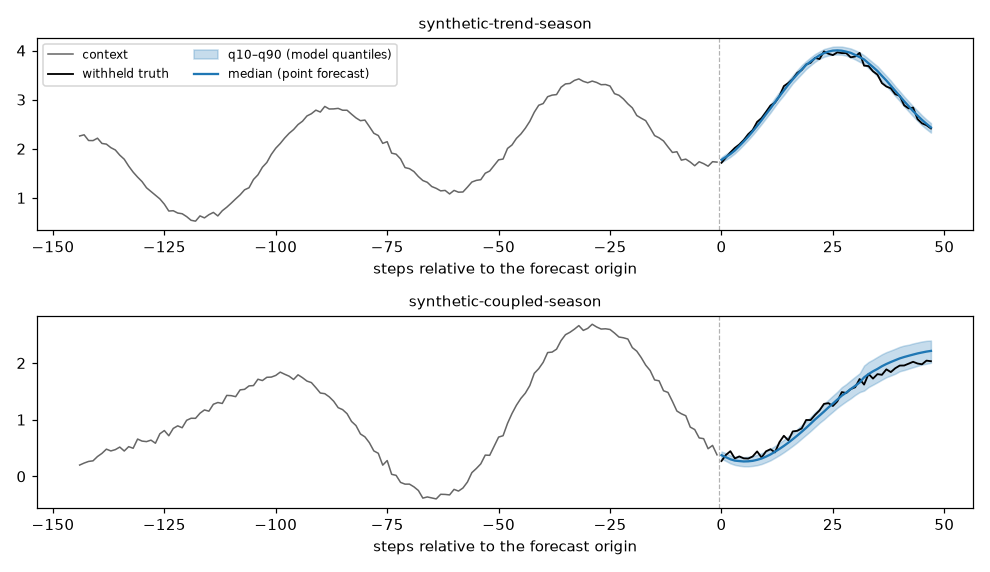

In [ ]:
run_stage('forecast')
from IPython.display import Image, display
display(Image(filename=str(OUTPUTS / 'toto_forecasting_forecast.png')))

**What to notice:** `point_forecast: 'median (q=0.5)'`, `context_padding: 16`, `device: 'cuda'`, `peak_cuda_gib` (about 9.45 on a T4 in the previous notebook), and in the figure the truth mostly inside the band.

## 7. Evaluate → evaluation report · [Evaluation practice]

`evaluation_report` carries the repository's own `mae` and `rmse` on the median, the `interval_coverage` of the q10–q90 band (nominal 0.8), and the last-value baseline, with the verdict `sample-sanity` — one holdout, no dispersion estimate, not a benchmark (without withheld truth the verdict is `not-measurable`). The stage adds the seasonal-naive and trend + season references, the noise floor (sample), **per-variate** MAE / RMSE, the coverage granularity (96 points: steps of 1/96 ≈ 0.010) and an **interpretation** line. The report is written to `outputs/toto_forecasting_evaluation_report.json`.

**Predict before running:** where will Toto's MAE fall on the scale from Section 5 — nearer last-value, seasonal naive, or the trend + season reference?

In [ ]:
run_stage('evaluate')

Running stage 'evaluate' in the isolated environment; log: /content/dimer_runs/toto_forecasting/dda52a7e8b26/logs/evaluate.log


{


  "task": "zero-shot probabilistic time-series forecasting",


  "point_forecast": "median (q=0.5)",


  "score_semantics": "quantile levels 0.1..0.9 are model quantiles, not calibrated confidence intervals",


...

    }


  ],


  "coverage_granularity": "q10\u2013q90 coverage over 96 holdout point(s) moves in steps of 1/96 = 0.0104",


  "interpretation": "Toto median MAE 0.0732 vs last-value 1.1080, seasonal-naive 0.6497 and least-squares trend + season 0.0363; noise floor 0.0349: the model is well ahead of the naive baselines, but a fit that knows the generator's two seasons sits near the floor, so the margin over last-value mostly shows how weak a flat forecast is on a trending seasonal series"


}


**What to notice:** the model's MAE (0.0732 recorded, RMSE 0.0887, coverage 0.823) beside the references, the per-variate rows, and the interpretation line.

**Checkpoint:** the model is 15 times better than last-value. What does that show, and what does it not?

<details>
<summary>Check your reasoning (open after answering)</summary>

It shows a sound zero-shot forecast: with no knowledge of the series' form the model lands between seasonal naive (0.650) and the informed trend + season fit (0.036), about twice the noise floor (0.035). It does not show that the model is 15 times better than a reasonable method: a flat forecast is a weak reference on a trending seasonal series, and a fit that knows the seasons does better here. On real series, where nobody knows the seasons, the seasonal and rolling-origin comparisons (the activity) are the informative ones.

</details>

## 8. Export outputs and provenance · [Engineering]

The CSV keeps variate, step, **timestamp** (your timestamps for BYOD; the step index for the sample), median, truth, the three references and all nine quantiles aligned row by row. `outputs/toto_forecasting_result.json` preserves the forecast summary, the evaluation report, the input manifest, the sample identity and digest with the last context timestamp and the spacing, the notebook's source, the model identifier, revision and licence, and the isolated environment's versions, device and peak CUDA memory. No credentials are recorded. The stage only reads earlier results, so re-running it alone is safe.

In [ ]:
run_stage('export')

Running stage 'export' in the isolated environment; log: /content/dimer_runs/toto_forecasting/dda52a7e8b26/logs/export.log


{'rows': 96, 'columns': ['variate', 'step', 'timestamp', 'median', 'truth', 'last_value_baseline', 'seasonal_naive', 'least_squares_trend_season', 'q10', 'q20', 'q30', 'q40', 'q50', 'q60', 'q70', 'q80', 'q90'], 'runtime': {'python': '3.12.12', 'torch': '2.7.0', 'toto-2': '2.0.0', 'numpy': '1.26.4', 'pandas': '2.2.3', 'device': 'cuda', 'peak_cuda_gib': 9.451}}


['toto_forecasting_evaluation_report.json', 'toto_forecasting_forecast.csv', 'toto_forecasting_forecast.png', 'toto_forecasting_input_manifest.json', 'toto_forecasting_result.json']


## 9. Optional activity: does the model stay ahead at another origin? · [Evaluation practice]

**Predict → Change → Run → Observe → Explain.** **Predict:** with `ACTIVITY_OFFSET = 48` the holdout moves 48 steps earlier (steps 224–271, with 224 steps of context). Will the model's lead over last-value and seasonal naive hold? **Change:** tick `RUN_ACTIVITY` and set `ACTIVITY_OFFSET`. **Run** this cell: it forecasts that earlier holdout. **Observe** the two rows — canonical and earlier origin — for the model and both naive references. **Explain** whether one holdout was enough to judge the model. The activity writes only to `outputs/activity/`.

In [ ]:
RUN_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_OFFSET = 48  # @param {type:"integer"}
if RUN_ACTIVITY:
    run_stage('activity', holdout_offset=ACTIVITY_OFFSET)
else:
    print('Optional activity skipped: tick RUN_ACTIVITY to run it. The canonical outputs are complete.')

Optional activity skipped: tick RUN_ACTIVITY to run it. The canonical outputs are complete.


**What to notice (if you ran it):** the `model_mae` column at the two origins and how much it moves.

<details>
<summary>Check your reasoning (open after running)</summary>

No hosted run of the activity is recorded yet, so compare your rows. If the model's error and its lead over the naive references change noticeably between two origins, one holdout was not enough to rank methods — which is why a rolling-origin evaluation over many windows is the standard for forecasting. If they hold, that is one more piece of evidence, still from the same synthetic generator.

</details>

## Troubleshooting · [Engineering]

| Symptom | Likely cause | What to do |
|---|---|---|
| `No CUDA GPU detected, and this notebook's model needs one` | a CPU-only runtime | *Runtime → Change runtime type → T4 GPU* (Colab) or turn on a GPU accelerator (Kaggle), then *Run all*. |
| `Not enough free disk` | a used runtime, or a small disk | Start a fresh runtime; about 9.2 GiB for the checkpoint and 8 GB for the environment are needed. |
| `CUDA out of memory` in Section 6 | a GPU smaller than a 15 GB T4, or another process on it | Use a T4 or larger; to free a GPU another process holds, choose *Runtime → Disconnect and delete runtime*, then *Run all* in the fresh runtime. |
| `This notebook needs a Linux x86_64 runtime` | macOS, Windows or ARM kernel | Use Colab, Kaggle or a Linux x86_64 Jupyter kernel. |
| `uv … wheel size/hash mismatch` or a `--require-hashes` error | a corrupted or substituted download | Re-run Section 2; never remove a pin or a hash. |
| a size or SHA-256 mismatch in Section 3 | an interrupted 9.8 GB download or a different file | Delete `weights/toto-2.0-2.5b/` and re-run Section 3; never edit the manifest. |
| `Stage '…' failed …: … is missing: run the stage that writes it` | a cell run out of order | Run the notebook in order from Section 4 (or *Run all*). |
| `HOLDOUT_OFFSET=… leaves no context` / `CONTEXT_LENGTH=… exceeds` | a holdout or context setting too large for the series | Lower the field, or supply a longer series. |
| `BYOD_CSV_PATH is empty, and the upload dialog exists only in Google Colab` | BYOD outside Colab with no path | Set `BYOD_CSV_PATH`. |
| `The upload was cancelled or empty` / `Upload exactly one file` | a cancelled or multi-file upload | Run the cell again and choose one CSV. |
| `<file>: no timestamp column in the header` | a missing or misnamed column, or another delimiter | Name the column `timestamp`; comma, semicolon and tab are read. |
| `<file>: target columns must be numeric; non-numeric values in {…}` | a text or identifier column | Remove the column or fix the values. |
| `<file>: empty values in {…}` | gaps in a target | Fill or drop those rows; this pipeline does not impute. |
| `<file>: timestamps must be regularly spaced` / `unique and strictly increasing` / `does not parse` | gaps, duplicates, unsorted rows or an unknown date format | Sort, de-duplicate, resample, or write ISO dates. |
| `<file>: N rows; this tutorial needs at least …` | too short for context + holdout | Supply more rows or lower `HORIZON`. |
| `trimmed: {…}` (a note, not an error) | more than `MAX_CONTEXT + HORIZON` rows | The most recent rows are kept; older rows cannot be context. |

## Interpretation and limits

The forecast is zero-shot; no gradient training or fine-tuning occurs. q=0.5 is a model median, and the other quantiles are model quantiles rather than guaranteed confidence intervals — the reported q10–q90 coverage on one holdout of 96 points moves in steps of about 0.010 and is not a calibration statement. On the default synthetic series the model is far ahead of last-value and seasonal naive, but an informed least-squares fit of the generator's seasons is closer to the noise floor, so the comparison shows a sound workflow rather than a margin over reasonable methods. MAE/RMSE from one chronological holdout must be repeated over representative periods of a real deployment series (rolling origins), against seasonal references, before any conclusion. Regime changes, missing values (rejected by the contract), irregular sampling and horizons far beyond the context all degrade results in ways the pipeline does not detect. The pipeline provides no fine-tuning, covariate conditioning, anomaly detection or imputation capability.

Successful execution proves that the recorded repository revision's package, carried in this notebook, can acquire and digest-verify the pinned checkpoint, validate the demonstrated input, execute the public pipeline path, and emit the shown machine-readable outputs in the tested runtime — without the repository being reachable. It does **not** establish benchmark superiority, deployment calibration, safety for high-consequence decisions, or production fitness on an unseen domain.

## Conclusion · [Evaluation practice]

Write three sentences: what the chronological holdout guarantees; where the model's error falls between the naive references, the informed trend + season fit and the noise floor; and what you would need before trusting the model on a real series.

<details>
<summary>Sample conclusion (open after writing yours)</summary>

The holdout withheld the last 48 steps of both variates before the model or any reference saw them, so nothing leaked. The model's median MAE (0.073 recorded) is far below last-value (1.108) and seasonal naive (0.650) but about twice the noise floor (0.035), and a fit that knows the generator's seasons (0.036) does better, so on this easy series the model shows a good zero-shot forecast rather than a margin over informed methods. Before trusting it on a real series I would compare it with seasonal references over many rolling origins from representative periods, per variate, and check its band coverage over many points.

</details>

**Next experiments:** run the activity at offsets 48, 96 and 144; set `CONTEXT_LENGTH` to 64 and watch the error and the band; enable `USE_BYOD` with a CSV from your own domain, set `SEASON_PERIOD` to its cycle, and compare the model with seasonal naive at several origins.

## References

- Repository README: https://github.com/kurtvalcorza/toto-forecasting-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/toto-forecasting-pipeline/blob/main/MODEL_CARD.md
- Weight provenance: https://github.com/kurtvalcorza/toto-forecasting-pipeline/blob/main/docs/WEIGHTS.md
- Upstream model: https://huggingface.co/Datadog/Toto-2.0-2.5B
- Upstream code: https://github.com/DataDog/toto
- Paper: https://arxiv.org/abs/2605.20119